# 1. Introdução

Este notebook tem como objetivo apresentar de *forma didática* a análise exploratória, modelagem de dados e eventuais resultados para um sistema de predição de alagamentos de curto prazo (flash flooding) na região metropolitana de Santo André.

O documento conta com as seguintes seções:

1. Introdução
2. [Preparação dos dados](#prep)
1. [Funções de uso geral](#funcs)
3. [Exploração inicial dos dados](#expl)

**Primeiro relatório começa aqui**
5. [Primeira tentativa](#sec4)
5. [Filtro por condição climática](#sec5)
6. [Filtro por bacia hidrográfica](#sec6)

**Segundo relatório começa aqui**
8. [Análise da influência da sazonalidade](#sec7)
8. [Filtro por sazonalidade](#sec8)
9. [Undersampling por clusters](#sec9)
10. [Análise da influência da precipitação](#sec10)
11. [Filtro por precipitação](#sec11)

**Terceiro relatório começa aqui**
13. [Análise das distribuições](#sec12)
13. [Filtro por novos cortes](#sec13)
14. [Modelagem por variação no período](#sec14)

**Quarto relatório começa aqui**

-- Desenvolvimento dashboard

**Quinto relatório começa aqui**
15. [Modelagem das bacias](#sec15)

**Sexto relatório começa aqui**
16. [Resultados para condições extremas](#sec16)
17. [Modelo apenas com dados históricos vs forecast](#sec17)
18. [Explicando o modelo](#sec18)

**Sétimo relatório começa aqui**
19. [Validando modelo histórico com forecast](#sec19)
20. [Análise por turnos](#sec20)

<a name="prep"></a>
# 2. Preparação dos dados

Essa seção é apenas para a preparação inicial para rodar o notebook. **Rode sempre que reconectar a sessão**. Essa seção se subdivide em:

* [Importações de bibliotecas necessárias para o notebook](#import)
* [Download dos datasets utilizados](#load)
* [Pré processamento básico dos dados](#preprocess)

<a name="import"></a>
**2.1. Importações/Instalações**

In [ ]:
!pip install pycaret

In [ ]:
# File management
import zipfile
import gdown
import os

# Data manipulation
import pandas as pd

# Data splitting
from sklearn.model_selection import train_test_split

# Sampling techniques
from imblearn.under_sampling import ClusterCentroids

# PyCaret for automated ML setup and model comparison
from pycaret.classification import setup, compare_models, predict_model

# Plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

<a name="load"></a>
**2.2. Carregando os dados**

In [ ]:
parent_dir = '/content'

2.2.1. Open Weather


In [ ]:
file_openw = 'openweather_history.csv'

output = os.path.join( parent_dir, file_openw)
if not(os.path.isfile(output)):
    url_openw = 'https://drive.google.com/uc?id=1dZ_2C-ZfpL4nNDf1w1jKw_PhF6FwG5lb'
    gdown.download(url_openw, output=output, quiet=False)

df_openw_raw = pd.read_csv(file_openw)

Downloading...
From (original): https://drive.google.com/uc?id=1dZ_2C-ZfpL4nNDf1w1jKw_PhF6FwG5lb
From (redirected): https://drive.google.com/uc?id=1dZ_2C-ZfpL4nNDf1w1jKw_PhF6FwG5lb&confirm=t&uuid=e1c021c7-ee21-45c4-9737-dbaca86c5a3d
To: /content/openweather_history.csv
100%|██████████| 69.1M/69.1M [00:00<00:00, 187MB/s]


In [ ]:
df_openw_raw.describe()

,dt,timezone,lat,lon,temp,visibility,dew_point,feels_like,temp_min,temp_max,...,humidity,wind_speed,wind_deg,wind_gust,rain_1h,rain_3h,snow_1h,snow_3h,clouds_all,weather_id
count,4.055220e+05,405522.000000,4.055220e+05,4.055220e+05,405522.000000,249183.000000,405522.000000,405522.000000,405522.000000,405522.000000,...,405522.000000,405522.000000,405522.000000,12874.000000,105064.000000,374.000000,0.0,0.0,405522.000000,405522.000000
mean,1.003012e+09,-9888.605797,-2.367889e+01,-4.653671e+01,19.694342,8420.630946,15.477676,19.799649,18.880655,20.397976,...,78.927836,2.851135,167.406156,1.553368,0.918277,1.339091,NaN,NaN,60.465578,705.974255
std,4.108633e+08,1565.370812,5.730890e-11,2.498271e-10,4.494108,2365.356949,3.636240,4.755809,4.476055,4.553565,...,16.352391,1.757324,106.454608,4.197171,1.534356,1.623255,NaN,NaN,38.986869,140.828739
min,2.839968e+08,-10800.000000,-2.367889e+01,-4.653671e+01,0.510000,50.000000,-9.130000,-2.680000,-0.160000,1.810000,...,8.000000,0.000000,0.000000,0.000000,0.100000,0.130000,NaN,NaN,0.000000,200.000000
25%,6.482457e+08,-10800.000000,-2.367889e+01,-4.653671e+01,16.570000,7000.000000,13.080000,16.530000,15.790000,17.150000,...,71.000000,1.540000,100.000000,0.000000,0.200000,0.630000,NaN,NaN,20.000000,501.000000
50%,1.008103e+09,-10800.000000,-2.367889e+01,-4.653671e+01,19.640000,9999.000000,15.890000,19.830000,18.810000,20.240000,...,83.000000,2.600000,150.000000,0.000000,0.390000,1.000000,NaN,NaN,75.000000,800.000000
75%,1.356720e+09,-7200.000000,-2.367889e+01,-4.653671e+01,22.520000,10000.000000,18.210000,22.780000,21.690000,23.230000,...,91.000000,4.100000,231.000000,0.000000,0.950000,1.500000,NaN,NaN,100.000000,803.000000
max,1.710976e+09,-7200.000000,-2.367889e+01,-4.653671e+01,36.800000,10000.000000,30.940000,41.510000,36.140000,38.150000,...,100.000000,30.800000,360.000000,24.690000,32.590000,16.380000,NaN,NaN,100.000000,804.000000


2.2.2 Open Weather Forecasts

In [ ]:
file_openw_forecast = 'openweather_bulk_history.csv'

output = os.path.join( parent_dir, file_openw_forecast)
if not(os.path.isfile(output)):
    url_hist = 'https://drive.google.com/uc?id=1U_Hb_DK0u7RuAgtDEp_T5IX8-uMUbZc8'
    gdown.download(url_hist, output=output, quiet=False)

output = os.path.join( parent_dir, file_openw_forecast)

df_openwf_raw = pd.read_csv(file_openw_forecast)

Downloading...
From (original): https://drive.google.com/uc?id=1U_Hb_DK0u7RuAgtDEp_T5IX8-uMUbZc8
From (redirected): https://drive.google.com/uc?id=1U_Hb_DK0u7RuAgtDEp_T5IX8-uMUbZc8&confirm=t&uuid=863e0df9-5ce7-4d6e-a102-b8b600887b2c
To: /content/openweather_bulk_history.csv
100%|██████████| 639M/639M [00:07<00:00, 83.4MB/s]


2.2.3 Dataset de chamados

In [ ]:
file_chamados = 'relrvosolicit.csv'

output = os.path.join( parent_dir, file_chamados)
if not(os.path.isfile(output)):
    url_chamados = 'https://drive.google.com/uc?id=1Fa5TOO-hXAT4l7-IyA51Kswjdxn7WoQD'
    gdown.download(url_chamados, output=output, quiet=False)

df_chamados_raw = pd.read_csv(file_chamados)

Downloading...
From: https://drive.google.com/uc?id=1Fa5TOO-hXAT4l7-IyA51Kswjdxn7WoQD
To: /content/relrvosolicit.csv
100%|██████████| 9.08M/9.08M [00:00<00:00, 39.0MB/s]


In [ ]:
df_chamados_raw.columns

Index(['SERVIÇO', 'ENDEREÇO', 'DATA', 'ENCAMINHAMENTO', 'SOLICITANTE'], dtype='object')

In [ ]:
df_chamados_raw["dt"] = pd.to_datetime(df_chamados_raw.DATA)

/tmp/ipython-input-9-1179310477.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_chamados_raw["dt"] = pd.to_datetime(df_chamados_raw.DATA)


In [ ]:
df_chamados_raw.sort_values(by="dt", ascending=False)

,SERVIÇO,ENDEREÇO,DATA,ENCAMINHAMENTO,SOLICITANTE,dt
67689,827 - DPDCSA - Vistoria de Árvore - Área Externa,"RUA OSLO, 161 - VL METALURGICA",15/09/2023,DMAV,ERASMO QERO FERNADES,2023-09-15
67688,801.2 - DDC - Vistoria Edificação - Casa,"RUA CONDE SARZEDAS, DE, 345 - VL GUARANI",15/09/2023,DCURB,TAMIRES PEREIRA LIMA DE OLIVEIRA,2023-09-15
67699,801.2 - DDC - Vistoria Edificação - Casa,"EST LESTE, DO - BAIRRO INEXISTENTE",15/09/2023,DGPPA,MARCIO ANTONIO CAMPOS,2023-09-15
67697,826 - DPDCSA - Vistoria de Árvore - Área Interna,"EST CATA PRETA, 826 - VL JOAO RAMALHO",15/09/2023,DMAV,CRECHE PROF. HIDEKI KOYAMA,2023-09-15
67696,826 - DPDCSA - Vistoria de Árvore - Área Interna,"EST CATA PRETA, 810 - VL JOAO RAMALHO",15/09/2023,DMAV,CRECHE CATA PRETA,2023-09-15
...,...,...,...,...,...,...
29350,802.1 - DDC - Vistoria de Árvores - Ruptura de...,"AVN DOM PEDRO I, 276 - VL TIBIRICA",24/01/2001,DPAV,PAULO SERGIO VASCONCELOS,2001-01-24
29351,802.1 - DDC - Vistoria de Árvores - Ruptura de...,"AVN DOM PEDRO I, 276 - VL PIRES",24/01/2001,DPAV,PAULO SERGIO VASCONCELOS,2001-01-24
29349,802.1 - DDC - Vistoria de Árvores - Ruptura de...,"AVN DOM PEDRO I, 276 - VL PIRES",24/01/2001,DPAV,PAULO SERGIO VASCONCELOS,2001-01-24
29069,802.5 - DDC - Vistoria em Árvores - Vistoria,"RUA NATAL, 428 - SILVEIRA",21/01/2001,DPAV,LUIZ NASCIMENTO DE OLIVEIRA,2001-01-21


<a name="preprocess"></a>
**2.3. Processamento de dados**

Pode parecer um pouco estranho uma seção de pré processamento aparecer antes da análise exploratória dos dados e **realmente é estranho**. Esta seção realmente é um tanto anacrônica e isso é *proposital*. A intenção é que a seção que abriga o pré processamento necessário para trabalhar com os datasets esteja o mais próxima possível do começo do notebook, pois ela precisará ser executada toda vez que o *runtime* do colab reconectar. A minha solução foi criar uma seção que foi editada fora de ordem; esta seção foi feita **depois** da seção de análise exploratória.

O que considerei como processamento inevitável?

1. Transformar as colunas de data em datetime
2. Remover colunas que não são interessantes nem para uma etapa de análise exploratória
3. Arrumar os nomes das colunas que utilizam caracteres incomuns ou inconvenientes

2.3.1. Arrumando colunas de datetime

In [ ]:
df_chamados_dt = df_chamados_raw.copy()
df_chamados_dt['dt'] = pd.to_datetime(df_chamados_dt['DATA'], dayfirst=True)

df_openw_dt = df_openw_raw.copy()
df_openw_dt['dt'] = pd.to_datetime(df_openw_dt['dt'], unit="s")

df_openwf_dt = df_openwf_raw.copy()
df_openwf_dt['forecast dt unixtime'] = pd.to_datetime(df_openwf_dt['forecast dt unixtime'], unit="s")
df_openwf_dt['slice dt unixtime'] = pd.to_datetime(df_openwf_dt['slice dt unixtime'], unit="s")

2.3.2. Removendo colunas inúteis

Para Open Weather:

* As colunas *dt_iso*, *timezone*, *city_name*, *lat*, *lon* não servem para as nossas análises.
* As colunas *rain_3h*, *snow_1h*, *snow_3h*, *grnd_level* e *sea_level* até serviriam para algo, mas estão quase sem dados.

Para Open Weather Forecast:

* As colunas *forecast dt iso*, *slice dt iso*, *lat*, *lon* e *hours* não servem para as nossas análises.
* As colunas *snow*, *ice*, *fr_rain*, *snow_depth*, *accumulated*, *rate* estão quase completamente sem dados. Praticamente só tem *not a number*.

Para Chamados:

* As colunas ENCAMINHAMENTO e SOLICITANTE não são úteis para a modelagem
* A coluna SERVIÇO é necessária para filtrar por chamados de enchente, mas já podemos fazer esse filtro agora e liberar a coluna



In [ ]:
openw_removal = ["dt_iso", "timezone", "lat", "lon", "rain_3h", "snow_1h",
                 "snow_3h", "grnd_level", "sea_level", "city_name"]
df_openw_rem = df_openw_dt.drop(columns=openw_removal)

openwf_removal = ["forecast dt iso", "slice dt iso", "lat", "lon", "hours",
                  "snow", "ice", "fr_rain", "snow_depth", "accumulated", "rate"]
df_openwf_rem = df_openwf_dt.drop(columns=openwf_removal)

# Filtrando por tipo de serviço
enchente = ["809.3 - DDC - Enchente / Inundação / Alagamento - Núcleo",
            "809 - DDC - Enchente / Inundação / Alagamento",
            "809.2 - DDC - Enchente / Inundação / Alagamento - Residência",
            "809.1 - DDC - Enchente / Inundação / Alagamento - Via",
            "809.4 - DDC - Enchente / Inundação / Alagamento - Industria / Comércio"]

df_chamados_temp1 = df_chamados_dt.loc[df_chamados_dt['SERVIÇO'].isin(enchente)].reset_index()
chamados_removal = ["DATA", "ENCAMINHAMENTO", "SOLICITANTE", "SERVIÇO", "index"]
df_chamados_rem = df_chamados_temp1.drop(columns=chamados_removal)

In [ ]:
df_chamados_rem.shape

(3757, 2)

2.3.3. Arrumando nomes de colunas

Openweather:

* Nada a arrumar. Está tudo decente.

Openweather forecast:

* Há algumas colunas com espaço no nome, o que é um tanto inconveniente.
* Vou transformar o nome do *forecast dt* em apenas *dt*, assim fica um padrão entre os datasets.
* O nome *slice dt* não é muito elucidativo. Vou trocar por *predict_dt* para ficar claro que trata-se do datetime da predição.

Chamados:

* Para manter um padrão entre os datasets, vou transformar os nomes das colunas de maiúsculo para minúsculo e remover caracteres incomuns (ç)



In [ ]:
df_openw = df_openw_rem

df_openwf = df_openwf_rem.rename(
    columns={"forecast dt unixtime": "dt",
             "slice dt unixtime": "predict_dt"}
)

df_chamados = df_chamados_rem.rename(
    columns={"DATA": "dt", "ENDEREÇO": "end"}
)

In [ ]:
cols = list(df_openwf.columns)
cols.remove('dt')
cols.remove('predict_dt')
for col in cols:
    df_openwf.rename(columns={col: col + '_fore'}, inplace=True)

<a name="func"></a>
# 3. Funções de uso geral

[fill_missing](#fill_missing)

[shift_column_up](#shift_column_up)

[agg_dict](#agg_dict)

[evaluate_by_counts](#evaluate_by_counts)




<a name="fill_missing"></a>

In [ ]:
def fill_missing(df, columns):
  """
  Fill missing values in specified columns of a DataFrame.

  Uses forward fill and, if there are still null values, uses backward fill.

  Parameters:
  ----------
  df : pd.DataFrame
      The DataFrame in which to fill missing values.
  columns : list of str
      List of column names where missing values should be filled.

  Returns:
  -------
  pd.DataFrame
      A copy of the original DataFrame with missing values filled.
  """

  df_filled = df.copy()
  for column in columns:
    if df_filled[column].isnull().any():
      df_filled[column] = df_filled[column].ffill()
      if df_filled[column].isnull().any():
        df_filled[column] = df_filled[column].bfill()
  return df_filled

<a name="shift_column_up"></a>

In [ ]:
def shift_column_up(df, columns, amount):
    """
    Shift the values in a specified column of a DataFrame up by a given amount.

    Parameters:
    ----------
    df : pd.DataFrame
        The DataFrame containing the column to be shifted.
    columns : list of str
      List of column names to be shifted up
    amount : int
        The number of rows to shift the column up.

    Returns:
    -------
    pd.DataFrame or None
        A new DataFrame with the specified column shifted up by the given amount.
        If the column does not exist or an error occurs, returns None.
    """
    df_shifted = df.copy()
    try:
      for column_name in columns:
        # Shift the specified column up by the specified amount
        df_shifted[column_name] = df_shifted[column_name].shift(-amount)
      # Delete the last rows, which will contain NaN values after shifting
      df_shifted.drop(df_shifted.tail(amount).index, inplace=True)
      return df_shifted
    except KeyError:
      print(f"Error: Column '{column_name}' not found in the DataFrame.")
      return None
    except Exception as e:
      print(f"An unexpected error occurred: {e}")
      return None

<a name="agg_dict"></a>

In [ ]:
def generate_slices(time_interval, start, end):
    """
    Generate time-based slices within a specified interval.

    Parameters:
    ----------
    time_interval : int
        The interval size to divide the range.
    start : int
        The starting point of the range.
    end : int
        The endpoint of the range.

    Returns:
    -------
    dict
        A dictionary where keys are interval names (e.g., "0_24") and values are
        slice objects for each interval.
    """
    slices = {}
    for i in range(start, end, time_interval):
        slices[f"{i}_{i+time_interval}"] = slice(i, i+time_interval)
    return slices

def generate_default_config_dict(df):
    """
    Generate a default configuration dictionary for aggregation of each column
    in a dataframe.

    Parameters:
    ----------
    df : pd.DataFrame
        The DataFrame for which the configuration dictionary is generated.

    Returns:
    -------
    dict
        A dictionary with column names as keys and default configuration tuples
        as values (interval size and aggregation functions).
    """
    config_dict = {}
    for col in df.columns:
        config_dict[col] = (24, ("mean",))
    return config_dict

def create_agg_dict(config_dict, start=0, end=24):
    """
    Create an aggregation dictionary based on a configuration dictionary.

    This dictionary can then be used as input to the df.agg method.

    Usage example:

    df_agg = df.groupby(pd.Grouper(key='dt', freq='D')).agg(
                                                  **create_agg_dict(agg_config)
                                                  ).reset_index()

    Parameters:
    ----------
    config_dict : dict
        A dictionary where keys are column names and values are tuples
        containing the interval size and list of aggregation functions.
    start : int, optional
        The starting point of the time range (default is 0).
    end : int, optional
        The endpoint of the time range (default is 24).

    Returns:
    -------
    dict
        An aggregation dictionary where keys are descriptive names for each aggregation,
        and values are tuples of (column name, aggregation lambda).
    """
    agg_dict = {}
    for col, config in config_dict.items():
        time_interval, agg_list = config
        for interval_name, interval_slice in generate_slices(time_interval, start, end).items():
            if "mean" in agg_list:
                agg_dict[f"{col}_{interval_name}_mean"] = (col, lambda x, s=interval_slice: x[s].mean())
            if "median" in agg_list:
                agg_dict[f"{col}_{interval_name}_median"] = (col, lambda x, s=interval_slice: x[s].median())
            if "sum" in agg_list:
                agg_dict[f"{col}_{interval_name}_sum"] = (col, lambda x, s=interval_slice: x[s].sum())
            if "max" in agg_list:
                agg_dict[f"{col}_{interval_name}_max"] = (col, lambda x, s=interval_slice: x[s].max())
            if "min" in agg_list:
                agg_dict[f"{col}_{interval_name}_min"] = (col, lambda x, s=interval_slice: x[s].min())
            if "delta" in agg_list:
                agg_dict[f"{col}_{interval_name}_delta"] = (col, lambda x, s=interval_slice: x[s].max() - x[s].min())
            if "mode" in agg_list:
                agg_dict[f"{col}_{interval_name}_mode"] = (col, lambda x, s=interval_slice: x[s].mode())
            if "random_sample" in agg_list:
                agg_dict[f"{col}_{interval_name}_random_sample"] = (col, lambda x, s=interval_slice: x[s].sample(1))
    return agg_dict

In [ ]:
def create_box_plot(df):
    """
    Create an interactive box plot for visualizing each column in a DataFrame,
    with a dropdown menu to switch between columns.

    This function generates a box plot using Plotly, displaying data distribution
    for each column in the DataFrame (except for a column named 'chamado').
    A dropdown menu allows users to select which column to view, updating the
    plot dynamically.

    Parameters:
    ----------
    df : pd.DataFrame
        The DataFrame containing the data to be plotted. Must contain a column
        named 'chamado' for the x-axis in the box plot.

    Returns:
    -------
    None
        Displays the interactive Plotly box plot in the output.

    Notes:
    ------
    Outliers are included in the plot as points by default. If the DataFrame contains
    many columns, each one will be accessible through the dropdown menu, allowing
    quick comparisons of data distribution.
    """
    # Filter outliers from all columns
    filtered_df = df.copy()

    # Define buttons for the dropdown menu
    buttons = []
    for col in filtered_df.columns:  # Use filtered_df for dropdown options
        if col != 'chamado':
            buttons.append(dict(
                label=col,
                method='update',
                args=[{'y': [filtered_df[col]]},  # Update y data directly
                      {'yaxis.title.text': col}]  # Update y-axis label
            ))

    buttons.sort(key=lambda x: x['label'])

    # Create a box plot using Plotly
    fig = px.box(filtered_df, x="chamado", y=buttons[0]["label"], points="all")

    # Update layout with dropdown menu
    fig.update_layout(
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0.1,
                xanchor="left",
                y=1.15,
                yanchor="top"
            ),
        ]
    )

    fig.show()

In [ ]:
def check_cut(df, col, threshold):
    """
    Filter a DataFrame based on a threshold value in a specified column and
    provide summary statistics before and after filtering.

    Parameters:
    ----------
    df : pd.DataFrame
        The DataFrame to be filtered.
    col : str
        The name of the column to apply the threshold filter.
    threshold : numeric
        The cutoff value for filtering. Rows where `df[col]` is greater than or equal
        to this value will be retained.

    Returns:
    -------
    pd.DataFrame
        A copy of the filtered DataFrame.
    """
    print(f"Filtrando {col} com corte em {threshold}")
    df_filtered = df[df[col] >= threshold].copy()
    print(f"Antes do corte vs Depois do corte (tamanho total): {df.shape[0]} vs {df_filtered.shape[0]}")
    print(f"Antes do corte vs Depois do corte (chamados): \n{df.chamado.value_counts()} vs \n{df_filtered.chamado.value_counts()}")
    return df_filtered.copy()


In [ ]:
def compare_lower_fence_cuts(df, target_column='chamado', min=False, exclude_col="counts"):
    """
    Compare lower fence cuts for columns in a DataFrame to analyze how many
    true and false target values are excluded by the cut.

    This function calculates a "lower fence" threshold for each column in the DataFrame
    (excluding the specified target column) and filters out rows where column values are
    below or equal to this threshold. The function then counts and records the number of
    true and false target values excluded by the cut for each column. If `min` is set to
    True, the lower fence is set to the minimum value of each column; otherwise, it
    is calculated as `Q1 - 1.5 * IQR`.

    Parameters:
    ----------
    df : pd.DataFrame
        The DataFrame containing the data to analyze.
    target_column : str, optional
        The name of the target column with boolean values, indicating true and false
        targets to count (default is 'chamado').
    min : bool, optional
        If True, sets the lower fence threshold to the minimum value in each column.
        If False, calculates the lower fence as `Q1 - 1.5 * IQR` (default is False).

    Returns:
    -------
    pd.DataFrame
        A DataFrame containing each feature, the threshold value, and the count of
        true and false target values cut by the lower fence.
    """
    results = []
    for col in df.columns:
        if col != target_column and col != exclude_col:
            if not min:
                # Calculate the lower fence
                q1 = df[col].quantile(0.25)
                q3 = df[col].quantile(0.75)
                iqr = q3 - q1
                lower_fence = q1 - 1.5 * iqr
            else:
                lower_fence = df[col].min()

            # Filter the DataFrame
            df_filtered = df[df[col] <= lower_fence]

            # Count the number of false and true target values cut
            false_count_cut = df_filtered[df_filtered[target_column] == False].shape[0]
            true_count_cut = df_filtered[df_filtered[target_column] == True].shape[0]

            # Always append the results, even if false_count_cut is 0
            results.append({'feature': col,
                            "threshold": lower_fence,
                            'false_cut_count': false_count_cut,
                            "true_cut_count": true_count_cut})

    results_df = pd.DataFrame(results)

    # Sort by 'false_cut_count' if it exists
    if 'false_cut_count' in results_df.columns:
        return results_df.sort_values('false_cut_count', ascending=False)
    else:
        # Return as is if 'false_cut_count' is missing
        return results_df


In [ ]:
def iterative_lower_fence_cuts(df, target_column='chamado', true_cut_max=0, min=False):
    """
    Iteratively apply lower fence cuts on DataFrame columns based on specified conditions
    until no further cuts meet the criteria.

    This function performs an iterative filtering process on the DataFrame, where it
    removes rows based on a calculated or minimum lower fence threshold for each column.
    The best cut is determined by finding the feature with a threshold that minimizes
    the removal of true target values (up to the specified `true_cut_max`). The process
    continues until no suitable cuts are found or the DataFrame shape no longer changes.

    Parameters:
    ----------
    df : pd.DataFrame
        The DataFrame to be filtered.
    target_column : str, optional
        The column with boolean values indicating true and false targets for counting
        (default is 'chamado').
    true_cut_max : int, optional
        The maximum allowable count of true target values that can be removed by any single
        cut. The algorithm will skip cuts that remove more true cases than this threshold
        (default is 0).
    min : bool, optional
        If True, sets the lower fence to the minimum value of each column. Otherwise,
        it calculates the lower fence as `Q1 - 1.5 * IQR` (default is False).

    Returns:
    -------
    pd.DataFrame
        A copy of the DataFrame with rows iteratively removed based on the lower fence cuts.
    """
    df_copy = df.copy()
    previous_shape = df_copy.shape[0]  # Store initial shape of DataFrame

    while True:
        cuts_df = compare_lower_fence_cuts(df_copy, target_column, min)

        best_cut = None
        for index, row in cuts_df.iterrows():
            if row['true_cut_count'] <= true_cut_max:
                best_cut = row
                break

        if best_cut is None:
            break

        print(f"Applying cut on feature '{best_cut['feature']}' with threshold {best_cut['threshold']}, removing {best_cut['false_cut_count']} false cases and {best_cut['true_cut_count']} true cases")
        df_copy = df_copy[df_copy[best_cut['feature']] > best_cut['threshold']]

        # Check if the DataFrame shape has changed
        if df_copy.shape[0] == previous_shape:
            print("No more cuts applied. Exiting loop.")
            break  # Exit loop if no rows were removed

        previous_shape = df_copy.shape[0]  # Update previous_shape

    print(f"Final results: {df_copy[target_column].value_counts()}")
    return df_copy

In [ ]:
def train_and_evaluate_model(df, target, test_size, sampling_strategy=0, n_counts=0, sort="Accuracy",
                             **kwargs):
    """
    Train and evaluate models on a dataset with optional undersampling and PyCaret's automated ML setup.

    This function splits the dataset into training and testing sets, applies optional undersampling
    to the training set using Cluster Centroids, and uses PyCaret to set up and evaluate multiple
    models. The best models are selected and used to predict the target variable on the test set.

    Parameters:
    ----------
    df : pd.DataFrame
        The DataFrame containing the features and target for model training.
    target : str
        The name of the target column.
    test_size : float
        The proportion of data to be used as the test set (e.g., 0.2 for 20%).
    sampling_strategy : float or int, optional
        The undersampling ratio for the minority class using Cluster Centroids.
        If 0 (default), no undersampling is applied.

    Returns:
    -------
    None
        The function displays model comparison results and predictions for each model.
    """

    # Undersample the training data using Cluster Centroids
    if sampling_strategy:
        X_train = train_data.drop(columns=target)
        y_train = train_data[target[0]]
        cc = ClusterCentroids(random_state=42, sampling_strategy=sampling_strategy)
        X_resampled, y_resampled = cc.fit_resample(X_train, y_train)
        train_data_resampled = pd.concat([X_resampled, y_resampled], axis=1)
    else:
        train_data_resampled = train_data.copy()

    # Setup PyCaret environment
    s = setup(data=train_data_resampled, target=target[0], session_id=123, fix_imbalance=False, **kwargs)

    # Compare models and select the best ones
    best_models = compare_models(n_select=5, sort=sort)

    # Predict on the test data for each selected model
    for model in best_models:
        predicted = predict_model(model, data=test_data)

    return best_models, train_data, test_data

In [ ]:
def evaluate_by_counts(models, data, pattern="^rain.*sum$", percentile=0.95):
  data["count_sum"] = data.filter(regex=pattern).sum(axis=1)
  cut_value = data["count_sum"].quantile(percentile)
  filtered_data = data[data["count_sum"] > cut_value]
  filtered_data.drop(columns=["count_sum"], inplace=True)
  print(f"Shape resultante: {filtered_data.shape}")
  predicted = predict_model(models, data=filtered_data)

In [ ]:
import unicodedata

def strip_accents(s):
    """
    Remove accent marks and diacritics from a string using Unicode normalization.

    This function decomposes the input string using NFD Unicode normalization and
    removes all combining character markers (accent/diacritic marks) to return
    a simplified ASCII-friendly version of the text.

    Parameters:
    ----------
    s : str
        The input string containing potential accented characters or diacritics.

    Returns:
    -------
    str
        The processed string with accent marks removed while preserving original characters.
    """
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                  if unicodedata.category(c) != 'Mn')


def rename_neighborhood_list(name_list):
    """
    Standardize neighborhood names by converting to uppercase, replacing common terms,
    and removing accents.

    This function processes a list of neighborhood names by:
    1. Converting all characters to uppercase
    2. Replacing common prefixes with abbreviations (VILA → VL, JARDIM → JD, etc.)
    3. Stripping accent marks using the strip_accents utility
    4. Modifies AND returns the input list object (operates in-place)

    Parameters:
    ----------
    name_list : list[str]
        A list of neighborhood name strings to be standardized in-place.

    Returns:
    -------
    list[str]
        The modified input list containing standardized neighborhood names. Common
        replacements include:
        - "VILA" becomes "VL"
        - "JARDIM" becomes "JD"
        - "PARQUE" becomes "PQ"

    Note:
    -----
    This function modifies the original list object while returning it. Consider making
    a copy if the original list needs to be preserved.
    """
    for i, name in enumerate(name_list):
        name_list[i] = strip_accents(name.upper().replace("VILA", "VL").replace("JARDIM", "JD").replace("PARQUE", "PQ"))
    return name_list


<a name="expl"></a>
# 4. Exploração inicial dos dados

O objetivo desta seção é a primeira análise dos dados de cada um dos dataframes utilizados. A saber:

* [Open Weather](#oweather) - o dataset da open weather utilizado aqui agrega os valores históricos das condições climáticas em um determinado dia e horário.
* [Open Weather Forecast](#oforecast) - diferente do primeiro dataset, o que o dataset de *forecasts* oferece é uma visão do que **foi previsto** de condições climáticas em um determinado dia e horário, olhando até **quinze dias à frente**.
* [Dataset de chamados](#chamados) - este dataset é um tanto mais simples que os dois primeiros, consistindo apenas de chamados abertos junto à prefeitura de Santo André. Entre esses chamados, estão as ocorrências de alagamentos.

Os resultados da análise podem ser vistos de forma resumida abaixo:

A tabela abaixo resume todos os features encontrados no dataset, seu tipo e uma explicação sucinta do que ele significa. Uma das principais fontes de informação para esta etapa foi a [documentação da API da Open Weather](https://openweathermap.org/current):

<a name="oweather"></a>
**Open Weather**

In [ ]:
df_openw_raw.info()

NameError: name 'df_openw_raw' is not defined

**Explicação dos features (fonte=doc da API)**

Vou focar nas seguintes features, pois o resto é autoexplicativo:

| Feature    | Explicação |
|------------|------------|
| dt/dt_iso  |Datetime no padrão Unix/padrão ISO. Utiliza UTC.|
| timezone   |Deslocamento em segundos a partir de UTC.|
| visibility |Visibilidade. O valor máximo é 10km. Climas nublados diminuem esse valor.|
| dew_point  |Ponto de orvalho. É a temperatura que o ar precisa chegar para saturar a umidade em 100%.|
| wind_gust  |Não encontrei a diferença entre velocidade do vento e rajada de vento. Preciso investigar.|
| weather_id |Id do clima.|
| grnd_level |Pressão atmosférica no nível do solo em hPa.|
| pressure   |Pressão atmosférica no nível do mar em hPa (nem ideia qual a diferença para o sea_level|
| clouds_all|Valor percentual que indica o quão nublado o clima está.|

Logo de cara já faz sentido limpar um pouco o dataset, tirando algumas informações que certamente não serão úteis. Escolhi o seguinte:
1. snow_1h/snow_3h - não vou nem verificar se já nevou em santo andré. Irrelevante.
2. city_name - não vai mudar.
3. weather_icon - não vai ajudar em nada.

**De quanto em quanto tempo são os dados**

Primeiro, vamos converter dt para um formato datetime usável.

In [ ]:
df_openw_rem1['dt_fixed'] = pd.to_datetime(df_openw_rem1['dt'], unit='s')
df_openw_rem1.tail(2)[["dt", "dt_iso", "dt_fixed"]]

,dt,dt_iso,dt_fixed
405520,1710972000,2024-03-20 22:00:00 +0000 UTC,2024-03-20 22:00:00
405521,1710975600,2024-03-20 23:00:00 +0000 UTC,2024-03-20 23:00:00


Ok, parece correto. Vou dropar *dt*, *dt_iso* e *timezone*.

In [ ]:
second_removal = ["dt", "dt_iso", "timezone"]
df_openw_rem2 = df_openw_rem1.drop(columns=second_removal)

Parece que o intervalo de tempo é sempre de uma em uma hora, mas vale a pena verificar.

In [ ]:
df_openw_rem2_temp = df_openw_rem2.copy()
# criando uma coluna de intervalo de tempo
df_openw_rem2_temp["time_interval"] = df_openw_rem2_temp.dt_fixed.shift(-1) - df_openw_rem2_temp.dt_fixed
df_openw_rem2_temp.groupby("time_interval").dt_fixed.count()

,dt_fixed
time_interval,
0 days 00:00:00,9138
0 days 01:00:00,396383


Foi bom verificar. Temos quase 10 mil linhas sem intervalo algum para a medição anterior. Cabe um estudo mais detalhado. Algumas coisas que quero saber:

* TODO - Existe algum padrão para quando as medições vem sem nenhum intervalo?
* TODO - Quando o intervalo é 0, há diferenças entre as medições?

**Qual o intervalo de tempo de medição**

In [ ]:
df_openw_rem2.iloc[[0, -1]].dt_fixed

,dt_fixed
0,1979-01-01 00:00:00
405521,2024-03-20 23:00:00


De 01/01/1979 a 20/03/2024

**De onde vem as medições**

In [ ]:
df_openw_rem2.groupby(["lat", "lon"]).count().pressure

,,pressure
lat,lon,
-23.678886,-46.536706,405522


A primeira confirmação importante é de que de fato todos os dados vem do mesmo lugar. O Rangel comentou que o dataset original tinha mais dois locais de medição.

O local em si está aqui:

![teste](https://drive.google.com/uc?export=view&id=14iyx4uThxttY7EvL-UlhTnmA7iCdEPrS)

O quadrado vermelho é onde está a medição do open weather. Os circulos azuis são os dados de estações antigas e indicam lugares considerados críticos em SA.

Por fim, vou dropar *lat* e *lon* já que não mudam nesse DF.

In [ ]:
third_removal = ["lat", "lon"]
df_openw_rem3 = df_openw_rem2.drop(columns=third_removal)

**Verificando os tipos de clima disponíveis**

In [ ]:
df_openw_rem1[['weather_id', 'weather_main', 'weather_description']].drop_duplicates().sort_values(by="weather_id")

,weather_id,weather_main,weather_description
302593,200,Thunderstorm,thunderstorm with light rain
74,201,Thunderstorm,thunderstorm with rain
33639,202,Thunderstorm,thunderstorm with heavy rain
1372,211,Thunderstorm,proximity thunderstorm
2961,211,Thunderstorm,thunderstorm
94,300,Drizzle,light intensity drizzle
60525,301,Drizzle,drizzle
18485,302,Drizzle,heavy intensity drizzle
236643,310,Drizzle,light intensity drizzle rain
298950,311,Drizzle,rain and drizzle


Dá pra perceber que temos os seguintes tipos de condições climáticas:
1. Trovoada
2. Garoa
3. Chuva
4. Fumaça/Névoa/Empoeirada
5. Nublado
6. Limpo
7. Tornado (teve tornado em SA? kkkk)

Olhando no site do openweather, percebo que os vários códigos para alguns dos tipos de clima é por causa de intensidade.

**Para o futuro - quando for filtrar por tempo chuvoso, usar:**
* 200, 201, 202, 211 - Trovoada
* 300, 301, 302, 310, 311 - Garoas
* 500, 501, 502, 503, 520, 521, 522 - Chuvas

TODO - Aqui faz sentido usar uma codificação ordinal quando for treinar um modelo. Para isso, definir a prioridade como Garoa -> Chuvas -> Trovoadas.

Vou dropar o weather_main agora, pois é menos rico em info que o weather_id.

In [ ]:
fourth_removal = ["weather_main", "weather_description"]
df_openw_rem4 = df_openw_rem3.drop(columns=fourth_removal)

In [ ]:
df_openw_rem4.columns

Index(['temp', 'visibility', 'dew_point', 'feels_like', 'temp_min', 'temp_max',
       'pressure', 'sea_level', 'grnd_level', 'humidity', 'wind_speed',
       'wind_deg', 'wind_gust', 'rain_1h', 'rain_3h', 'clouds_all',
       'weather_id', 'dt_fixed'],
      dtype='object')

**Quanto chove em média para cada tipo de clima?**

In [ ]:
df_openw_rem4.groupby("weather_id").agg(["count", "mean", "median"])[["rain_1h"]]

rain_1h                   
             count       mean  median
weather_id                           
200             47   1.758298   1.080
201            752   1.841184   0.955
202            109   1.961193   0.930
211            586   1.897679   0.990
300           2921   0.668336   0.410
301            192   0.827083   0.465
302              5   0.730000   0.230
310              9   0.696667   0.510
311              1   2.120000   2.120
500          74089   0.348872   0.270
501          19029   1.871072   1.660
502           3743   6.602223   5.820
503             46  19.486522  17.335
520            325   1.834523   0.940
521            165   1.989273   1.000
522             36   2.347500   0.830
701           2973   1.150209   0.640
711              0        NaN     NaN
721             32   2.205938   1.085
731              0        NaN     NaN
741              4   0.500000   0.435
761              0        NaN     NaN
771              0        NaN     NaN
781              0        NaN     NaN
800              0        NaN     NaN
801              0        NaN     NaN
802              0        NaN     NaN
803              0        NaN     NaN
804              0        NaN     NaN

Alguma coisas que dá para perceber pela tabela acima:

1. Os valores de garoa não são muito expressivos. Acho que nem vale a pena considerar no modelo final.
2. Os valores para *rain_3h* estão bem cagados. Parece que quase nunca tem valor lá. Vou verificar com mais detalhes.
3. Uma das minhas teorias que eu queria testar é se existe alguma relação entre o tipo de chuva e a variação de temperatura no dia. Olhando só para esses indicadores, não parece que é um caminho que vai dar bons frutos.

* TODO - Quando for fazer a modelagem final, considerar apenas os ids que de fato tem uma mediana de precipitação acima da média

**Verificando Rain_3h**

In [ ]:
df_openw_rem4.rain_3h.describe()

,rain_3h
count,374.000000
mean,1.339091
std,1.623255
min,0.130000
25%,0.630000
50%,1.000000
75%,1.500000
max,16.380000


Isso é algo importante de ter percebido agora. **Não dá para usar rain_3h**. Só tem 374 valores entre mais de 400 mil linhas. Vou ter que dropar =(

* TODO - Talvez eu consiga reconstruir algo similar ao rain_3h utilizando as outras linhas do dataset, mas isso teria algum ganho? Acho improvável.

Já que estamos aqui, vou dropar também sea_lvl e ground_lvl, já que eles não tem nenhum dado.

In [ ]:
fifth_removal = ["rain_3h", "sea_level", "grnd_level"]
df_openw_rem5 = df_openw_rem4.drop(columns=fifth_removal)

Vamos aproveitar e dar uma olhada em *rain_1h*

In [ ]:
df_openw_rem5.rain_1h.describe()

,rain_1h
count,105064.000000
mean,0.918277
std,1.534356
min,0.100000
25%,0.200000
50%,0.390000
75%,0.950000
max,32.590000


Os dados aqui estão bem mais saudáveis. Mais ou menos um quarto do dataset apresenta algum tipo de precipitação.

**Importando os dados**

In [ ]:
df_openw_rem5.shape, df_openwf.shape

((405522, 15), (3304579, 24))

Logo de cara salta aos olhos o quão maior é o dataset de predições. Vamos dar uma olhada no recorte temporal.

In [ ]:
df_openwf.head()

,forecast dt unixtime,forecast dt iso,slice dt unixtime,slice dt iso,lat,lon,temperature,dew_point,pressure,ground_pressure,humidity,clouds,wind_speed,wind_deg,rain,snow,ice,fr_rain,convective,snow_depth,accumulated,hours,rate,probability
0,1507334400,2017-10-07 00:00:00 +0000 UTC,1507334400,2017-10-07 00:00:00 +0000 UTC,-23.678886,-46.536706,26.29,14.75,1015.74,935.73,48.90,0.0,2.29,63.79,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00
1,1507334400,2017-10-07 00:00:00 +0000 UTC,1507338000,2017-10-07 01:00:00 +0000 UTC,-23.678886,-46.536706,25.78,15.84,1016.29,935.73,54.00,52.0,3.93,115.21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.26
2,1507334400,2017-10-07 00:00:00 +0000 UTC,1507341600,2017-10-07 02:00:00 +0000 UTC,-23.678886,-46.536706,24.86,16.44,1016.77,935.98,59.32,84.0,4.93,152.98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.43
3,1507334400,2017-10-07 00:00:00 +0000 UTC,1507345200,2017-10-07 03:00:00 +0000 UTC,-23.678886,-46.536706,23.71,16.65,1017.17,936.34,64.51,100.0,5.40,177.35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.52
4,1507334400,2017-10-07 00:00:00 +0000 UTC,1507348800,2017-10-07 04:00:00 +0000 UTC,-23.678886,-46.536706,22.51,16.61,1017.46,936.71,69.23,100.0,5.39,188.58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.55


Aqui já dá para entender um pouco melhor o que está havendo. Tem uma coluna que indica a data da predição e a data prevista. Isso é visível quando olhamos a repetição de datas na coluna *forecast dt iso*, em que vemos que para cada uma das datas temos um *slice dt iso* distinto, aumentando aparentemente de 1 em 1 hora. Parece que a data inicial é 07/10/2017. Vamos ver a data final.

In [ ]:
df_openwf.iloc[-1][["forecast dt iso", "slice dt iso"]]

,3304578
forecast dt iso,2024-03-20 18:00:00 +0000 UTC
slice dt iso,2024-04-05 18:00:00 +0000 UTC


A resposta é de 07/10/2017 até 20/03/2024. Comparando com o dataset de dados históricos, vemos que a data inicial do recorte é diferente, mas a final é *quase* a mesma (o forecast para em 18h, enquanto o histórico vai até 23h). Isso significa que:

* TODO - Para fazer o merge entre os datasets, antes preciso ajustar o recorte temporal dos dois para bater

**Verificando os features**

In [ ]:
df_openwf.describe()

,forecast dt unixtime,slice dt unixtime,lat,lon,temperature,dew_point,pressure,ground_pressure,humidity,clouds,wind_speed,wind_deg,rain,snow,ice,fr_rain,convective,snow_depth,accumulated,hours,rate,probability
count,3.304579e+06,3.304579e+06,3.304579e+06,3.304579e+06,3.304579e+06,3.304579e+06,3.304579e+06,3.304579e+06,3.304579e+06,3.304579e+06,3.304579e+06,3.304579e+06,3.304579e+06,3304579.0,3304579.0,3304579.0,3.304579e+06,3.304579e+06,3.304567e+06,3.304567e+06,3.304579e+06,3.304579e+06
mean,1.616533e+09,1.617182e+09,-2.367889e+01,-4.653671e+01,2.100358e+01,1.459339e+01,1.015046e+03,9.270180e+02,6.996639e+01,6.336811e+01,3.024080e+00,1.588406e+02,2.029086e-01,0.0,0.0,0.0,5.780882e+00,9.078312e-10,2.031707e-01,1.095864e+00,5.098551e-05,2.914797e-01
std,5.622452e+07,5.628841e+07,1.492140e-13,1.634249e-13,4.706083e+00,3.665667e+00,4.646490e+00,5.072439e+00,1.877995e+01,3.858074e+01,1.254335e+01,9.998943e+01,8.659650e-01,0.0,0.0,0.0,8.918898e+00,9.528015e-07,8.659898e-01,1.022396e+00,1.536816e-04,3.286479e-01
min,1.507334e+09,1.507334e+09,-2.367889e+01,-4.653671e+01,3.790000e+00,-1.723000e+01,9.959900e+02,9.083700e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.571897e+09,1.572588e+09,-2.367889e+01,-4.653671e+01,1.774000e+01,1.242000e+01,1.011720e+03,9.233200e+02,5.716000e+01,2.500000e+01,1.980000e+00,9.073000e+01,0.000000e+00,0.0,0.0,0.0,6.300000e-02,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,1.618250e+09,1.618938e+09,-2.367889e+01,-4.653671e+01,2.057000e+01,1.526000e+01,1.014680e+03,9.263100e+02,7.411000e+01,8.000000e+01,2.810000e+00,1.347900e+02,0.000000e+00,0.0,0.0,0.0,1.500000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.500000e-01
75%,1.664604e+09,1.665288e+09,-2.367889e+01,-4.653671e+01,2.394000e+01,1.738000e+01,1.018160e+03,9.302100e+02,8.467000e+01,9.900000e+01,3.870000e+00,2.232900e+02,0.000000e+00,0.0,0.0,0.0,7.979000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.200000e-05,5.400000e-01
max,1.710958e+09,1.712340e+09,-2.367889e+01,-4.653671e+01,4.187000e+01,2.294000e+01,1.035640e+03,9.476500e+02,1.000000e+02,1.000000e+02,9.999000e+03,3.600000e+02,1.022500e+02,0.0,0.0,0.0,8.737500e+01,1.000000e-03,1.022500e+02,1.200000e+01,5.781000e-03,1.000000e+00


In [ ]:
df_openwf.groupby(["lat", "lon"]).count().rain

,,rain
lat,lon,
-23.678886,-46.536706,3304579


In [ ]:
df_openwf.groupby(["forecast dt iso"])["slice dt iso"].nunique()

,slice dt iso
forecast dt iso,
2017-10-07 00:00:00 +0000 UTC,253
2017-10-07 06:00:00 +0000 UTC,253
2017-10-07 12:00:00 +0000 UTC,253
2017-10-07 18:00:00 +0000 UTC,253
2017-10-08 00:00:00 +0000 UTC,253
...,...
2024-03-19 18:00:00 +0000 UTC,385
2024-03-20 00:00:00 +0000 UTC,385
2024-03-20 06:00:00 +0000 UTC,385


O dataset conta com mais de 250 horas de previsão para cada data "base". Vamos transformar esses caras em datetime mesmo.

<a name="sec4"></a>
# 4. Primeira tentativa

Essa foi a primeira tentativa feita pelo Rangel. A ideia foi simples: pega todos os dados e vê o que acontece com o modelo. Considerou-se aqui os valores de um dia às 12h. O diagrama abaixo representa de forma resumida a modelagem feita.

![modelagem1](https://drive.google.com/uc?export=view&id=1Hlc7aNoU6rPxyODzoJUVpgDFxcabZkgs)

A partir dessa modelagem, tenho algumas considerações:

1. O uso do dataset de forecast foi bem limitado, pegando apenas um recorte de previsão 24h após o horário atual. A previsão costuma ser mais precisa justamente quando estamos mais próximos da data atual. **Faz sentido começar a usar mais dados da predição**.
2. A mesma coisa acontece com os dados do openweather histórico. Pegamos apenas um recorte na hora 12 do *D-1*. A única variável que teve alguma forma de agregação de valores foi *rain_1h*. **Acho que faz sentido tentar fazer o mesmo com outras variáveis importantes como dew_point, umidade e pressão**.

**Resultados obtidos**

Após rodar o pycaret, obtivemos os modelos descritos na tabela abaixo:

![tabelamodelos1](https://drive.google.com/uc?export=view&id=1OoSLp7zxdQ4qxvBAje3bYL8wjbxf1bjk)

Algumas observações sobre essa tabela:

* O fato do *Dummy classifier* ter a melhor acurácia é esperado. Mesmo com o filtro por dias em que teve precipitação acumulada acima da mediana e utilizando uma técnica de oversampling, ainda estamos vendo um resultado claramente desbalanceado.
* É interessante notar que, ao menos, todos os modelos subsequentes são melhores que o Dummy em *AUC*. Isso indica que são modelos melhores do que jogar uma moeda. Uma pequena vitória =)
* Não temos nenhum modelo com um equilíbrio saudável de Acurácia, Precisão e Recall altos. Como estamos lidando com a previsão de uma catástrofe, acho mais indicado seguir na linha de um modelo com um Recall mais alto que a Precisão, se for para ter algum desequilíbrio entre os dois.
* Sendo assim, o modelo com o melhor equilíbrio aqui é o **Ridge Classifier**. Abaixo, vamos ver a *matriz de confusão* para os resultados do *conjunto de teste* desse modelo.

![confusionmatrixridgeclass](https://drive.google.com/uc?export=view&id=1QZhDaB4mAFJaixSh_7Pkc75uGklOmaqy)

Aqui fica claro que o modelo ainda gera **mais falsos positivos do que verdadeiros positivos**. Embora seja melhor *pecar pelo excesso de zelo*, esse modelo ainda seria *um tanto alarmista*. Acho que um bom target seria **um modelo que, quando afirma que vai ter enchente, acerta mais do que erra**. Isso significa ter uma precisão maior do que 50% em um modelo com o maior Recall e F1 Score possíveis.

Uma consideração final sobre a divisão do conjunto de treino e teste: fizemos uma divisão aleatorizada, o que é absolutamente comum para este tipo de aplicação de aprendizado de máquina. No entanto, os dados são *fortemente sazonais*. Talvez para as próximas modelagens faça sentido **dividir conjunto de treino e teste por anos**.


*Obs: todos os dados aqui exibidos não necessariamente vão bater com o resultado da execução das células. As funções de modelos de ML não costumam ser determinísticas.*

Preparando openw

Aqui vamos:

1. Imputar dados nulos
2. Agregar valores diários de todas as variáveis

**1. Imputando valores nulos**

In [ ]:
df_openw1_filled = fill_missing(df_openw, df_openw.columns)

In [ ]:
df_openw1_shifted = shift_column_up(df_openw1_filled, ["dt"], 24)

In [ ]:
df_openw1_filtered = df_openw1_shifted[df_openw1_shifted.dt >= '2017-10-07']

**2. Agregando valores diários**

Aqui vou usar média para tudo, menos para rain_1h, que vai ter um agregado de soma e weather_id, que vou usar a moda

In [ ]:
agg_config = {
 'temp': (24, 'mean'),
 'visibility': (24, 'mean'),
 'dew_point': (24, 'mean'),
 'feels_like': (24, 'mean'),
 'temp_min': (24, 'min'),
 'temp_max': (24, 'max'),
 'pressure': (24, 'mean'),
 'humidity': (24, 'mean'),
 'wind_speed': (24, 'mean'),
 'wind_deg': (24, 'mean'),
 'wind_gust': (24, 'mean'),
 'rain_1h': (24, 'sum'),
 'clouds_all': (24, 'mean'),
}

In [ ]:
df_openw1_agg = df_openw1_filtered.groupby(pd.Grouper(key='dt', freq='D')).agg(
    **create_agg_dict(agg_config)
).reset_index()

In [ ]:
df_openw1_agg.rain_1h_0_24_sum.describe()

,rain_1h_0_24_sum
count,2357.000000
mean,11.859088
std,13.500778
min,2.400000
25%,3.790000
50%,6.590000
75%,14.420000
max,188.180000


Preparando openwf

Aqui temos dois passos bem similares:

1. Imputar dados nulos; e
2. Consolidar valores por dia. Aqui vou pegar o valor da predição às 12h do dia seguinte

**1. Imputando**

In [ ]:
df_openwf1_filled = fill_missing(df_openwf, df_openwf.columns)

**2. Consolidação**

In [ ]:
df_openwf1 = df_openwf1_filled.groupby(pd.Grouper(key='dt', freq='D')).apply(lambda x: x[x['predict_dt'] == x['dt'] + pd.Timedelta(days=1)].iloc[0] if len(x[x['predict_dt'] == x['dt'] + pd.Timedelta(days=1)]) > 0 else None).dropna().reset_index(drop=True)

Merge + chamados

Aqui vamos dar merge em openw e openwf e adicionar os chamados

In [ ]:
df_merged1 = pd.merge(df_openw1_agg, df_openwf1, on='dt', how='left')

In [ ]:
# Drop duplicates on "dt" and remove "addr" column
df_chamados_pp_unique = df_chamados.drop_duplicates(subset=['dt']).drop(columns=['end'])

df_merged1['chamado'] = df_merged1['dt'].isin(df_chamados_pp_unique['dt']).copy()

In [ ]:
df_merged1_rain = df_merged1[df_merged1['rain_1h_0_24_sum'] > 0].copy()

Pycaret

In [ ]:
# Removendo colunas que nao podem ser usadas
df_merged1_final = df_merged1_rain.drop(columns=['dt', 'predict_dt'])

# Configurar o ambiente do PyCaret
s = setup(data=df_merged1_final, fold=5, target='chamado', session_id = 123, fix_imbalance=True)

# Comparar modelos e escolher o melhor
best = compare_models(n_select=10)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(2357, 25)"
4,Transformed data shape,"(3678, 25)"
5,Transformed train set shape,"(2970, 25)"
6,Transformed test set shape,"(708, 25)"
7,Numeric features,24
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.9005,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0540
et,Extra Trees Classifier,0.8636,0.8044,0.2867,0.3002,0.2919,0.2169,0.2176,0.3840
xgboost,Extreme Gradient Boosting,0.8599,0.7914,0.2919,0.2868,0.2865,0.2094,0.2108,0.3680
lightgbm,Light Gradient Boosting Machine,0.8581,0.8013,0.2803,0.2776,0.2774,0.1992,0.1998,2.2700
rf,Random Forest Classifier,0.8551,0.7909,0.2621,0.2685,0.2648,0.1845,0.1847,1.0640
gbc,Gradient Boosting Classifier,0.8205,0.7848,0.4148,0.2560,0.3152,0.2193,0.2282,2.5440
dt,Decision Tree Classifier,0.8072,0.6053,0.3534,0.2156,0.2661,0.1633,0.1706,0.2180
ada,Ada Boost Classifier,0.7890,0.7405,0.3720,0.1999,0.2593,0.1495,0.1596,0.4980
qda,Quadratic Discriminant Analysis,0.7702,0.7561,0.5426,0.2265,0.3186,0.2078,0.2374,0.0540
lr,Logistic Regression,0.6931,0.7929,0.7438,0.2076,0.3241,0.2001,0.2697,1.4760


Processing:   0%|          | 0/74 [00:00<?, ?it/s]

<a name="sec5"></a>
# 5. Filtro por condição climática

Aqui, utilizamos uma abordagem que envolveu transformar o weather_id em uma variável numérica e *ordinal*. Isso significa que condições climáticas mais severas tem um número mais alto. Essa escala ficou de 0 a 8, sendo 0 reservado para climas onde a precipitação média é zero ou muito baixa. Fizemos isso para poder testar vários pontos de corte e filtrar o dataset para considerar apeans dados relativos à condições climáticas mais severas. **Essa estratégia serve para minimizar o impacto de desbalanceamento do dataset (proporção de casos de enchente muito menores que casos normais)**

Essa segunda modelagem já foca em utilizar melhor os dados do openweather, considerando a distribuição e variação temporal desses features de forma rudimentar. Para essa análise, focamos apenas nas seguintes features:

* rain_1h, para o qual calculamos a somatória de 4 em 4 horas;
* temp_max, para o qual calculamos o máximo de 4 em 4 horas;
* temp_min, para o qual calculamos o mínimo de 4 em 4 horas;
* dew_point, para o qual calculamos a média de 4 em 4 horas;
* pressure, para o qual calculamos a média de 4 em 4 horas; e
* temperature (forecast), para o qual calculamos a média de 4 em 4 horas.

O diagrama abaixo apresenta de forma resumida a modelagem feita:

![modelagem2](https://drive.google.com/uc?export=view&id=1TD7srDBcO8IH-wP2iD1LYH1K__QWgOvn)

**Resultados**

Testei algumas variações diferentes dessa modelagem. A saber:

* Com apenas as variáveis descritas acima, mas também com todas as variáveis possíveis
* Variando o filtro de clima mais pesado (eliminando 0, eliminando menores que 2, 3, até 6)

Após rodar o pycaret, essa é a tabela de modelos que obtivemos

![tabelapyc2](https://drive.google.com/uc?export=view&id=1RlWhMfFutpYXsu0SLJ8WFCKAry-8h8I3)

Olhando por cima, a primeira coisa que noto é que **não há uma diferença gritante com relação à modelagem 1**. Isso mostra que ainda não entendemos a melhor maneira de tratar esses dados. Sendo assim, *não vale a pena ficar apenas mudando parâmetros dessa modelagem*. A saber, o melhor resultado que tive foi com o **filtro de clima maior de 4, ou seja, a partir do nível de chuva de granizo e incluindo todos os níveis de "heavy rain"** e considerando também umidade, velocidade e direção do vento no dataset de *forecasts*.

Dois desses modelos mereceram um olhar mais cuidadoso. São eles o Naive Bayes, que teve o maior recall e o gradient boost, que teve o melhor f1 score.

**Resultados Naive Bayes**

![NB](https://drive.google.com/uc?export=view&id=1MuHz97VqXIBb9ECjnSU3ygKTHxEvq6Cr)

**Resultados GBC**

![GBC](https://drive.google.com/uc?export=view&id=14S52HoAnOyTwNdX-7JOdAExvZfX8IwCm)

Entre os dois, fica claro que o NB é mais alarmista, mas consegue uma taxa de falsos negativos similar ao melhor modelo da modelagem 1. Por outro lado, o GBC tem mais falsos negativos e menos falsos positivos. Isso reforça que as métricas que mais importam para a gente são *Recall e F1 Score, nessa ordem*.

Mesmo assim, **nenhum dos dois modelos está em uma situação adequada para deploy**. Precisamos encontrar alguma forma de processar os dados para melhorar esses resultados.

Preparando openw

Aqui vamos:
1. Remover as colunas que não serão usadas
2. Cortar as datas antes de 07/10/2017
2. Preencher os valores nulos das colunas que vamos usar
3. Consolidar os dados em dias, sempre centrando na hora 0 de um dia e pegando de 12 a 23 do dia anterior

**Passo 1** - Removendo as colunas não usadas

In [ ]:
openw_model2_removal = ["dt_iso", "timezone", "city_name", "lat", "lon", "visibility",
                 "feels_like", "sea_level", "grnd_level", "weather_icon",
                 "weather_main", "weather_description", "humidity",
                 "wind_speed", "wind_deg", "wind_gust", "clouds_all", "temp",
                 "snow_1h", "snow_3h", "rain_3h"]
df_openw_model2_setp1 = df_openw.drop(columns=openw_model2_removal)

KeyError: "['dt_iso', 'timezone', 'city_name', 'lat', 'lon', 'sea_level', 'grnd_level', 'snow_1h', 'snow_3h', 'rain_3h'] not found in axis"

**Passo 2** - Cortar das datas antes de 07/10/2017

Aqui na verdade preciso considerar desde 06/10/2017 às 12h00 para que a modelagem descrita acima possa ser feita.

PS: Porra nenhuma. É mais fácil cortar em 07/10 mesmo.

In [ ]:
# prompt: change the column "dt" from df_openw_model2_step1 into a proper datetime (it is currently in unix format). Call the new df a different name
df_openw_model2_setp2 = df_openw_model2_setp1.copy()
df_openw_model2_setp2['dt'] = pd.to_datetime(df_openw_model2_setp2['dt'], unit='s')

In [ ]:
# prompt: filter df_openw_model2_step2 by "dt" starting at 06/10/2017 at 12h00
df_openw_model2_setp2 = df_openw_model2_setp2[df_openw_model2_setp2['dt'] >= pd.to_datetime('2017-10-07 00:00:00')].reset_index(drop="True")
df_openw_model2_setp2.head()

**Passo 3** - Imputação de dados

Antes de mais nada precisamos ver quais colunas de fato estão sem dados.

In [ ]:
df_openw_model2_setp2.isna().sum()

Apenas *rain_1h* está com valores nulos. Vamos utilizar uma técnica de imputação simples, mas que não seja absolutamente homogênea (zeros, média). Vamos usar um imputer por nearest neighbors.

In [ ]:
# prompt: create a new step for df openw_model2 where we use backfill to impute the missing values of the columns "rain_1h"

df_openw_model2_setp3 = df_openw_model2_setp2.copy()
df_openw_model2_setp3["rain_1h"] = df_openw_model2_setp3["rain_1h"].ffill()
# como sobraram ainda 5 valores nulos quando fiz ffill, vou meter um backfill
# para acabar com esses
df_openw_model2_setp3["rain_1h"] = df_openw_model2_setp3["rain_1h"].bfill()
df_openw_model2_setp3.isna().sum()

**Passo 4** - Consolidar os dados por dias

Para ficar mais fácil consolidar weather_id, vou transformá-lo em uma categoria ordinal. A ordem que faz sentido nesse momento é a seguinte:

1. 501 - Medium intensity rain
2. 211 - Proximity Thunderstorms
3. 202 - Thunderstorm heavy rain
4. 521 - Proximity shower rain
5. 721 - Hail
6. 522 - Heavy shower rain
7. 502 - Heavy Rain
8. 503 - Very heavy rain

Todo o resto dos ids originais vira 0.

Por que? Valor médio de precipitação nesses eventos?

A ideia é quando for consolidar os dados por dia, eu pego o índice de maior intensidade daquele dia.

In [ ]:
# prompt: create a new openw step where weather id turns into an ordinal encoded feature. The order for the ids can be seen above. Make sure to turn every id that is not in the cell above to 0

# Achei a solução meio horrorosa, mas funciona, então foda-se
def weather_id_to_ordinal(weather_id):
  if weather_id == 501:
    return 1
  elif weather_id == 211:
    return 2
  elif weather_id == 202:
    return 3
  elif weather_id == 521:
    return 4
  elif weather_id == 721:
    return 5
  elif weather_id == 522:
    return 6
  elif weather_id == 502:
    return 7
  elif weather_id == 503:
    return 8
  else:
    return 0

df_openw_model2_setp4_intermediate = df_openw_model2_setp3.copy()
df_openw_model2_setp4_intermediate["weather_id"] = df_openw_model2_setp4_intermediate["weather_id"].apply(weather_id_to_ordinal)
df_openw_model2_setp4_intermediate.weather_id.value_counts()

Agora vamos consolidar os valores em dias.

A maneira como vamos fazer isso é sempre pegando a hora 0 de um dia e buscando as 12 horas anteriores. Como vamos agregar? Para os valores que não são weather_id, criar uma coluna para a média de cada 4 horas nesse período (podemos chamar de algo como dew_point_0_4, dew_point_4_8, etc...

Para o weather_id a lógica é outra: vamos buscar nas 24h posteriores qual é o **maior indice** encontrado e esse vai ser o valor que vamos usar.

In [ ]:
# prompt: use the logic above to consolidate the dataset into days. this will be the end of step 4
# Criando uma nova coluna com a data em formato de data (sem hora)
df_openw_model2_setp4_intermediate['date'] = pd.to_datetime(df_openw_model2_setp4_intermediate['dt'].dt.date)

# Agrupando por data e aplicando as funções de agregação
# Por algum fucking motivo a variável df_openw_model2_step4 bugou
# Vou seguir com a nomenclatura de passos sendo s
df_openw_model2_s4_i2 = df_openw_model2_setp4_intermediate.groupby('date').agg(
    # Calculando a média de cada 4 horas para as colunas desejadas
    dpoint_ant_12_16=('dew_point', lambda x: x[12:16].mean()),
    dpoint_ant_16_20=('dew_point', lambda x: x[16:20].mean()),
    dpoint_ant_20_24=('dew_point', lambda x: x[20:24].mean()),
    press_ant_12_16=('pressure', lambda x: x[12:16].mean()),
    press_ant_16_20=('pressure', lambda x: x[16:20].mean()),
    press_ant_20_24=('pressure', lambda x: x[20:24].mean()),
    rain_12_16=('rain_1h', lambda x: x[12:16].sum()),
    rain_16_20=('rain_1h', lambda x: x[16:20].sum()),
    rain_20_24=('rain_1h', lambda x: x[20:24].sum()),
    tmax_12_16=('temp_max', lambda x: x[12:16].max()),
    tmax_16_20=('temp_max', lambda x: x[16:20].max()),
    tmax_20_24=('temp_max', lambda x: x[20:24].max()),
    tmin_12_16=('temp_min', lambda x: x[12:16].min()),
    tmin_16_20=('temp_min', lambda x: x[16:20].min()),
    tmin_20_24=('temp_min', lambda x: x[20:24].min()),
    # Buscando o maior índice de weather_id nas 24 horas seguintes
    harshest_weather=('weather_id', lambda x: max(x)),
)

df_openw_model2_s4_i2.reset_index(inplace=True)
df_openw_model2_s4_i2.head()

Está *quase* certo. O único problema é que agregamos os dados do dia D, mas precisava ser do D-1. A solução é fácil: basta deslocar a data e o harshest_weather em um dia para trás. Explico:

Veja o dia 07/10/2017. Para este dia, estamos vendo os dados agregados do que aconteceu no dia. Se fizermos esse shift, a data atrelada a esses agregados passa a ser 08/10/2017, que é de fato o dia D. Por que mudar o harshest_weather também? Pois essa é uma medida que está atrelada ao dia D mesmo, não D-1.

In [ ]:
# prompt: Shift the date and harshest_weather column up one row. After the shift, the last row must be dropped. Call this step4

# Deslocando a data e harshest_weather para cima
df_openw_model2_s4 = df_openw_model2_s4_i2.copy()
df_openw_model2_s4['date'] = df_openw_model2_s4['date'].shift(-1)
df_openw_model2_s4['harshest_weather'] = df_openw_model2_s4['harshest_weather'].shift(-1)

# Removendo a última linha
df_openw_model2_s4 = df_openw_model2_s4.iloc[:-1]

# A columna harshest_weather mudou de dtype por conta do NaN. Vamos arrumar
df_openw_model2_s4['harshest_weather'] = df_openw_model2_s4['harshest_weather'].astype(int)
df_openw_model2_s4

Pronto! Agora podemos ir mexer em openwf

Preparando openwf

Para preparar openwf, a sequência é bem similar ao openw:

1. Tirar as variáveis que não vamos usar
2. Como mudamos a data de corte para 08/10/2017 após o shift, vamos precisar filtrar a data aqui também (TODO: isso aqui é só reflexo de uma cagada lá em cima. Poderia ter filtrado em 06/10 às 0h que tava tudo certo. Tô com preguiça de mexer nisso agora)
3. Se tiver dados nulos, preencher
4. Agregar os dados em dias. A diferença aqui é que o dataset já está com os forecasts preparados de um jeito que vai ser mais simples de agrupar

**Passo 1** - Remover variáveis

In [ ]:
df_openwf.columns

In [ ]:
remove_openwf = ["forecast dt iso", "slice dt iso", "lat", "lon",
                 "ground_pressure", "clouds",
                 "rain", "snow", "ice", "fr_rain", "convective",
                 "snow_depth", "accumulated", "hours", "rate", "probability"]

df_openwf_model2_step1 = df_openwf.drop(columns=remove_openwf)
df_openwf_model2_step1.head()

**Passo 2** - Arrumar recorte temporal

Aqui vou precisar fazer uma manipulação que vai me ajudar um pouco no passo 4. Vou eliminar todos os valores de current_dt que não sejam de 00:00h

In [ ]:
# prompt: turn forecast dt unixtime and slice dt unixtime to datetime. Call them current_dt e forecast_dt. After that, remove everything that comes before 08/10/2017 00:00:00

# Convert to datetime
df_openwf_model2_step1['current_dt'] = pd.to_datetime(df_openwf_model2_step1['forecast dt unixtime'], unit='s')
df_openwf_model2_step1['forecast_dt'] = pd.to_datetime(df_openwf_model2_step1['slice dt unixtime'], unit='s')

# Filter data after 08/10/2017 00:00:00
df_openwf_model2_step2_int = df_openwf_model2_step1[df_openwf_model2_step1['current_dt'] >= pd.to_datetime('2017-10-08 00:00:00')].reset_index(drop="True")

# Drop original dt columns
df_openwf_model2_step2_int.drop(columns=['forecast dt unixtime', 'slice dt unixtime'], inplace=True)
df_openwf_model2_step2_int.head()

In [ ]:
# prompt: further filter the df so that there is no row with a current dt time that is different than 00:00:00

# Filter current_dt to only include 00:00:00 time
df_openwf_model2_step2 = df_openwf_model2_step2_int[
    df_openwf_model2_step2_int['current_dt'].dt.time == pd.to_datetime('00:00:00').time()
].reset_index(drop="True")

df_openwf_model2_step2.head()

**Passo 3** - Verificar distribuições e imputar o que falta

In [ ]:
df_openwf_model2_step2.isna().sum()

Tudo preenchidinho, que orgulho dessiminino =)

**Passo 4** - Agregando por dia

Aqui a estratégia é agrupar por current_dt e agregar todas as variáveis pela média de 4 em 4 horas pelas próximas 24 horas. Vai ser mais simples que o openw =D

In [ ]:
# Agrupando por data e aplicando as funções de agregação
df_openwf_model2_step4 = df_openwf_model2_step2.groupby('current_dt').agg(
    # Calculando a média de cada 4 horas para as colunas desejadas
    dpoint_prox_0_4=('dew_point', lambda x: x[0:4].mean()),
    dpoint_prox_4_8=('dew_point', lambda x: x[4:8].mean()),
    dpoint_prox_8_12=('dew_point', lambda x: x[8:12].mean()),
    dpoint_prox_12_16=('dew_point', lambda x: x[12:16].mean()),
    dpoint_prox_16_20=('dew_point', lambda x: x[16:20].mean()),
    dpoint_prox_20_24=('dew_point', lambda x: x[20:24].mean()),
    press_prox_0_4=('pressure', lambda x: x[0:4].mean()),
    press_prox_4_8=('pressure', lambda x: x[4:8].mean()),
    press_prox_8_12=('pressure', lambda x: x[8:12].mean()),
    press_prox_12_16=('pressure', lambda x: x[12:16].mean()),
    press_prox_16_20=('pressure', lambda x: x[16:20].mean()),
    press_prox_20_24=('pressure', lambda x: x[20:24].mean()),
    temperature_0_4=('temperature', lambda x: x[0:4].mean()),
    temperature_4_8=('temperature', lambda x: x[4:8].mean()),
    temperature_8_12=('temperature', lambda x: x[8:12].mean()),
    temperature_12_16=('temperature', lambda x: x[12:16].mean()),
    temperature_16_20=('temperature', lambda x: x[16:20].mean()),
    temperature_20_24=('temperature', lambda x: x[20:24].mean()),
    humidity_prox_0_4=('humidity', lambda x: x[0:4].mean()),
    humidity_prox_4_8=('humidity', lambda x: x[4:8].mean()),
    humidity_prox_8_12=('humidity', lambda x: x[8:12].mean()),
    humidity_prox_12_16=('humidity', lambda x: x[12:16].mean()),
    humidity_prox_16_20=('humidity', lambda x: x[16:20].mean()),
    humidity_prox_20_24=('humidity', lambda x: x[20:24].mean()),
    wind_speed_0_4=('wind_speed', lambda x: x[0:4].mean()),
    wind_speed_4_8=('wind_speed', lambda x: x[4:8].mean()),
    wind_speed_8_12=('wind_speed', lambda x: x[8:12].mean()),
    wind_speed_12_16=('wind_speed', lambda x: x[12:16].mean()),
    wind_speed_16_20=('wind_speed', lambda x: x[16:20].mean()),
    wind_speed_20_24=('wind_speed', lambda x: x[20:24].mean()),
    wind_deg_0_4=('wind_deg', lambda x: x[0:4].mean()),
    wind_deg_4_8=('wind_deg', lambda x: x[4:8].mean()),
    wind_deg_8_12=('wind_deg', lambda x: x[8:12].mean()),
    wind_deg_12_16=('wind_deg', lambda x: x[12:16].mean()),
    wind_deg_16_20=('wind_deg', lambda x: x[16:20].mean()),
    wind_deg_20_24=('wind_deg', lambda x: x[20:24].mean()),
)

df_openwf_model2_step4.reset_index(inplace=True)
df_openwf_model2_step4.head()

Juntando openw e openwf

In [ ]:
# prompt: merge the last step of openw and openwf using current_dt and date

df_openw_merged = pd.merge(df_openw_model2_s4, df_openwf_model2_step4, left_on='date', right_on='current_dt', how='inner')
df_openw_merged.head()

In [ ]:
df_openw_merged_filtered = df_openw_merged.copy()[df_openw_merged.harshest_weather > 4].reset_index(drop="True")
df_openw_merged_filtered

Preparando os chamados

**Importando os dados**



In [ ]:
df_chamados.head()

,end,dt
0,"AVN CAP MARIO TOLEDO DE CAMARGO, 6702 - JD IPA...",2004-09-15
1,"AVN CAP MARIO TOLEDO DE CAMARGO, 6702 - VL VIT...",2004-09-15
2,"AVN CAP MARIO TOLEDO DE CAMARGO, 6702 - VL HUM...",2004-09-15
3,"AVN CAP MARIO TOLEDO DE CAMARGO, 6702 - VL AME...",2004-09-15
4,"AVN CAP MARIO TOLEDO DE CAMARGO, 6702 - VL VIT...",2004-09-15


In [ ]:
# merge com chamados
enchente = ["809.3 - DDC - Enchente / Inundação / Alagamento - Núcleo",
            "809 - DDC - Enchente / Inundação / Alagamento",
            "809.2 - DDC - Enchente / Inundação / Alagamento - Residência",
            "809.1 - DDC - Enchente / Inundação / Alagamento - Via",
            "809.4 - DDC - Enchente / Inundação / Alagamento - Industria / Comércio"]

df_chamados = df_chamados.loc[df_chamados['SERVIÇO'].isin(enchente)]

KeyError: 'SERVIÇO'

In [ ]:
df_chamados_2 = df_chamados.drop_duplicates(subset='DATA')
df_chamados_2['date'] = pd.to_datetime(df_chamados_2['DATA'], format='%d/%m/%Y', errors='coerce')
df_chamados_2.shape

In [ ]:
df_chamados_2[df_cham]

In [ ]:
df_merge_new = pd.merge(df_openw_merged_filtered, df_chamados_2, how='left', on='date')
df_merge_new.head()

In [ ]:
# prompt: create a new df_merge from df_merge_new with a new feature that is True if any of SERVICO ENDERECO DATA ENCAMINHAMENTO SOLICITANTE is anything other than NaN and False if it is NaN. Drop those columns after you are done

# Create a new column 'has_chamado' based on the presence of non-NaN values in specified columns
df_merge_final = df_merge_new.copy()
df_merge_final['chamado'] = df_merge_final[['SERVIÇO', 'ENDEREÇO', 'DATA', 'ENCAMINHAMENTO', 'SOLICITANTE']].notna().any(axis=1)

# Drop the original columns
df_merge_final = df_merge_final.drop(columns=['SERVIÇO', 'ENDEREÇO', 'DATA', 'ENCAMINHAMENTO', 'SOLICITANTE', 'harshest_weather'])

df_merge_final


In [ ]:
df_merge_final[df_merge_final.chamado == True].shape

In [ ]:
df_merge_final.columns

Pycaret

In [ ]:
### Preparando os dados
# Pegando dias e mes para analise

# Removendo colunas que nao podem ser usadas
df_merged_final_treat = df_merge_final.drop(columns=['date', 'current_dt'])

# Dividir os dados em conjuntos de treino e teste
train_data, test_data = train_test_split(df_merged_final_treat, test_size=0.3, random_state=42)

# Configurar o ambiente do PyCaret
s= setup(data=df_merged_final_treat, fold=5, target='chamado', session_id = 123, fix_imbalance=True)

# Comparar modelos e escolher o melhor
best = compare_models(n_select=10)

In [ ]:
# prompt: show the confusion matrix for the nb model created by pycaret

nb = create_model('nb')
plot_model(nb, plot = 'confusion_matrix')
gbc = create_model('gbc')
plot_model(gbc, plot = 'confusion_matrix')

<a name="sec6"></a>
# 6. Filtro por bacia hidrográfica

Para esta modelagem, fizemos um filtro para que apenas fossem considerados os chamados de bairros próximos à bacia do Tamanduateí. Os resultados que tivemos podem ser vistos na tabela abaixo:

![Tabela3](https://drive.google.com/uc?export=view&id=1uhz5ZB_NO0z5HktWqqdAAVMGCjaehYJp)

Os resultados estão **sensívelmente piores**. O que aconteceu aqui? Basicamente, tivemos uma queda no número de chamados; que *já não era alto*. O efeito disso é exacerbar o **desbalanceamento do dataset**. As nossas estratégias de modelagem por enquanto devem focar em diminuir esse desbalanceamento. Por enquanto, meu julgamento é de que essa é uma rua sem saída. Precisamos buscar a solução para a próxima modelagem em outro lugar.

Aqui serão filtrados ALGUNS bairros pertencentes à bacia hidrográfica Tamanduateí Inferior

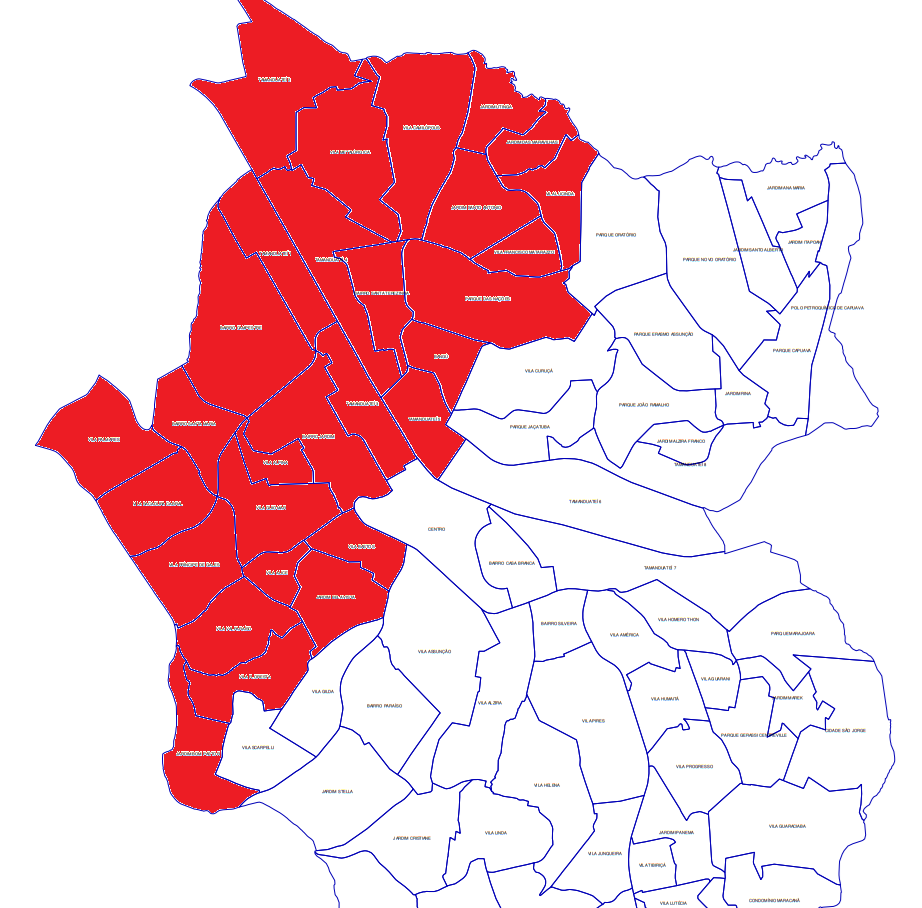

In [ ]:
df_chamados.head()

,end,dt
0,"AVN CAP MARIO TOLEDO DE CAMARGO, 6702 - JD IPA...",2004-09-15
1,"AVN CAP MARIO TOLEDO DE CAMARGO, 6702 - VL VIT...",2004-09-15
2,"AVN CAP MARIO TOLEDO DE CAMARGO, 6702 - VL HUM...",2004-09-15
3,"AVN CAP MARIO TOLEDO DE CAMARGO, 6702 - VL AME...",2004-09-15
4,"AVN CAP MARIO TOLEDO DE CAMARGO, 6702 - VL VIT...",2004-09-15


In [ ]:
df_chamados_neigh = df_chamados.copy()
df_chamados_neigh['bairro'] = df_chamados_neigh['end'].str.extract(r'-\s*([A-Z\s]+)$')

In [ ]:
target_bairros = ['VL PALMARES', 'VL SACADURA CABRAL', 'SANTA MARIA', 'CAMPESTRE', 'VL ALPINA',\
                  'VL GIOMAR', 'VL PRINCIPE DE GALES', 'VL VALPARAISO', 'VL BASTOS', 'JARDIM', 'VL ALPINA',\
                  'SANTA TEREZINHA', 'VL METALURGICA', 'VL LUCINDA', 'JD UTINGA', 'VL CAMILOPOLIS',\
                  'JD SANTO ANTONIO', 'JD DAS MARAVILHAS', 'PQ DAS NACOES', 'VL CURUCA', 'VL FLORESTA', 'JD BOM PASTOR',\
                  'VL FRANCISCO MATARAZZO']

df_chamados_tamanduatei = df_chamados_neigh[df_chamados_neigh['bairro'].isin(target_bairros)]

In [ ]:
df_chamados_tamanduatei_unique = df_chamados_tamanduatei.drop_duplicates('dt')

In [ ]:
df_chamados_tamanduatei_2017 = df_chamados_tamanduatei[df_chamados_tamanduatei['date'] > pd.Timestamp('2017-10-08')]

In [ ]:
df_tamanduatei_final = df_chamados_tamanduatei_2017.drop(columns=['bairro'])

In [ ]:
df_tamanduatei_final.head(3)

,SERVIÇO,ENDEREÇO,DATA,ENCAMINHAMENTO,SOLICITANTE,date
51127,809.1 - DDC - Enchente / Inundação / Alagament...,"RUA LAURO MULLER, 1130 - VL SACADURA CABRAL",27/11/2017,DRS (SEMASA),ORLANDO - DDC,2017-11-27
51441,809.4 - DDC - Enchente / Inundação / Alagament...,"RUA ORATORIO, 5115 - PQ DAS NACOES",23/01/2018,DMO (SEMASA) / VIGILANCIA SANITARIA,CARLOS ROBERTO PERES,2018-01-23
51855,809.2 - DDC - Enchente / Inundação / Alagament...,"RUA ARACI, 125 - VL CURUCA",20/03/2018,DMO (SEMASA),SONIA BATISTA DE CAMPOS,2018-03-20


In [ ]:
df_merge_new_tamanduatei = pd.merge(df_openw_merged_filtered, df_tamanduatei_final, how='left', on='date')
df_merge_new_tamanduatei.head()

,date,dpoint_ant_12_16,dpoint_ant_16_20,dpoint_ant_20_24,press_ant_12_16,press_ant_16_20,press_ant_20_24,rain_12_16,rain_16_20,rain_20_24,...,wind_deg_4_8,wind_deg_8_12,wind_deg_12_16,wind_deg_16_20,wind_deg_20_24,SERVIÇO,ENDEREÇO,DATA,ENCAMINHAMENTO,SOLICITANTE
0,2017-10-08,15.6775,14.0425,15.8425,1021.50,1019.00,1019.00,2.34,1.43,0.71,...,98.9700,69.2100,197.4650,316.7250,132.9725,NaN,NaN,NaN,NaN,NaN
1,2017-10-13,16.1850,12.7125,18.7475,1014.00,1012.25,1014.25,0.56,0.85,0.78,...,100.3175,66.9250,169.8050,213.7525,140.7875,NaN,NaN,NaN,NaN,NaN
2,2017-10-26,15.8350,16.9150,17.7050,1016.50,1013.25,1014.75,0.40,0.53,0.78,...,81.9700,90.1850,330.4125,271.3525,231.7125,NaN,NaN,NaN,NaN,NaN
3,2017-11-09,14.3325,16.3000,15.1950,1015.50,1013.75,1014.00,0.48,0.48,0.48,...,125.1650,124.3800,208.2000,181.8575,133.3925,NaN,NaN,NaN,NaN,NaN
4,2017-11-10,16.2375,16.3100,18.4550,1015.75,1013.50,1012.00,1.58,11.10,2.00,...,45.5375,89.8975,350.1850,319.2750,210.8525,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Create a new column 'has_chamado' based on the presence of non-NaN values in specified columns
df_merge_final_tamanduatei = df_merge_new_tamanduatei.copy()

# Drop the original columns
df_merge_final_tamanduatei['chamado'] = df_merge_final_tamanduatei[['SERVIÇO', 'ENDEREÇO', 'DATA', 'ENCAMINHAMENTO', 'SOLICITANTE']].notna().any(axis=1)
df_merge_final_tamanduatei = df_merge_final_tamanduatei.drop(columns=['SERVIÇO', 'ENDEREÇO', 'DATA', 'ENCAMINHAMENTO', 'SOLICITANTE','harshest_weather'])

df_merge_final_tamanduatei.shape


(550, 54)

In [ ]:
df_merge_final_tamanduatei[df_merge_final_tamanduatei.chamado == True].shape

(40, 54)

In [ ]:
### Preparando os dados
# Pegando dias e mes para analise

# Removendo colunas que nao podem ser usadas
df_merged_final_treat = df_merge_final_tamanduatei.drop(columns=['date', 'current_dt'])

# Dividir os dados em conjuntos de treino e teste
train_data, test_data = train_test_split(df_merged_final_treat, test_size=0.3, random_state=42)

# Configurar o ambiente do PyCaret
s= setup(data=df_merged_final_treat, fold=5, target='chamado', session_id = 123, fix_imbalance=True)

# Comparar modelos e escolher o melhor
best = compare_models(n_select=10)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(550, 52)"
4,Transformed data shape,"(879, 52)"
5,Transformed train set shape,"(714, 52)"
6,Transformed test set shape,"(165, 52)"
7,Numeric features,51
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
qda,Quadratic Discriminant Analysis,0.9273,0.6133,0.0000,0.0000,0.0000,0.0000,0.0000,0.1100
dummy,Dummy Classifier,0.9273,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0760
et,Extra Trees Classifier,0.8883,0.6981,0.0000,0.0000,0.0000,-0.0512,-0.0549,0.3520
rf,Random Forest Classifier,0.8831,0.6975,0.1133,0.1233,0.1178,0.0568,0.0563,0.7480
lightgbm,Light Gradient Boosting Machine,0.8805,0.6881,0.0800,0.1400,0.0971,0.0351,0.0407,3.6920
xgboost,Extreme Gradient Boosting,0.8623,0.6750,0.1467,0.0983,0.1168,0.0449,0.0467,0.2560
gbc,Gradient Boosting Classifier,0.8545,0.6726,0.1467,0.0900,0.1105,0.0336,0.0369,1.8420
dt,Decision Tree Classifier,0.8494,0.5223,0.1400,0.0872,0.1071,0.0280,0.0301,0.0780
ada,Ada Boost Classifier,0.8234,0.7055,0.1800,0.1067,0.1321,0.0434,0.0449,0.6000
lr,Logistic Regression,0.7896,0.6910,0.4933,0.1627,0.2415,0.1522,0.1890,0.2240


Processing:   0%|          | 0/74 [00:00<?, ?it/s]

<a name="sec7"></a>
# 7. Influência da sazonalidade

Até agora o que ficou bastante claro é que qualquer decisão de modelagem vai ficar ofuscada pelo caráter desbalanceado do dataset. Precisamos resolver isso e **ficou claro que oversampling não é o suficiente**.

Basicamente, o problema que temos é que existe uma desproporção entre a quantidade de dias em que há algum chamado de enchente registrado, que é um número muito menor do que a quantidade de dias sem chamado algum. A abordagem de oversampling envolve utilizar técnicas estatísticas para criar dados sintéticos, de modo que o dataset acabe preenchido com mais dados onde o label é positivo (ou seja, há chamado).

Como a estratégia mais fácil de implementar não foi bem sucedida, nos cabe agora partir para uma estratégia de *undersampling*, que basicamente faz o oposto; retirando dados ou usando uma estratégia específica para a seleção desses dados de modo que no final haja uma desproporção menor entre os dias com chamado e sem chamado.

Para isso, a ideia nesta seção é primeiro tentar fazer um corte nos dados sem utilizar qualquer abordagem estatística, mas sim entendendo um pouco mais sobre o fenômeno representado pelos dados. O primeiro dos alvos para esse entendimento é o efeito da **sazonalidade** e sua relação com os chamados de enchente. Para isso, agrupamos os dados por dia e separamos aqueles com algum chamado registrado. O resultado dessa análise pode ser visto no gráfico a seguir:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1Stj4tUMLI_MCjYgurs6aBPCWDN6je32R" alt="Image Description" style="max-width: 500px;">
</div>

Podemos ver que há uma incidência muito baixa de chamados nos meses de Maio, Junho, Julho, Agosto, Setembro e Outubro. O gráfico abaixo nos mostra como isso se traduz quando olhamos para **dias com chamado**:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=113afOEbWR5ODonTCOtbdrQjLPjgQo1YG" alt="Image Description" style="max-width: 500px;">
</div>

Basicamente temos a mesma conclusão. Supondo que utilizemos como filtro no dataset original apenas os meses de 1, 2, 3, 4, 11, e 12, essa é a situação que teríamos com relação aos dias com chamados:

* Dias com chamados antes do corte: 235
* Dias com chamados depois do corte: 223

Perder apenas 12 dias com chamados em troca de diminuir o dataset praticamente pela metade é uma ótima estratégia para diminuir o esforço que precisará ser feito no undersampling. O próximo passo agora é verificar se com esse filtro já temos um bom resultado ou se precisaremos diminuir ainda mais a desproporção.

Verificando sazonalidade dos chamados

In [ ]:
# Plot the number of lines per calendar month (group by month, regardless of the year)
df_chamados_pp['month'] = df_chamados_pp['dt'].dt.month
monthly_counts = df_chamados_pp.groupby('month')['dt'].count()
plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values)
plt.xlabel("Mês")
plt.ylabel("Chamados")
plt.title("Distribuição de chamados por mês")
plt.show()

# Plot the number of lines per calendar year
df_chamados_pp['year'] = df_chamados_pp['dt'].dt.year
yearly_counts = df_chamados_pp.groupby('year')['dt'].count()
plt.figure(figsize=(10, 6))
sns.barplot(x=yearly_counts.index, y=yearly_counts.values)
plt.xlabel("Ano")
plt.ylabel("Chamados")
plt.title("Distribuição de chamados por ano")
plt.show()

NameError: name 'df_chamados_pp' is not defined

Aqui chego à conclusão de que podemos eliminar os meses 5, 6, 7, 8, 9 e 10 sem perder muitos chamados (1881 vs 1902). Vamos ver por dias.

In [ ]:
df_chamados_daily = df_chamados_pp.drop_duplicates(subset=['dt'])

# Plot the number of lines per calendar month (group by month, regardless of the year)
df_chamados_daily['month'] = df_chamados_daily['dt'].dt.month
monthly_counts = df_chamados_daily.groupby('month')['dt'].count()
plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values)
plt.xlabel("Mês")
plt.ylabel("Dias com chamado")
plt.title("Dias com chamados por mes")
plt.show()

# Plot the number of lines per calendar year
df_chamados_daily['year'] = df_chamados_daily['dt'].dt.year
yearly_counts = df_chamados_daily.groupby('year')['dt'].count()
plt.figure(figsize=(10, 6))
sns.barplot(x=yearly_counts.index, y=yearly_counts.values)
plt.xlabel("Ano")
plt.ylabel("Dias com chamado")
plt.title("Dias com chamado por ano")
plt.show()

In [ ]:
df_chamados_daily_temp = df_chamados_daily[~df_chamados_daily['month'].between(5, 10)].copy()

df_chamados_daily_temp.shape, df_chamados_daily.shape

Também me parece razoável do ponto de vista de dias com chamado. Temos 223 x 235. Para tirarmos praticamente metade do ano, me parece justo.

<a name="sec8"></a>
# 8. Filtro por sazonalidade

A seguir, utilizamos a mesma modelagem de dados simples descrita na [primeira tentativa](#sec3) para verificar se basta esse recorte de dados para ter um bom resultado, portanto treinamos um modelo sem utilizar técnicas de oversampling, apenas com o corte dos meses fora da temporada de chuva. O resumo dos resultados pode ser visto a seguir:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1o2hyaebbqm-o9gKdKzgBRAPZvp9_OpNk" alt="Image Description" style="max-width: 500px;">
</div>

Os valores extremamente baixos de Recall e F1 score são o suficiente para que possamos afirmar que **não basta apenas fazer o filtro por sazonalidade**. No entanto, esse filtro é uma forma natural de reduzir o dataset original pela metade de uma forma que diminui significativamente a desproporção na variável desejada. Para a próxima etapa, vamos adicionar uma técnica de *undersampling*.

Fazendo o filtro no merge

In [ ]:
df_merged_m2 = df_merged_m1[~df_merged_m1['dt'].dt.month.between(5, 10)].copy()

df_merged_m1.chamado.value_counts(), df_merged_m2.chamado.value_counts()

(chamado
 False    2122
 True      235
 Name: count, dtype: int64,
 chamado
 False    1005
 True      223
 Name: count, dtype: int64)

Ficou bem menos desbalanceado. Vamos testar no pycaret.

Pycaret 1

In [ ]:
# Removendo colunas que nao podem ser usadas
df_merged_m2_final = df_merged_m2.drop(columns=['dt', 'predict_dt', 'weather_id'])

# Configurar o ambiente do PyCaret
s = setup(data=df_merged_m2_final, fold=5, target='chamado', session_id = 123)

# Comparar modelos e escolher o melhor
best = compare_models(n_select=10)

Legal, mas ainda está longe de resolver. Vamos ver agora qual o efeito de adicionar o filtro por id do clima ordinal.

<a name="sec9"></a>
# 9. Undersampling por clusters

A ideia por trás de qualquer algoritmo de undersampling é *utilizar uma técnica para diminuir a quantidade de dados* de modo a diminuir, também, a desproporção entre o label positivo e o negativo. Basicamente o objetivo é repetir o que foi feito na seção anterior, só que utilizando métodos puramente estatísticos ou de machine learning.

Para esta finalidade, não faz o menor sentido fazer esse undersampling a partir do dataset original, mas sim da versão já pré-filtrada por meses de temporada de chuva.

A técnica de undersampling escolhida foi a **por centróides de clusters**. O que isso significa? Significa que primeiro será feita uma clusterização ou um argupamento dos dados *com label negativo* do dataset a ser modificado e, para cada um desses grupos, vamos extrair apenas um dos dados. Qual valor vamos extrair? O centróide do grupo. O resultado disso é um dataset menor e sem desbalanceamento, mas que também garante que existe uma representatividade de cada um dos tipos diferentes de dados com label negativo.

Abaixo, a tabela com os resultados de treinamento após a aplicação dessa técnica:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1qe1Ay-8sxZURAJa7sUyQRtgeaI9aZBaJ" alt="Image Description" style="max-width: 500px;">
</div>

Agora sim! O resultado esta **notóriamente melhor** que qualquer outro treinamento que fizemos até então. No entanto, isso não significa que o problema foi resolvido por completo. Precisamos reproduzir esse resultado utilizando um conjunto de dados que não sofreu nenhuma transformação e também não fez parte do conjunto de treinamento. O resultado para esse conjunto no melhor modelo da tabela acima pode ser visto a seguir:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1J-LSrNNIDudRJIInYM0r-7TMEFf08LAq" alt="Image Description" style="max-width: 500px;">
</div>

O resultado está bem pior do que o que observamos no treino. Por quê isso aconteceu? Um subproduto conhecido de técnicas de under ou oversampling é um modelo que funciona muito bem para o dataset modificado, mas que não é capaz de generalizar esse aprendizado para conjuntos de dados externos. Em outras palavras, o modelo agora está *sobreajustado*.

Mesmo assim as últimas duas tentativas nos mostraram que existem duas técnicas que provavelmente devem continuar em nosso arsenal:

* Filtro por sazonalidade; e
* Undersampling.

Outra coisa que fica clara com esse resultado é que não terminamos ainda de lidar com o problema do desbalanceamento do dataset. A seguir, convém estudar mais estratégias para filtrar o dataset de modo orgânico, sem o uso de ferramentas estatísticas ou machine learning.

In [ ]:
df_merged_m4 = df_merged_m2.copy()
df_merged_m4.drop(columns=["weather_id", "dt", "predict_dt"], inplace=True)

# Dividir os dados em conjuntos de treino e teste de forma estratificada
train_data, test_data = train_test_split(df_merged_m4, test_size=0.20, stratify=df_merged_m4['chamado'], random_state=42)

train_data.chamado.value_counts()

,count
chamado,
False,804
True,178


In [ ]:
from imblearn.under_sampling import ClusterCentroids

# Assuming 'train_data' is your DataFrame and 'chamado' is the target column
X_train = train_data.drop(columns=['chamado'])
y_train = train_data['chamado']

# Initialize ClusterCentroids
cc = ClusterCentroids(random_state=42, sampling_strategy=1)

# Undersample the training data
X_resampled, y_resampled = cc.fit_resample(X_train, y_train)

# Create a new DataFrame with the resampled data
train_data_resampled = pd.concat([X_resampled, y_resampled], axis=1)


train_data_resampled.chamado.value_counts()

,count
chamado,
False,178
True,178


In [ ]:
# Configurar o ambiente do PyCaret
s = setup(data=train_data_resampled, fold=5, target='chamado', session_id = 123)

# Comparar modelos e escolher o melhor
best = compare_models(n_select=10)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(356, 25)"
4,Transformed data shape,"(356, 25)"
5,Transformed train set shape,"(249, 25)"
6,Transformed test set shape,"(107, 25)"
7,Numeric features,24
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8153,0.8895,0.8480,0.8038,0.8216,0.6307,0.6382,0.4000
xgboost,Extreme Gradient Boosting,0.7993,0.8509,0.8000,0.8025,0.7999,0.5983,0.6005,0.2160
ada,Ada Boost Classifier,0.7991,0.8489,0.7840,0.8103,0.7965,0.5982,0.5992,0.1940
qda,Quadratic Discriminant Analysis,0.7949,0.8218,0.8480,0.7729,0.8071,0.5891,0.5945,0.0360
et,Extra Trees Classifier,0.7911,0.8502,0.7760,0.8027,0.7882,0.5824,0.5841,0.3320
rf,Random Forest Classifier,0.7791,0.8594,0.8000,0.7748,0.7845,0.5581,0.5628,0.2460
dt,Decision Tree Classifier,0.7668,0.7667,0.7920,0.7666,0.7748,0.5334,0.5406,0.0380
lightgbm,Light Gradient Boosting Machine,0.7470,0.8438,0.7280,0.7635,0.7436,0.4940,0.4968,0.3900
nb,Naive Bayes,0.6865,0.7188,0.6080,0.7400,0.6604,0.3732,0.3859,0.0400
ridge,Ridge Classifier,0.6344,0.6598,0.6080,0.6481,0.6199,0.2690,0.2755,0.0380


Processing:   0%|          | 0/74 [00:00<?, ?it/s]

In [ ]:
best_model = create_model('gbc')
predicted = predict_model(best_model, data=test_data)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8400,0.8448,0.9600,0.7742,0.8571,0.6800,0.7005
1,0.8400,0.9472,0.7600,0.9048,0.8261,0.6800,0.6889
2,0.7800,0.8944,0.8400,0.7500,0.7925,0.5600,0.5641
3,0.7800,0.8992,0.8400,0.7500,0.7925,0.5600,0.5641
4,0.8367,0.8617,0.8400,0.8400,0.8400,0.6733,0.6733
Mean,0.8153,0.8895,0.8480,0.8038,0.8216,0.6307,0.6382
Std,0.0289,0.0353,0.0640,0.0603,0.0258,0.0578,0.0611


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.4106,0.7148,0.9111,0.2253,0.3612,0.0961,0.1847


<a name="sec10"></a>
# 10. Influência da precipitação

Para tentar fazer um corte orgânico dos dados, talvez a variável mais intuitiva seja a de precipitação. Para isso, estudamos a distribuição do acumulado de chuva durante todo o dia e comparamos a distribuição para dias com e sem chamado. O gráfico abaixo é o resultado dessa análise:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1x-UJMFVMKD07y9Wremha1v2EtFCH1iul" alt="Image Description" style="max-width: 500px;">
</div>

A versão interativa do gráfico acima pode ser vista nessa seção do notebook. A partir dela, um possível valor de corte utilizando o dado de chuva acumulada no dia se apresenta no primeiro quartil da distribuição para quando há chamados no dia. Com ela, temos o seguinte panorama:

* Antes do corte: 1005 linhas com 223 ocorrências de chamado;
* Depois do corte: 566 dias com 172 ocorrências de chamado.

Não é um recorte tão bom como o de sazonalidade, mas vale um teste.

In [ ]:
df_merged_m4.rain_1h.min()

2.4000000000000004

In [ ]:
import plotly.express as px

# Remove outliers (you can adjust the threshold as needed)
q1 = df_merged_m4['rain_1h'].quantile(0.25)
q3 = df_merged_m4['rain_1h'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df_filtered = df_merged_m4[(df_merged_m4['rain_1h'] >= lower_bound) & (df_merged_m4['rain_1h'] <= upper_bound)]

# Create a box plot using Plotly
fig = px.box(df_filtered, x="chamado", y="rain_1h", points="all")
fig.show()


In [ ]:
# prompt: now create df_merged_m4_rain where you just drop every line where rain is 0. Use df_merged_m2 as a base

df_merged_m4_rain = df_merged_m4[df_merged_m4['rain_1h'] > 7.805].copy()

df_merged_m4.chamado.value_counts(), df_merged_m4_rain.chamado.value_counts()

(chamado
 False    1005
 True      223
 Name: count, dtype: int64,
 chamado
 False    566
 True     172
 Name: count, dtype: int64)

<a name="sec11"></a>
# 11. Filtro por precipitação

Seguimos para mais um treinamento utilizando o dataset com os seguintes filtros:

* Filtro de sazonalidade, cortando os meses fora de temporada de enchentes; e
* Filtro de precipitação, cortando os dias com precipitação menor que o valor de corte definido na seção anterior.

Além disso, mantem-se o uso do undersampling por clusterização.

Os resultados de treinamento podem ser vistos na tabela abaixo:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1i8dGJAGqb0vF_Ju8bkooopWby9b0U4AO" alt="Image Description" style="max-width: 500px;">
</div>

Aqui notamos um resultado um pouco pior do que o visto no último teste. Isso é facilmente explicado pela menor quantidade de dados que temos para treinar o modelo agora. O que importa mesmo é se esse novo filtro foi o suficiente para corrigir o comportamento sobreajustado que estava presente no último teste. Vamos ver:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1HDoFSGkq1NEV6easm228vrA9wPw0nbon" alt="Image Description" style="max-width: 500px;">
</div>

A resposta é **não**. A perda de performance está um pouco menos acentuada, o que indica que de fato o problema era a agressividade do undersample. No entanto, fica claro aqui que em breve vamos esbarrar em um problema de *falta de dados* se continuarmos cortando o dataset.

Para validar a hipótese de que de fato essa diferença de performance vem da agressividade do undersample, abaixo podemos ver o resultado para uma situação em que utilizo o undersampling apenas para que a desproporção entre os labels fique de de 4 para 3 (ou seja, uma proporção de 0.75 entre dias sem chamado e com chamado). Os resultados podem ser vistos abaixo:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1CmfUXprpajJNk0NW_YDuf9_n_OSLijL3" alt="Image Description" style="max-width: 500px;">
</div>

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1oUlSuc61i9PnejAAMgEtC4b2E1FFPUgr" alt="Image Description" style="max-width: 500px;">
</div>

E de fato, o que vemos aqui é que o comportamento fica mais homogêneo quando fazemos um undersample menos agressivo.

A seguir, faz sentido olhar de forma mais genérica para o dataset e tentar encontrar novos pontos de corte que nos levem para mais próximo de um resultado aceitável. Além disso, também é razoável nesse momento voltar a testar novas abordagens de *feature engineering* para modelar os dados aos quais temos acesso.





In [ ]:
# Dividir os dados em conjuntos de treino e teste de forma estratificada
train_data, test_data = train_test_split(df_merged_m4_rain, test_size=0.20, stratify=df_merged_m4_rain['chamado'], random_state=42)

train_data.chamado.value_counts()

NameError: name 'df_merged_m4_rain' is not defined

In [ ]:
from imblearn.under_sampling import ClusterCentroids

# Assuming 'train_data' is your DataFrame and 'chamado' is the target column
X_train = train_data.drop(columns=['chamado'])
y_train = train_data['chamado']

# Initialize ClusterCentroids
cc = ClusterCentroids(random_state=42, sampling_strategy=0.75)

# Undersample the training data
X_resampled, y_resampled = cc.fit_resample(X_train, y_train)

# Create a new DataFrame with the resampled data
train_data_resampled = pd.concat([X_resampled, y_resampled], axis=1)


train_data_resampled.chamado.value_counts()

In [ ]:
# Configurar o ambiente do PyCaret
s = setup(data=train_data_resampled, fold=5, target='chamado', session_id = 123, fix_imbalance=False)

# Comparar modelos e escolher o melhor
best = compare_models(n_select=10)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(356, 25)"
4,Transformed data shape,"(356, 25)"
5,Transformed train set shape,"(249, 25)"
6,Transformed test set shape,"(107, 25)"
7,Numeric features,24
8,Preprocess,True
9,Imputation type,simple


,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,17:40:20
Status,. . . . . . . . . . . . . . . . . .,Fitting 5 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)


Processing:   0%|          | 0/74 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
predicted = predict_model(best[0], data=test_data)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.5743,0.6231,0.7353,0.3165,0.4425,0.1786,0.2206


In [ ]:
from sklearn.cluster import KMeans

n = 150  # Number of clusters

# Select data where 'chamado' is False
df_no_chamado = train_data[train_data['chamado'] == False].copy()

# Perform KMeans clustering
kmeans = KMeans(n_clusters=n, random_state=0)
kmeans.fit(df_no_chamado)

# Create a new DataFrame with cluster centroids
df_centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df_no_chamado.columns)

# Add a column to identify the centroids
df_centroids['is_centroid'] = True

# Select data where 'chamado' is True
df_chamado = train_data[train_data['chamado'] == True].copy()

# Concatenate the centroids DataFrame with the original data where 'chamado' is True
df_final = pd.concat([df_centroids, df_chamado], ignore_index=True)

df_final.chamado.value_counts()

,count
chamado,
1.0,171
0.0,150


<a name="sec12"></a>
# 12. Análise das distribuições

O objetivo desta seção foi criar ferramentas para avaliar as distribuições dos features para quando há chamados e quando não há. Para isso, foram criadas 3 ferramentas distintas:

1. Gerador de box plot - essa ferramenta serve para criar boxplots automaticos a partir de um menu drop down. Com ela, conseguimos - para um determinado dataframe - avaliar como é a diferença de cada feature quando o separamos por ocorrências de enchente;
2. Simulador de cortes - essa ferramenta permite que um corte no dataset seja simulado a partir do nome de uma de suas colunas e um valor de corte. A resposta da ferramenta é a quantidade de ocorrências de enchente vs dias sem ocorrência antes e depois do corte;
3. Automatizador de cortes - essa ferramenta utiliza estratégias conservadoras de cortes; mantendo apenas aqueles cortes cuja combinação de feature e limiar não gera nenhuma perda de ocorrência de enchentes. Para todos os efeitos, essa é uma ferramenta para automatizar os cortes que são "gratuitos" - ou seja - que não nos fazem perder nenhuma ocorrência de enchente.

Utilizando essas três ferramentas, foi possível estabelecer um procedimento para tornar o dataset mais enxuto e - como consequência direta - menos desbalanceado. O procedimento envolve:

1. Realizar os cortes "gratuitos";
2. Utilizando a ferramenta de gerar box plots, avaliar para quais features há diferenças palpáveis na distribuição em dias com e sem chamados; e
3. Com as informações extraídas do gráfico, fazer cortes "manuais" que separam ainda mais o dataset.

Exemplo das ferramentas:

**Box plots**

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=16jdEZflhAyCH3dHRIq0tAtd5-Ln6ZYDW" alt="Image Description" style="max-width: 500px;">
</div>

Com essa comparação direta foi possível perceber, por exemplo, a importância do ponto de orvalho para esses cortes.

**Avaliação de cortes**

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1G4LmczayqLQJWLeafk5WOhCTOtu7sB2a" alt="Image Description" style="max-width: 500px;">
</div>

**Cortes automatizados**

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=14-RSqKf6OK4vx0Hb2kl3TsdGjMXio7cR" alt="Image Description" style="max-width: 500px;">
</div>

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Function to create and update the box plot
def create_box_plot(df):
    # Filter outliers from all columns
    filtered_df = df.copy()

    # Define buttons for the dropdown menu
    buttons = []
    for col in filtered_df.columns:  # Use filtered_df for dropdown options
        if col != 'chamado':
            buttons.append(dict(
                label=col,
                method='update',
                args=[{'y': [filtered_df[col]]},  # Update y data directly
                      {'yaxis.title.text': col}]  # Update y-axis label
            ))

    buttons.sort(key=lambda x: x['label'])

    # Create a box plot using Plotly
    fig = px.box(filtered_df, x="chamado", y=buttons[0]["label"], points="all")

    # Update layout with dropdown menu
    fig.update_layout(
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                pad={"r": 10, "t": 10},
                showactive=True,
                x=0.1,
                xanchor="left",
                y=1.15,
                yanchor="top"
            ),
        ]
    )

    fig.show()

**Avaliando distribuições NO DIA**

In [ ]:
# Initial box plot with 'rain_1h'
create_box_plot(df_merged_m4)

**Avaliando distribuições do DIA ANTERIOR**

In [ ]:
df_merged_m4_shifted = df_merged_m4.copy()

# Shift columns up by one row, excluding 'chamado' and '_fore' columns
cols_to_shift = [col for col in df_merged_m4_shifted.columns if col != 'chamado' and not col.endswith('_fore')]
for col in cols_to_shift:
    df_merged_m4_shifted[col] = df_merged_m4_shifted[col].shift(-1)

# Delete the last row
df_merged_m4_shifted.drop(df_merged_m4.tail(1).index, inplace=True)

In [ ]:
create_box_plot(df_merged_m4_shifted)

In [ ]:
import plotly.express as px

# Remove outliers (you can adjust the threshold as needed)
q1 = df_merged_m4_shifted['rain_fore'].quantile(0.25)
q3 = df_merged_m4_shifted['rain_fore'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df_filtered = df_merged_m4_shifted[(df_merged_m4_shifted['rain_fore'] >= lower_bound) & (df_merged_m4_shifted['rain_fore'] <= upper_bound)]

# Create a box plot using Plotly
fig = px.box(df_filtered, x="chamado", y="rain_fore", points="all")
fig.show()

**Testando cortes**

In [ ]:
df_mmerge4_cut1 = iterative_lower_fence_cuts(df_merged_m4_shifted, true_cut_max=2)

Applying cut on feature 'dew_point_fore' with threshold 11.537500000000001, removing 35 false cases and 0 true cases
Applying cut on feature 'dew_point' with threshold 12.446145833333336, removing 18 false cases and 0 true cases
Applying cut on feature 'humidity_fore' with threshold 50.13750000000003, removing 13 false cases and 2 true cases
Applying cut on feature 'dew_point_fore' with threshold 12.234999999999996, removing 8 false cases and 0 true cases
Applying cut on feature 'dew_point' with threshold 12.735178571428573, removing 7 false cases and 0 true cases
Applying cut on feature 'humidity' with threshold 57.682291666666636, removing 5 false cases and 0 true cases
Applying cut on feature 'pressure' with threshold 1006.6418131868132, removing 4 false cases and 1 true cases
Applying cut on feature 'dew_point' with threshold 12.833700961538465, removing 4 false cases and 0 true cases
Applying cut on feature 'humidity_fore' with threshold 51.53124999999999, removing 3 false cases a

In [ ]:
create_box_plot(df_mmerge4_cut1)

In [ ]:
df_mmerge4_cut2 = verifica_corte(df_mmerge4_cut1, 'humidity', 62)

Filtrando humidity com corte em 62
Antes do corte vs Depois do corte (tamanho total): 1115 vs 1083
Antes do corte vs Depois do corte (chamados): 
chamado
False    896
True     219
Name: count, dtype: int64 vs 
chamado
False    865
True     218
Name: count, dtype: int64


In [ ]:
create_box_plot(df_mmerge4_cut2)

In [ ]:
df_mmerge4_cut3 = verifica_corte(df_mmerge4_cut2, 'temperature_fore', 18.5)

Filtrando temperature_fore com corte em 18.5
Antes do corte vs Depois do corte (tamanho total): 1083 vs 931
Antes do corte vs Depois do corte (chamados): 
chamado
False    865
True     218
Name: count, dtype: int64 vs 
chamado
False    728
True     203
Name: count, dtype: int64


In [ ]:
create_box_plot(df_mmerge4_cut3)

In [ ]:
df_mmerge4_cut4 = verifica_corte(df_mmerge4_cut3, 'rain_1h', 4.1)

Filtrando rain_1h com corte em 4.1
Antes do corte vs Depois do corte (tamanho total): 931 vs 811
Antes do corte vs Depois do corte (chamados): 
chamado
False    728
True     203
Name: count, dtype: int64 vs 
chamado
False    619
True     192
Name: count, dtype: int64


In [ ]:
create_box_plot(df_mmerge4_cut4)

In [ ]:
df_mmerge4_cut5 = iterative_lower_fence_cuts(df_mmerge4_cut4, true_cut_max=0, min=True)

Applying cut on feature 'clouds_fore' with threshold 0.0, removing 12 false cases and 0 true cases
Applying cut on feature 'temperature_fore' with threshold 18.51, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_fore' with threshold 18.53, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore' with threshold 0.07, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore' with threshold 0.68, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore' with threshold 0.75, removing 1 false cases and 0 true cases
Applying cut on feature 'feels_like' with threshold 16.886400000000002, removing 1 false cases and 0 true cases
Applying cut on feature 'feels_like' with threshold 17.04041666666667, removing 1 false cases and 0 true cases
Applying cut on feature 'feels_like' with threshold 17.264583333333334, removing 1 false cases and 0 true cases
Applying cut on feature 'feels_like' with threshold 1

<a name="sec13"></a>
# 13. Teste com novos cortes

Com as ferramentas descritas acima, foram feitas diversas iterações de cortes manuais até que atingisse-se uma proporção próxima a *3:1* de dias com e sem chamados. Com esse novo dataset filtrado, foi possível atingir o seguinte resultado - utilizando a mesma proporção de udersample de 0.75 utilizada na seção 11 -:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1Pugbh34Il4DnFvpNlut5MSE9LfSW-Ly9" alt="Image Description" style="max-width: 500px;">
</div>

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1Xl8cRMKArpxNaFwTVh3hGEkYKO93bhIi" alt="Image Description" style="max-width: 500px;">
</div>

Para relembrar, os resultados obtidos com 0.75 de proporção de undersampling na seção 11 foram:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1CmfUXprpajJNk0NW_YDuf9_n_OSLijL3" alt="Image Description" style="max-width: 500px;">
</div>

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1oUlSuc61i9PnejAAMgEtC4b2E1FFPUgr" alt="Image Description" style="max-width: 500px;">
</div>

Nota-se uma leve queda de acurácia, um aumento do *recall* e uma precisão um pouco mais baixa nos resultados de validação. Por outro lado, os resultados apresentados no conjunto de teste são melhores em quase todos os indicadores.

A conclusão aqui é de que os novos cortes ainda não fizeram a diferença na queda de braço entre recall e precisão dos resultados de validação. No entanto, tivemos um novo melhor resultado de treinamento. A seguir, faz sentido testar novas abordagens de modelagem.


In [ ]:
from imblearn.under_sampling import ClusterCentroids
def train_and_evaluate_model(df, target, test_size, sampling_strategy=0):

    # Split data into training and testing sets
    train_data, test_data = train_test_split(df, test_size=test_size, stratify=df[target], random_state=42)

    # Undersample the training data using Cluster Centroids
    if sampling_strategy:
      X_train = train_data.drop(columns=[target])
      y_train = train_data[target]
      cc = ClusterCentroids(random_state=42, sampling_strategy=sampling_strategy)
      X_resampled, y_resampled = cc.fit_resample(X_train, y_train)
      train_data_resampled = pd.concat([X_resampled, y_resampled], axis=1)
    else:
      train_data_resampled = train_data.copy()

    # Setup PyCaret environment
    s = setup(data=train_data_resampled, target=target, session_id=123, fix_imbalance=False)

    # Compare models and select the best one
    best_model = compare_models(n_select=5)

    for model in best_model:
      predicted = predict_model(model, data=test_data)

In [ ]:
train_and_evaluate_model(df_mmerge4_cut5,
                         "chamado",
                         test_size=0.15,
                         sampling_strategy=0.5)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(489, 25)"
4,Transformed data shape,"(489, 25)"
5,Transformed train set shape,"(342, 25)"
6,Transformed test set shape,"(147, 25)"
7,Numeric features,24
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7251,0.6869,0.4424,0.6476,0.5118,0.3334,0.3523,0.4540
lightgbm,Light Gradient Boosting Machine,0.7131,0.7007,0.4303,0.6192,0.4832,0.3028,0.3219,0.3510
ridge,Ridge Classifier,0.7077,0.6596,0.3614,0.6131,0.4440,0.2678,0.2893,0.0340
lr,Logistic Regression,0.7045,0.6418,0.3167,0.6250,0.4092,0.2436,0.2732,0.3580
lda,Linear Discriminant Analysis,0.6900,0.6617,0.3879,0.5609,0.4512,0.2481,0.2596,0.0340
rf,Random Forest Classifier,0.6899,0.7096,0.2735,0.5749,0.3532,0.1935,0.2197,0.3060
xgboost,Extreme Gradient Boosting,0.6870,0.6747,0.4402,0.5594,0.4800,0.2656,0.2750,0.1670
ada,Ada Boost Classifier,0.6782,0.6486,0.4492,0.5388,0.4766,0.2520,0.2606,0.3060
dummy,Dummy Classifier,0.6667,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0490
et,Extra Trees Classifier,0.6638,0.6474,0.1750,0.4292,0.2422,0.0942,0.1020,0.1960


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.7304,0.6592,0.4828,0.4667,0.4746,0.2934,0.2934


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.6609,0.5950,0.3448,0.3333,0.3390,0.1110,0.1110


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.6870,0.5621,0.3103,0.3600,0.3333,0.1303,0.1309


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7130,0.6524,0.2759,0.4000,0.3265,0.1520,0.1562


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.6957,0.6022,0.4138,0.4000,0.4068,0.2022,0.2022


<a name="sec14"></a>
# 14. Modelagem por variação no período

Uma das estratégias iniciais adotadas e que sempre foi entendida como ingênua foi a de simplesmente utilizar um recorte temporal dos dados - tanto do dataset de dados históricos como do dataset de *forecasts -; esta abordagem pode ser vista na imagem a seguir, retirada da seção 4:

![modelagem1](https://drive.google.com/uc?export=view&id=1Hlc7aNoU6rPxyODzoJUVpgDFxcabZkgs)

Apesar de ser uma estratégia admitidamente simplista, ela era adequada enquanto nosso problema principal se resumia ao desbalanceamento do dataset. Embora este problema ainda exista, faz sentido finalmente contemplar outra abordagem estatística para resumir os períodos relevantes para a predição.

Aqui, inicia-se um processo de agrupar os dois dias de importância - aquele que é imediatamente anterior à predição (para o qual tem-se os dados históricos); e aquele que é o próprio dia da medição (para o qual tem-se dados de *forecast*) -, utilizando agregadores estatísticos como a média, máximo e mínimo com uma determinada periodicidade. O objetivo é conseguir caputrar de forma mais fidedigna as variações que ocorrem para cada um dos features originais do dataset.

Para facilitar esse processo, foi criada uma nova subrotina. Esta subrotina é capaz de criar um dicionário de filtros variando os seguintes aspectos:

1. Periodicidade de agregador - esse é o valor, em horas, que determina de quanto em quanto tempo serão calculados os agregados;
2. Inicio e fim do período - definidos a partir da hora 0 do dia-alvo; e
3. Quais agregadores serão utilizados.

Com essa ferramenta, será possível iterar rapidamente e entender se esse tipo de modelagem tem um impacto significativo nos resultados dos modelos.

Neste momento, no entanto, foi feito apenas um teste novo:

**Dia anterior (histórico)**:

Agrega os valores das últimas 24 horas do dia anterior.

**Dia da predição (forecast)**:

Agrega, de 12 em 12 horas, as 24 horas do dia da predição

**Agregadores**:

* Média do período; e
* Diferença entre o maior e o menor valor do período.

Após feita essa modelagem, foi utilizada a ferramenta de cortes automáticos para reduzir o desbalanceamento do dataset. Para este teste **não foram feitos os cortes manuais**. Os resultados obtidos podem ser vistos a seguir:

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1ZB0P1ZRjnQkUSImiWGTtCiIu_X7vWssU" alt="Image Description" style="max-width: 500px;">
</div>

<div style="text-align: center;">
  <img src="https://drive.google.com/uc?export=view&id=1_ybfSfzimAFboZOHF2uCBxfzY9Obi_zw" alt="Image Description" style="max-width: 500px;">
</div>

Novamente, foi possível ver uma melhora nos resultados de treinamento para um undersampling de 0.75. Os resultados de validação, embora tenham retrocedido, provavelmente são uma consequência da omissão dos cortes manuais. Para os próximos passos, faz sentido refazer o teste acima com cortes manuais e, sem seguida, utilizar a nova ferramenta de modelagem para testar novas estratégias de agregação.

Filtrando openw por periodo

In [ ]:
df_openw14_filled = fill_missing(df_openw, df_openw.columns)
df_openw14_shifted = shift_column_up(df_openw14_filled, ["dt"], 24)
df_openw14_filtered = df_openw14_shifted[df_openw14_shifted["dt"] >= '2017-10-07']

In [ ]:
agg_config = {
 'temp': (24, ('mean',)),
 'visibility': (24, ('mean',)),
 'dew_point': (6, ('mean', 'delta')),
 'feels_like': (24, ('max', 'min')),
 'temp_min': (6, ('min', "delta")),
 'temp_max': (6, ('max', "delta")),
 'pressure': (24, ('mean',)),
 'humidity': (24, ('mean',)),
 'wind_speed': (24, ('mean',)),
 'wind_deg': (24, ('mean',)),
 'wind_gust': (24, ('mean',)),
 'rain_1h': (24, ('sum',)),
 'clouds_all': (24, ('mean',)),
}

In [ ]:
df_openw14_agg = df_openw14_filtered.groupby(pd.Grouper(key='dt', freq='D')) \
    .agg(**create_agg_dict(agg_config)).reset_index()

Agregando openwf de 12 em 12 horas de 0 até 24 horas

In [ ]:
df_openwf14_filled = fill_missing(df_openwf, df_openwf.columns)

In [ ]:
agg_config = {
 'temperature_fore': (3, ('mean', 'delta')),
 'pressure_fore': (24, ('delta',)),
 'humidity_fore': (24, ('delta',)),
 'clouds_fore': (12, ('mean',)),
 'wind_speed_fore': (12, ('mean',)),
 'wind_deg_fore': (24, ('mean',)),
 'rain_fore': (3, ('sum',)),
 'convective_fore': (24, ('delta',)),
 'probability_fore': (12, ('delta',))
}

In [ ]:
df_openwf14_agg = df_openwf14_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()

Merge

In [ ]:
df_merged14 = df_openw14_agg.merge(df_openwf14_agg, left_on="dt", right_on="dt")
df_merged14["chamado"] = df_merged14["dt"].isin(df_chamados_pp_unique["dt"])

Removendo os meses não utilizados

In [ ]:
df_merged14_seasonal = df_merged14[~df_merged14['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])
df_merged14_seasonal[df_merged14_seasonal["chamado"] == True].shape

(223, 70)

Cortes automaticos

In [ ]:
df_merged14_cut1 = iterative_lower_fence_cuts(df_merged14_seasonal, true_cut_max=7)

Applying cut on feature 'dew_point_fore_18_21_mean' with threshold 10.518749999999994, removing 50 false cases and 1 true cases
Applying cut on feature 'dew_point_0_6_mean' with threshold 11.997499999999999, removing 29 false cases and 1 true cases
Applying cut on feature 'dew_point_fore_15_18_mean' with threshold 10.379166666666668, removing 22 false cases and 1 true cases
Applying cut on feature 'dew_point_fore_21_24_mean' with threshold 12.828750000000005, removing 21 false cases and 2 true cases
Applying cut on feature 'dew_point_12_18_mean' with threshold 12.647500000000006, removing 20 false cases and 0 true cases
Applying cut on feature 'dew_point_fore_3_6_mean' with threshold 12.788333333333332, removing 13 false cases and 2 true cases
Applying cut on feature 'dew_point_fore_15_18_mean' with threshold 11.319166666666666, removing 14 false cases and 3 true cases
Applying cut on feature 'dew_point_0_6_mean' with threshold 12.794166666666664, removing 11 false cases and 4 true cas

In [ ]:
df_merged14_cut2 = iterative_lower_fence_cuts(df_merged14_cut1, min=True)

Applying cut on feature 'pressure_0_24_mean' with threshold 1007.125, removing 2 false cases and 0 true cases
Applying cut on feature 'temp_min_12_18_min' with threshold 15.84, removing 2 false cases and 0 true cases
Applying cut on feature 'dew_point_fore_6_9_delta' with threshold 0.0, removing 2 false cases and 0 true cases
Applying cut on feature 'temperature_fore_9_12_delta' with threshold 0.05000000000000071, removing 2 false cases and 0 true cases
Applying cut on feature 'dew_point_fore_12_15_delta' with threshold 0.0, removing 1 false cases and 0 true cases
Applying cut on feature 'dew_point_fore_12_15_delta' with threshold 0.00999999999999801, removing 1 false cases and 0 true cases
Applying cut on feature 'dew_point_fore_12_15_delta' with threshold 0.010000000000001563, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_fore_18_21_delta' with threshold 0.019999999999999574, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_f

In [ ]:
create_box_plot(df_merged14_cut2)

In [ ]:
df_merged14_cut3 = check_cut(df_merged14_cut2, 'dew_point_0_6_mean', 14.3)

Filtrando dew_point_fore_3_6_mean com corte em 15
Antes do corte vs Depois do corte (tamanho total): 784 vs 772
Antes do corte vs Depois do corte (chamados): 
chamado
False    586
True     198
Name: count, dtype: int64 vs 
chamado
False    575
True     197
Name: count, dtype: int64


Primeiro teste

In [ ]:
best_models14 = train_and_evaluate_model(df_merged14_cut2,
                         "chamado",
                         test_size=0.15,
                         sampling_strategy=0.75)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(392, 87)"
4,Transformed data shape,"(392, 87)"
5,Transformed train set shape,"(274, 87)"
6,Transformed test set shape,"(118, 87)"
7,Numeric features,86
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.7190,0.7754,0.5826,0.7180,0.6337,0.4122,0.4251,0.4620
lightgbm,Light Gradient Boosting Machine,0.7190,0.7830,0.5932,0.7237,0.6406,0.4165,0.4310,0.3250
gbc,Gradient Boosting Classifier,0.7012,0.7715,0.5500,0.7158,0.6128,0.3760,0.3930,0.6380
et,Extra Trees Classifier,0.6970,0.7731,0.5053,0.7271,0.5828,0.3586,0.3817,0.3710
dt,Decision Tree Classifier,0.6714,0.6649,0.6227,0.6243,0.6175,0.3305,0.3361,0.0570
ada,Ada Boost Classifier,0.6679,0.7303,0.5591,0.6324,0.5814,0.3134,0.3216,0.2390
rf,Random Forest Classifier,0.6571,0.7568,0.4962,0.6320,0.5477,0.2805,0.2909,0.8750
lda,Linear Discriminant Analysis,0.6544,0.6652,0.5386,0.6155,0.5689,0.2829,0.2885,0.0780
ridge,Ridge Classifier,0.6430,0.6675,0.5212,0.5945,0.5508,0.2576,0.2623,0.0470
lr,Logistic Regression,0.6311,0.6411,0.4970,0.5855,0.5343,0.2329,0.2367,0.2580


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.5508,0.6186,0.6000,0.3051,0.4045,0.1017,0.1168


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.5847,0.6000,0.6000,0.3273,0.4235,0.1409,0.1567


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.5932,0.6091,0.6333,0.3393,0.4419,0.1656,0.1856


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.6441,0.5960,0.4667,0.3500,0.4000,0.1543,0.1575


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Decision Tree Classifier,0.5339,0.5447,0.5667,0.2881,0.3820,0.0678,0.0778


In [ ]:
# prompt: create a pickle file from the best model from the last pycaret run

import pickle

# Assuming 'best' is the best model from the last pycaret run
# and you want to save it to a file named 'best_model.pkl'

pickle.dump(best_models14[0], open('best_model.pkl', 'wb'))

In [ ]:
# prompt: use the pickle file to load the best model and run a prediction with a numpy array filled with zeros

import pickle
import numpy as np

# Load the saved model
loaded_model = pickle.load(open('best_model.pkl', 'rb'))

# Create a NumPy array filled with zeros
input_data = np.random.rand(1, 86) # Assuming 14 features, adjust as necessary

# Make a prediction
prediction = loaded_model.predict(input_data)

prediction

array([1])

In [ ]:
# prompt: extract a random row from df_merged14_cut2 where chamado is true and another where chamado is false, then turn the rows into numpy arrays and use the pickle model to predict for them

import pandas as pd
import numpy as np
import pickle

# Load the saved model
loaded_model = pickle.load(open('best_model.pkl', 'rb'))

# Assuming df_merged14_cut2 is your DataFrame
# Extract a random row where 'chamado' is True
true_row = df_merged14_cut2[df_merged14_cut2['chamado'] == True].sample(n=1)
# Extract a random row where 'chamado' is False
false_row = df_merged14_cut2[df_merged14_cut2['chamado'] == False].sample(n=1)

# Convert rows to NumPy arrays, excluding the 'chamado' column
true_array = true_row.drop(columns=['chamado']).values
false_array = false_row.drop(columns=['chamado']).values

# Make predictions
true_prediction = loaded_model.predict(true_array)
false_prediction = loaded_model.predict(false_array)

print("Prediction for 'chamado' == True:", true_prediction)
print("Prediction for 'chamado' == False:", false_prediction)

Prediction for 'chamado' == True: [1]
Prediction for 'chamado' == False: [0]


# Modelo apenas com forecasts

In [ ]:
df_openwf15_filled = fill_missing(df_openwf, df_openwf.columns)

In [ ]:
agg_config = {
 'temperature_fore': (3, ("mean", "delta", "median")),
 'pressure_fore': (3, ("mean", "delta", "median")),
 'humidity_fore': (3, ("mean", "delta", "median")),
 'clouds_fore': (3, ("mean", "delta", "median")),
 'wind_speed_fore': (3, ("mean", "delta", "median")),
 'wind_deg_fore': (3, ("mean", "delta", "median")),
 'rain_fore': (24, ("sum", "mean", "delta", "median")),
 'probability_fore': (3, ("mean", "delta", "median"))
}

In [ ]:
df_openwf15_agg = df_openwf15_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()


In [ ]:
df_openwf15_agg.rain_fore_0_24_sum.describe()

,rain_fore_0_24_sum
count,2357.000000
mean,3.267132
std,6.827202
min,0.000000
25%,0.000000
50%,0.000000
75%,3.300000
max,92.110000


In [ ]:
# Assuming df_chamados_pp_unique is defined somewhere in your previous code
# and contains a 'dt' column representing dates and the number of occurrences per day.

df_chamados_count = df_chamados.groupby('dt').size().reset_index(name='counts')

In [ ]:
# Merge the aggregated weather forecast data with the 'chamados' data
df_merged15 = df_openwf15_agg.copy()
df_merged15['chamado'] = df_merged15['dt'].isin(df_chamados_count['dt']).astype(int)

# Merge the counts into the main DataFrame
df_merged15 = pd.merge(df_merged15, df_chamados_count, on='dt', how='left')

# Fill NaN values in 'chamado_counts' with 0 (days with no chamados)
df_merged15['counts'].fillna(0, inplace=True)

In [ ]:
df_merged15_seasonal = df_merged15[~df_merged15['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])

In [ ]:
df_merged15_cut1 = iterative_lower_fence_cuts(df_merged15_seasonal, true_cut_max=0)

Applying cut on feature 'humidity_fore_0_3_mean' with threshold 51.927500000000016, removing 25 false cases and 0 true cases
Applying cut on feature 'temperature_fore_3_6_mean' with threshold 13.500833333333336, removing 12 false cases and 0 true cases
Applying cut on feature 'humidity_fore_6_9_mean' with threshold 60.8566666666667, removing 8 false cases and 0 true cases
Applying cut on feature 'pressure_fore_18_21_median' with threshold 1003.8, removing 6 false cases and 0 true cases
Applying cut on feature 'humidity_fore_9_12_median' with threshold 54.87000000000001, removing 4 false cases and 0 true cases
Applying cut on feature 'temperature_fore_6_9_median' with threshold 13.019999999999996, removing 4 false cases and 0 true cases
Applying cut on feature 'humidity_fore_0_3_mean' with threshold 54.510000000000055, removing 3 false cases and 0 true cases
Applying cut on feature 'temperature_fore_18_21_mean' with threshold 15.380416666666667, removing 3 false cases and 0 true cases
A

In [ ]:
df_merged15_cut2 = iterative_lower_fence_cuts(df_merged15_cut1, min=True)

Applying cut on feature 'pressure_fore_6_9_delta' with threshold 0.029999999999972715, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_12_15_delta' with threshold 0.010000000000000009, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_9_12_delta' with threshold 0.0, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_9_12_delta' with threshold 0.009999999999999787, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_9_12_delta' with threshold 0.010000000000000231, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_3_6_delta' with threshold 0.060000000000002274, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_18_21_delta' with threshold 0.009999999999999787, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_18_21_delta' with threshold 0.019999999999999574, removing 2 false cas

In [ ]:
best_models15, train_data, test_data = train_and_evaluate_model(df_merged15_cut2,
                         ["chamado", "counts"],
                         test_size=0.3,
                         sampling_strategy=0.75)

Não tem a coluna counts
Não tem a coluna chamado


,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(364, 173)"
4,Transformed data shape,"(400, 173)"
5,Transformed train set shape,"(290, 173)"
6,Transformed test set shape,"(110, 173)"
7,Numeric features,172
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.6763,0.7120,0.6064,0.6360,0.6184,0.3375,0.3393,0.4600
ada,Ada Boost Classifier,0.6566,0.6574,0.6073,0.6118,0.6048,0.3017,0.3052,0.4780
xgboost,Extreme Gradient Boosting,0.6560,0.7022,0.5873,0.6027,0.5941,0.2956,0.2963,0.7950
gbc,Gradient Boosting Classifier,0.6520,0.6984,0.5682,0.6102,0.5841,0.2849,0.2893,1.3410
rf,Random Forest Classifier,0.6482,0.6869,0.5036,0.6148,0.5486,0.2655,0.2721,0.3480
lr,Logistic Regression,0.6294,0.6405,0.5764,0.5618,0.5658,0.2418,0.2438,0.8860
ridge,Ridge Classifier,0.6251,0.6631,0.5782,0.5664,0.5705,0.2379,0.2388,0.0890
et,Extra Trees Classifier,0.6103,0.6391,0.4509,0.5508,0.4936,0.1851,0.1872,0.2310
qda,Quadratic Discriminant Analysis,0.5708,0.4706,0.0000,0.0000,0.0000,0.0000,0.0000,0.0990
dummy,Dummy Classifier,0.5708,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0600


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.5230,0.5979,0.5672,0.2639,0.3602,0.0547,0.0650


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.5018,0.5325,0.4925,0.2357,0.3188,-0.0021,-0.0024


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.5406,0.6314,0.6567,0.2914,0.4037,0.1126,0.1375


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.5265,0.5842,0.5672,0.2657,0.3619,0.0583,0.0689


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.6042,0.6367,0.5970,0.3200,0.4167,0.1567,0.1742


In [ ]:
best_models15[0].feature_importances_

array([ 4,  1,  4,  0,  2,  2,  2,  4,  6,  5,  5,  1,  5,  0, 11,  2,  0,
       11,  1,  1,  2,  0,  2,  3,  4,  3, 18,  1,  0, 14,  2,  0, 12,  3,
        1, 22,  3,  0, 30,  2,  0, 23,  4,  1, 16,  1,  1, 11,  8, 11, 14,
        4,  2, 10,  4,  0,  5,  7,  3,  4,  0,  0,  6,  1,  1,  8,  2,  1,
        5,  2,  0,  6,  2,  1, 37,  8,  0,  7,  7,  0, 11,  4,  3, 15,  2,
        1,  9,  8,  0,  4,  6,  0, 13,  3,  1,  7,  8,  2,  8, 11,  1,  9,
        6,  4, 26,  4,  2, 20,  6,  5,  6,  5,  6,  8,  4,  1,  5,  3,  0,
       20,  8,  4,  8, 12,  4,  9, 13,  8, 49,  3,  1, 21,  2,  0, 11,  1,
        3,  9,  8, 11, 17,  4, 13, 18,  3,  0,  0,  6,  2,  2,  6,  3,  1,
       10,  1,  4, 10,  1,  0,  5,  5,  1, 10,  2,  1, 12,  1,  0, 11,  1,
        1,  2], dtype=int32)

In [ ]:
# prompt: show me the names of the 5 most important features of best_models15[0]

import pandas as pd
import numpy as np

# Assuming best_models15[0] is a trained model with a feature_importances_ attribute
# and df_merged15_cut2 is the DataFrame used for training.

# Get feature importances

for model in best_models15:
  feature_importances = model.feature_importances_
# Create a DataFrame to store feature names and their importances
  feature_importance_df = pd.DataFrame({'Feature': df_merged15_cut2.drop(columns=['chamado', 'counts']).columns,
                                        'Importance': feature_importances})

  # Sort by importance in descending order and get the top 5
  top_5_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

  # Print the names of the top 5 features
  print(top_5_features['Feature'].values)


['wind_deg_fore_6_9_delta' 'clouds_fore_0_3_delta'
 'pressure_fore_12_15_delta' 'wind_speed_fore_6_9_delta'
 'pressure_fore_15_18_delta']
['wind_deg_fore_6_9_delta' 'wind_deg_fore_6_9_mean'
 'clouds_fore_0_3_delta' 'wind_speed_fore_9_12_delta'
 'pressure_fore_12_15_delta']
['clouds_fore_15_18_median' 'wind_speed_fore_15_18_mean'
 'wind_deg_fore_6_9_delta' 'humidity_fore_12_15_delta'
 'wind_deg_fore_21_24_mean']
['wind_deg_fore_6_9_delta' 'clouds_fore_0_3_delta'
 'pressure_fore_12_15_delta' 'pressure_fore_0_3_delta'
 'wind_speed_fore_21_24_delta']
['wind_deg_fore_6_9_delta' 'clouds_fore_0_3_delta'
 'wind_speed_fore_21_24_delta' 'pressure_fore_12_15_delta'
 'pressure_fore_0_3_delta']


In [ ]:
# prompt: consider X as a df. Remove a single random line from X and store it in variable row

import pandas as pd
import numpy as np

# Assuming df_merged14_cut2 is your DataFrame 'X'
# Replace with the actual name of your DataFrame if different

# Sample a random row where 'chamado' is True
row = df_merged14_cut2[df_merged14_cut2['chamado'] == True].sample(n=1)

# Remove the sampled row from the DataFrame
X = df_merged14_cut2.drop(row.index)


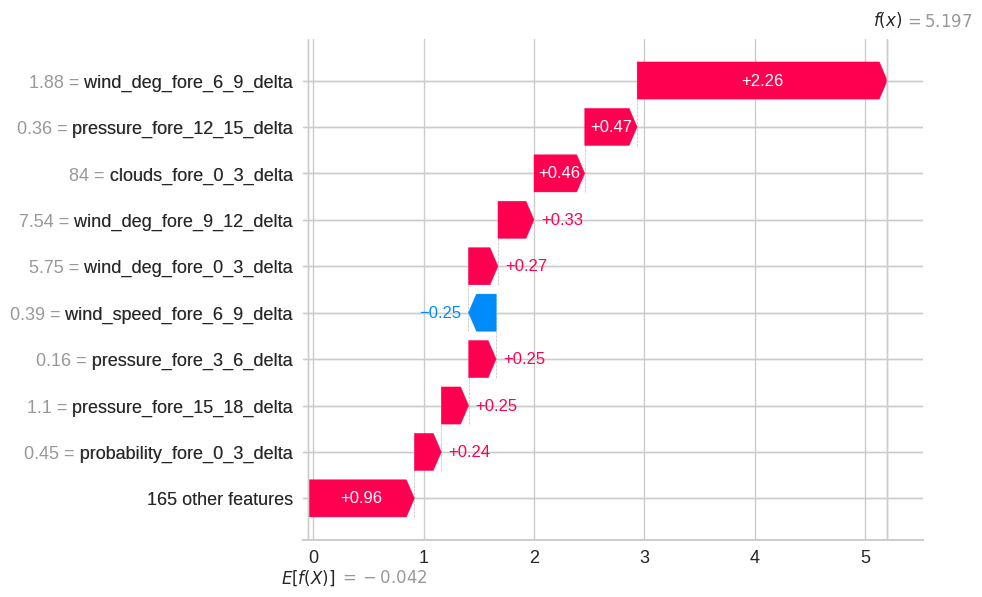

In [ ]:
import numpy as np
import shap

X = df_merged15_cut2.drop(columns=['chamado', 'counts'])

row = df_merged15_cut2[df_merged15_cut2['chamado'] == True].sample(n=1)
X = df_merged15_cut2.drop(row.index)

explainer = shap.TreeExplainer(best_models15[0], X)

# Calculate SHAP values for the random row
shap_values = explainer(row)

shap.plots.waterfall(shap_values[0])


In [ ]:
import joblib

joblib.dump(explainer, 'explainer_object.joblib')

['explainer_object.joblib']

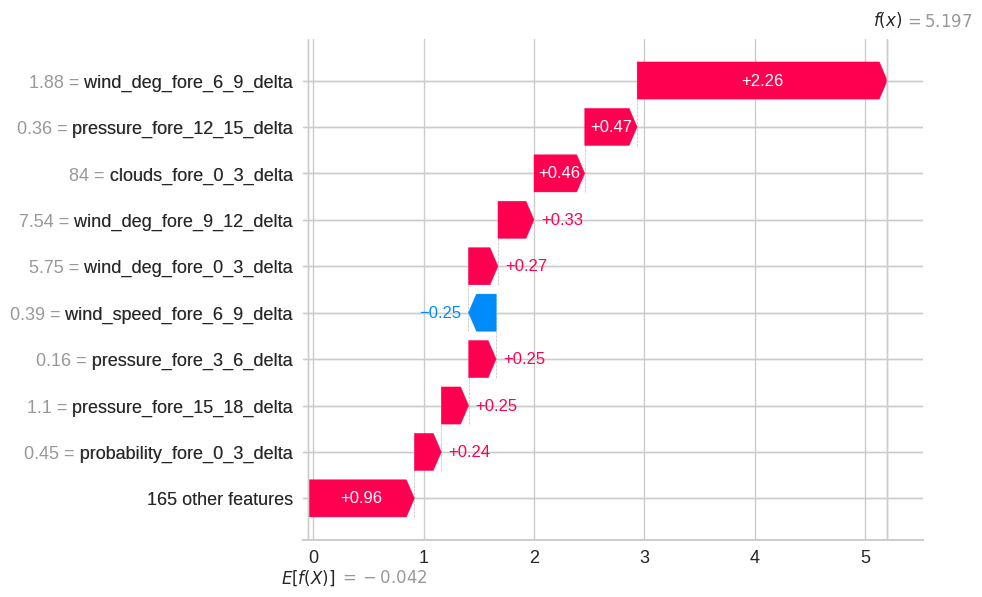

In [ ]:
explainer2 = joblib.load('explainer_object.joblib')
shap_values = explainer2(row)

shap.plots.waterfall(shap_values[0])


In [ ]:
np.argmax(np.abs(shap_values.values))

128

In [ ]:
test_data.counts.describe()

,counts
count,283.000000
mean,1.431095
std,5.169951
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,52.000000


In [ ]:
test_data.shape

(283, 174)

In [ ]:
evaluate_by_counts(best_models15[1:2], test_data, n_counts=0)
evaluate_by_counts(best_models15[1:2], test_data, n_counts=1.4)
evaluate_by_counts(best_models15[1:2], test_data, n_counts=6)
evaluate_by_counts(best_models15[1:2], test_data, n_counts=15)



Filtrando por counts com corte em 0. Shape resultante: (67, 174)



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.6567,0,0.6567,1.0000,0.7928,0.0000,0.0000




Filtrando por counts com corte em 1.4. Shape resultante: (43, 174)



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.6977,0,0.6977,1.0000,0.8219,0.0000,0.0000




Filtrando por counts com corte em 6. Shape resultante: (18, 174)



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.6667,0,0.6667,1.0000,0.8000,0.0000,0.0000




Filtrando por counts com corte em 15. Shape resultante: (5, 174)



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.8000,0,0.8000,1.0000,0.8889,0.0000,0.0000


In [ ]:
test_data.rain_fore_0_24_sum.quantile(0.95)

18.301

In [ ]:
evaluate_by_counts(best_models15[1:2], test_data, count_type="rain_fore_0_24_sum", n_counts=2)
evaluate_by_counts(best_models15[1:2], test_data, count_type="rain_fore_0_24_sum", n_counts=5)
evaluate_by_counts(best_models15[1:2], test_data, count_type="rain_fore_0_24_sum", n_counts=15)
evaluate_by_counts(best_models15[1:2], test_data, count_type="rain_fore_0_24_sum", n_counts=20)



Filtrando por rain_fore_0_24_sum com corte em 2. Shape resultante: (140, 174)



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.6214,0.6387,0.6667,0.4179,0.5138,0.2297,0.2465




Filtrando por rain_fore_0_24_sum com corte em 5. Shape resultante: (87, 174)



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.6092,0.5737,0.5667,0.4474,0.5000,0.1865,0.1900




Filtrando por rain_fore_0_24_sum com corte em 15. Shape resultante: (31, 174)



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.6452,0.5833,0.5833,0.5385,0.5600,0.2635,0.2641




Filtrando por rain_fore_0_24_sum com corte em 20. Shape resultante: (12, 174)



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.6667,0.6389,0.6667,0.6667,0.6667,0.3333,0.3333


In [ ]:
test_data.rain_sum_total.describe()

,rain_sum_total
count,278.000000
mean,392.672450
std,199.655053
min,79.611000
25%,236.265000
50%,368.104500
75%,515.402500
max,1130.830000


In [ ]:
# prompt: save the best model (var best_models15) using joblib

import joblib

# Assuming best_models15[0] is the model you want to save
joblib.dump(best_models15[0], 'lgbm_sa_2.joblib')

['lgbm_sa_2.joblib']

In [ ]:
# prompt: now use this new joblib file to load the model and input a random line from df_merged15_cut2 and then calculate the proba for it

import pandas as pd
import numpy as np
import joblib

# Load the model
loaded_model = joblib.load('lgbm_sa_1.joblib')

# Assuming df_merged15_cut2 is your DataFrame
# Select a random row from df_merged15_cut2
random_row = df_merged15_cut2.sample(n=1)

# Prepare the input data (excluding the 'chamado' column)
input_data = random_row.drop(columns=['chamado']).values

# Get the probability predictions
proba = loaded_model.predict_proba(input_data)

print("Probability Predictions:\n", proba)

Prediction: [False]


In [ ]:
df_merged15_cut2.columns

Index(['temperature_fore_0_24_mean', 'pressure_fore_0_24_mean',
       'humidity_fore_0_24_mean', 'clouds_fore_0_24_mean',
       'wind_speed_fore_0_24_mean', 'wind_deg_fore_0_24_mean',
       'rain_fore_0_24_mean', 'probability_fore_0_24_mean', 'chamado'],
      dtype='object')

# Modelo tamanduatei

In [ ]:
df_openwf16_filled = fill_missing(df_openwf, df_openwf.columns)

In [ ]:
agg_config = {
 'temperature_fore': (3, ("mean", "delta", "median")),
 'pressure_fore': (3, ("mean", "delta", "median")),
 'humidity_fore': (3, ("mean", "delta", "median")),
 'clouds_fore': (3, ("mean", "delta", "median")),
 'wind_speed_fore': (3, ("mean", "delta", "median")),
 'wind_deg_fore': (3, ("mean", "delta", "median")),
 'rain_fore': (3, ("mean", "delta", "median")),
 'probability_fore': (3, ("mean", "delta", "median"))
}

In [ ]:
df_openwf16_agg = df_openwf16_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()

In [ ]:
df_merged16 = df_openwf16_agg.copy()
df_merged16["chamado"] = df_merged16["dt"].isin(df_chamados_tamanduatei_unique["dt"])
df_merged16_seasonal = df_merged16[~df_merged16['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])

In [ ]:
df_merged16_cut1 = iterative_lower_fence_cuts(df_merged16_seasonal, true_cut_max=0)

Applying cut on feature 'humidity_fore_0_3_mean' with threshold 51.927500000000016, removing 25 false cases and 0 true cases
Applying cut on feature 'temperature_fore_3_6_median' with threshold 13.470000000000002, removing 12 false cases and 0 true cases
Applying cut on feature 'humidity_fore_21_24_mean' with threshold 40.46166666666668, removing 9 false cases and 0 true cases
Applying cut on feature 'pressure_fore_3_6_mean' with threshold 1006.0333333333335, removing 9 false cases and 0 true cases
Applying cut on feature 'humidity_fore_6_9_median' with threshold 61.33499999999999, removing 8 false cases and 0 true cases
Applying cut on feature 'temperature_fore_15_18_median' with threshold 16.999999999999993, removing 8 false cases and 0 true cases
Applying cut on feature 'temperature_fore_6_9_median' with threshold 13.065, removing 4 false cases and 0 true cases
Applying cut on feature 'humidity_fore_0_3_median' with threshold 54.18, removing 4 false cases and 0 true cases
Applying c

In [ ]:
df_merged16_cut2 = iterative_lower_fence_cuts(df_merged16_seasonal, min=True)

Applying cut on feature 'clouds_fore_6_9_mean' with threshold 0.0, removing 33 false cases and 0 true cases
Applying cut on feature 'pressure_fore_6_9_delta' with threshold 0.029999999999972715, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_9_12_delta' with threshold 0.0, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_9_12_delta' with threshold 0.009999999999999787, removing 2 false cases and 0 true cases
Applying cut on feature 'pressure_fore_21_24_delta' with threshold 0.17000000000007276, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_3_6_delta' with threshold 0.0, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_18_21_mean' with threshold 0.27666666666666667, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_12_15_median' with threshold 0.0, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_fo

In [ ]:
best_models16 = train_and_evaluate_model(df_merged16_cut2,
                         "chamado",
                         test_size=0.15,
                         sampling_strategy=0.75)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(252, 193)"
4,Transformed data shape,"(252, 193)"
5,Transformed train set shape,"(176, 193)"
6,Transformed test set shape,"(76, 193)"
7,Numeric features,192
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7954,0.8656,0.7161,0.8007,0.7454,0.5748,0.5873,0.5330
xgboost,Extreme Gradient Boosting,0.7905,0.8443,0.6946,0.8268,0.7373,0.5662,0.5865,0.5710
lightgbm,Light Gradient Boosting Machine,0.7905,0.8543,0.6804,0.8189,0.7280,0.5619,0.5782,0.5740
ada,Ada Boost Classifier,0.7676,0.8182,0.6554,0.7994,0.7144,0.5194,0.5328,0.3210
gbc,Gradient Boosting Classifier,0.7676,0.8347,0.6393,0.8139,0.6951,0.5128,0.5386,0.8970
et,Extra Trees Classifier,0.7614,0.8562,0.6232,0.8029,0.6750,0.4953,0.5225,0.4200
dt,Decision Tree Classifier,0.6886,0.6769,0.5911,0.6480,0.6082,0.3543,0.3618,0.0860
lr,Logistic Regression,0.6588,0.6941,0.6125,0.6108,0.6054,0.3049,0.3097,1.1300
ridge,Ridge Classifier,0.6333,0.6246,0.5429,0.5680,0.5431,0.2426,0.2504,0.0640
nb,Naive Bayes,0.6261,0.7118,0.3357,0.6200,0.3958,0.1853,0.2111,0.0620


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.5096,0.5056,0.4737,0.1800,0.2609,-0.0053,-0.0067


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.5288,0.5214,0.5263,0.2000,0.2899,0.0341,0.0431


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.4135,0.4594,0.4737,0.1500,0.2278,-0.0687,-0.0988


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.4519,0.4322,0.4737,0.1607,0.2400,-0.0451,-0.0614


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.4808,0.4762,0.4211,0.1569,0.2286,-0.0513,-0.0656


In [ ]:
# prompt: save the best model (var best_models15) using joblib

import joblib

# Assuming best_models15[0] is the model you want to save
joblib.dump(best_models16[2], 'lgbm_tam_2.joblib')

['lgbm_tam_2.joblib']

<a name="sec15"></a>
# Modelos bacias

Este desenvolvimento teve como objetivo a criação de modelos específicos para as seguintes bacias hidrográficas:

1. Meninos
2. Oratório
3. Tamanduateí Central
4. Sub-bacia do Guarará

Considerando que o dataset de chamados não faz distinção da bacia ao qual pertence determinado endereço, foi necessário utilizar o nome do bairro e verificar se este faz parte da bacia de interesse. Tendo sido feita esta indicação, resta modificar o dataset de modo que restem apenas os chamados relativos à bacia do modelo em questão. A saber, os bairros considerados para cada bacia:

```python
meninos = ["Vila Palmares", "Vila Sacadura Cabral", "Vila Aquilino",
"Vila Príncipe de Gales", "Vila Guiomar", "Vila Valparaíso", "Vila Floresta",
"Jardim Bom Pastor", "Vila Scarpelli", "Pinheirinho", "Jardim Stella",
"Jardim Jamaica", "Jardim Cristiane", "Jardim Las Vegas", "Jardim Alvorada"]

oratorio = ["Vila Metalúrgica", "Vila Camilópolis", "Jardim Utinga",
"Jardim das Maravilhas", "Vila Lucinda", "Parque Oratório",
"Parque Erasmo Assunção", "Parque Novo Oratório", "Jardim Rina",
"Parque Capuava", "Jardim Santo Alberto", "Jardim Itapoan", "Jardim Ana Maria",
"Pólo Petroquímico de Capuava"]

tamanduatei_central = ["Campestre", "Santa Maria", "Jardim", "Vila Alpina",
"Vila Guiomar", "Vila Alice", "Vila Bastos", "Jardim Bela Vista", "Centro",
"Casa Branca", "Vila Gilda", "Paraíso", "Vila Assunção", "Vila Alzira",
"Silveira", "Vila Linda", "Vila Helena", "Jardim do Estádio",
"Jardim Santa Cristina", "Jardim Guarará", "Sítio dos Vianas",
"Jardim Cipreste", "Jardim Irene", "Vila João Ramalho", "Jardim Vila Rica",
"Cata Preta", "Jardim Santo André CDHU", "Jardim Santo André CDHU",
"Vila Luzita", "Jardim Telles de Menezes", "Vila Suiça", "Condomínio Maracanã",
"Vila Lutécia", "Vila Tibiriça", "Vila Vitória", "Jardim Ipanema",
"Vila Guaraciaba", "Vila Progresso", "Parque Gerassi", "Cidade São Jorge",
"Centreville", "Vila Guarani", "Vila Humaitá", "Parque Marajoara",
"Vila Homero Thon", "Vila América", "Vila Pires", "Silveira", "Vila Alzira",
"Novo Homero Thon", "Várzea do Tamanduateí", "Jardim Alzira Franco",
"Parque Jaçatuba", "Vila Curuça", "Bangú", "Parque das Nações",
"Santa Terezinha", "Vila Francisco Matarazzo", "Jardim Santo Antônio",
"Vila Camilópolis", "Vila Metalúrgica"]

guarara = ["Cata Preta", "Vila João Ramalho", "Jardim Vila Rica",
"Jardim Santo André CDHU", "Jardim Santo André", "Jardim Irene",
"Sítio dos Vianas", "Jardim Guarará", "Vila Luzita", "Vila Suiça",
"Jardim Santa Cristina", "Jardim Telles de Menezes", "Vila Lutécia",
"Jardim do Estádio", "Vila Junqueira", "Vila Vitória", "Vila Tibiriça",
"Jardim Ipanema", "Vila Helena", "Vila Progresso", "Vila Pires", "Vila Humaitá",
"Silveira", "Vila América", "Vila Homero Thon", "Casa Branca",
"Várzea do Tamanduateí", "Novo Homero Thon"]
```

Os resultados obtidos para os modelos específicos de cada bacia não foram bons. Segue os quadros resultantes para cada um dos modelos. Como já estabelecemos anteriormente, os resultados do conjunto de treinamento estão consistentemente performando bem, restando apenas os resultados do conjunto de validação como um indício real da performance dos modelos. Tendo isso em vista, serão apresentados apenas os resultados para o conjunto de validação.

**Meninos**

![](https://drive.google.com/uc?export=view&id=15biNdquoUE4KnBRr3dpqfsSrwMMxvDPb)

**Oratório**

![](https://drive.google.com/uc?export=view&id=13B4SHNFbkrN1fEDGWOVGT8Ro7QKvMaD0)

**Tamanduateí Central**

![](https://drive.google.com/uc?export=view&id=1juCR5oEXzg_zJuhe5RJ3pg7Drf-CKa7e)

**Guarará**

![](https://drive.google.com/uc?export=view&id=1E-9Rfszh6rts0boUO2cPLGWrBKxiEc4I)

Seguindo a mesma linha dos resultados com o modelo municipal, é possível observar um *recall* alto e uma precisão baixa. No entanto, a precisão dos modelos por bacia é consideravelmente mais baixa do que a que vemos no modelo de Santo André. O motivo disso é o recorte do dataset de chamados.

A tabela abaixo exibe, para cada uma das bacias, o número de dias com chamado restante - após filtrar por seus bairros e pelos meses que nos são de interesse (ver [seção de influência da sazonalidade](#sec7)) - e a precisão do melhor modelo obtido. Percebe-se que há uma correlação clara entre a quantidade de chamados restante e a precisão obtida no modelo por bacia.

|    Bacia    | # de chamados | Precisão |
|:-----------:|:-------------:|:--------:|
|   Meninos   |       76      |  0.0741  |
|   Oratório  |       47      |  0.0323  |
| Tamanduateí |      186      |  0.1983  |
|   Guarará   |      123      |  0.1250  |

O problema da quantidade de chamados também era fortemente sentido mesmo nos modelos municipais, cujo melhor modelo até agora não passou de 0.40 de precisão. É natural que os modelos que restringem ainda mais esse recurso tenham resultados piores.

É sabido que modelos de machine learning escalam sua performance proporcionalmente à quantidade de dados disponíveis. Tendo isso em consideração, o caminho em frente para o projeto envolve o acúmulo de massa crítica de dados, mas também envolve a utilização de técnicas para tentar mitigar a ausência de dados. Destaca-se:

1. Manipular o dataset de chamados e, em conjunto com os dados de precipitação, inferir o momento do dia em que ocorrem os chamados. Isso pode aumentar artificialmente o volume de dados úteis.
2. Utilizar a saída do modelo municipal como uma entrada para os modelos das bacias. Essa técnica não só serve para aprimorar os resultados vistos nos modelos das bacias como também serve para criar coesão entre os resultados municipais e regionais.

Ainda é possível e provável que a análise considerando o volume total de dados de validação forneça uma métrica inadequada, uma vez que os modelos foram treinados apenas para alguns meses do ano. Deve-se considerar também a possibilidade de o resultado obtido ser considerávelmente mais assertivo para eventos extremos, o que podemos verificar pelo nível de precipitação acumulada e quantidade de chamados em um determinado dia. Sendo assim, torna-se um dos objetivos do próximo relatório trazer essas análises.

In [ ]:
def prepare_basin_df(basin_list):
  df_chamados_neigh = df_chamados.copy()
  df_chamados_neigh['bairro'] = df_chamados_neigh['end'].str.extract(r'-\s*([A-Z\s]+)$')
  df_chamados_basin = df_chamados_neigh[df_chamados_neigh['bairro'].isin(basin_list)].drop(columns=['bairro', 'end'])
  return df_chamados_basin.copy()

In [ ]:
df_openw17_filled = fill_missing(df_openw, df_openw.columns)
df_openw17_shifted = shift_column_up(df_openw17_filled, ["dt"], 24)

In [ ]:
agg_config = {
 'temp': (24, ('mean',)),
 'visibility': (24, ('mean',)),
 'dew_point': (12, ('delta')),
 'feels_like': (24, ('max', 'min')),
 'temp_min': (12, ("delta")),
 'temp_max': (12, ("delta")),
 'pressure': (24, ('mean',)),
 'humidity': (24, ('mean',)),
 'wind_speed': (24, ('mean',)),
 'wind_deg': (24, ('mean',)),
 'wind_gust': (24, ('mean',)),
 'rain_1h': (24, ('sum',)),
 'clouds_all': (24, ('mean',)),
}

In [ ]:
df_openw17_agg = df_openw17_shifted.groupby(pd.Grouper(key='dt', freq='D')) \
    .agg(**create_agg_dict(agg_config)).reset_index()

KeyboardInterrupt: 

In [ ]:
df_openwf17_filled = fill_missing(df_openwf, df_openwf.columns)

In [ ]:
agg_config = {
 'temperature_fore': (3, ("mean", "delta", "median")),
 'pressure_fore': (3, ("mean", "delta", "median")),
 'humidity_fore': (3, ("mean", "delta", "median")),
 'clouds_fore': (3, ("mean", "delta", "median")),
 'wind_speed_fore': (3, ("mean", "delta", "median")),
 'wind_deg_fore': (3, ("mean", "delta", "median")),
 'rain_fore': (3, ("mean", "delta", "median")),
 'probability_fore': (3, ("mean", "delta", "median"))
}

In [ ]:
df_openwf17_agg = df_openwf17_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()

In [ ]:
df_premerge17 = df_openwf17_agg

Bacia dos meninos

In [ ]:
meninos = ["Vila Palmares", "Vila Sacadura Cabral", "Vila Aquilino",
"Vila Príncipe de Gales", "Vila Guiomar", "Vila Valparaíso", "Vila Floresta",
"Jardim Bom Pastor", "Vila Scarpelli", "Pinheirinho", "Jardim Stella",
"Jardim Jamaica", "Jardim Cristiane", "Jardim Las Vegas", "Jardim Alvorada"]

meninos_renamed = rename_neighborhood_list(meninos)

In [ ]:
df_chamados_meninos = prepare_basin_df(meninos_renamed)
df_chamados_meninos_unique = df_chamados_meninos.drop_duplicates(subset=['dt']).reset_index(drop=True)

In [ ]:
df_meninos = df_premerge17.copy()
df_meninos["chamado"] = df_meninos["dt"].isin(df_chamados_meninos_unique["dt"])
df_meninos_seasonal = df_meninos[~df_meninos['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])
df_meninos_seasonal[df_meninos_seasonal["chamado"] == True].shape, df_meninos_seasonal[df_meninos_seasonal["chamado"] == False].shape

((76, 193), (1152, 193))

In [ ]:
df_meninos_cut1 = iterative_lower_fence_cuts(df_meninos_seasonal, true_cut_max=0)

Applying cut on feature 'humidity_fore_0_3_mean' with threshold 51.927500000000016, removing 25 false cases and 0 true cases
Applying cut on feature 'temperature_fore_3_6_median' with threshold 13.470000000000002, removing 12 false cases and 0 true cases
Applying cut on feature 'humidity_fore_21_24_mean' with threshold 40.46166666666668, removing 9 false cases and 0 true cases
Applying cut on feature 'pressure_fore_3_6_mean' with threshold 1006.0333333333335, removing 9 false cases and 0 true cases
Applying cut on feature 'humidity_fore_6_9_median' with threshold 61.33499999999999, removing 8 false cases and 0 true cases
Applying cut on feature 'temperature_fore_15_18_median' with threshold 16.999999999999993, removing 8 false cases and 0 true cases
Applying cut on feature 'temperature_fore_6_9_median' with threshold 13.065, removing 4 false cases and 0 true cases
Applying cut on feature 'humidity_fore_0_3_median' with threshold 54.18, removing 4 false cases and 0 true cases
Applying c

In [ ]:
best_models_meninos = train_and_evaluate_model(df_meninos_cut1,
                         "chamado",
                         test_size=0.15,
                         sampling_strategy=0.75)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(151, 193)"
4,Transformed data shape,"(151, 193)"
5,Transformed train set shape,"(105, 193)"
6,Transformed test set shape,"(46, 193)"
7,Numeric features,192
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9409,0.9646,0.9000,0.9583,0.9183,0.8731,0.8831,0.2230
rf,Random Forest Classifier,0.9036,0.9508,0.8600,0.9017,0.8779,0.7980,0.8008,0.4340
xgboost,Extreme Gradient Boosting,0.8864,0.9425,0.8450,0.8850,0.8562,0.7643,0.7731,0.4890
lightgbm,Light Gradient Boosting Machine,0.8855,0.9342,0.8650,0.8800,0.8640,0.7658,0.7769,0.4230
gbc,Gradient Boosting Classifier,0.8845,0.9492,0.8650,0.8767,0.8646,0.7645,0.7730,0.5460
ada,Ada Boost Classifier,0.8455,0.9250,0.7950,0.8483,0.8150,0.6826,0.6911,0.2610
dt,Decision Tree Classifier,0.8345,0.8325,0.8150,0.8250,0.8031,0.6632,0.6806,0.0720
nb,Naive Bayes,0.8018,0.9033,0.7050,0.8350,0.7270,0.5867,0.6165,0.0560
lr,Logistic Regression,0.7373,0.7367,0.6050,0.7583,0.6589,0.4497,0.4663,1.3390
ridge,Ridge Classifier,0.6855,0.6908,0.6050,0.6600,0.6239,0.3570,0.3645,0.1050


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.2588,0.5941,0.9091,0.0741,0.1370,0.0197,0.0748


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.1706,0.5380,0.8182,0.0608,0.1132,-0.0082,-0.0411


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.2000,0.6501,0.9091,0.0690,0.1282,0.0090,0.0417


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.2412,0.5929,0.9091,0.0725,0.1342,0.0163,0.0655


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.3294,0.6232,0.8182,0.0744,0.1364,0.0201,0.0618


In [ ]:
# prompt: save the best model (var best_models15) using joblib

import joblib

joblib.dump(best_models_meninos[1], 'xgboost_meninos_1.joblib')

['xgboost_meninos_1.joblib']

Bacia oratório

In [ ]:
oratorio = ["Vila Metalúrgica", "Vila Camilópolis", "Jardim Utinga",
"Jardim das Maravilhas", "Vila Lucinda", "Parque Oratório",
"Parque Erasmo Assunção", "Parque Novo Oratório", "Jardim Rina",
"Parque Capuava", "Jardim Santo Alberto", "Jardim Itapoan", "Jardim Ana Maria",
"Pólo Petroquímico de Capuava"]

oratorio_renamed = rename_neighborhood_list(oratorio)

In [ ]:
df_chamados_oratorio = prepare_basin_df(oratorio_renamed)
df_chamados_oratorio_unique = df_chamados_oratorio.drop_duplicates(subset=['dt']).reset_index(drop=True)

In [ ]:
df_oratorio = df_premerge17.copy()
df_oratorio["chamado"] = df_oratorio["dt"].isin(df_chamados_oratorio_unique["dt"])
df_oratorio_seasonal = df_oratorio[~df_oratorio['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])
df_oratorio_seasonal[df_oratorio_seasonal["chamado"] == True].shape, df_oratorio_seasonal[df_oratorio_seasonal["chamado"] == False].shape

((47, 193), (1181, 193))

In [ ]:
df_oratorio_cut1 = iterative_lower_fence_cuts(df_oratorio_seasonal, true_cut_max=0)

Applying cut on feature 'humidity_fore_0_3_mean' with threshold 51.927500000000016, removing 25 false cases and 0 true cases
Applying cut on feature 'temperature_fore_3_6_median' with threshold 13.470000000000002, removing 12 false cases and 0 true cases
Applying cut on feature 'pressure_fore_21_24_delta' with threshold 0.35249999999987836, removing 9 false cases and 0 true cases
Applying cut on feature 'humidity_fore_21_24_median' with threshold 41.16499999999997, removing 10 false cases and 0 true cases
Applying cut on feature 'pressure_fore_3_6_mean' with threshold 1006.0308333333335, removing 9 false cases and 0 true cases
Applying cut on feature 'temperature_fore_15_18_median' with threshold 17.1125, removing 9 false cases and 0 true cases
Applying cut on feature 'humidity_fore_6_9_median' with threshold 61.29999999999998, removing 7 false cases and 0 true cases
Applying cut on feature 'humidity_fore_0_3_mean' with threshold 54.468333333333334, removing 4 false cases and 0 true ca

In [ ]:
best_oratorio = train_and_evaluate_model(df_oratorio_cut1,
                         "chamado",
                         test_size=0.15,
                         sampling_strategy=0.75)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(93, 193)"
4,Transformed data shape,"(93, 193)"
5,Transformed train set shape,"(65, 193)"
6,Transformed test set shape,"(28, 193)"
7,Numeric features,192
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8738,0.9194,0.7833,0.9417,0.8224,0.7322,0.7682,0.1690
rf,Random Forest Classifier,0.8619,0.9500,0.7667,0.9000,0.7881,0.6935,0.7282,0.3870
ada,Ada Boost Classifier,0.8167,0.9000,0.6833,0.8917,0.7324,0.6104,0.6537,0.2760
nb,Naive Bayes,0.8000,0.8778,0.8167,0.7017,0.7440,0.5892,0.6028,0.0520
lightgbm,Light Gradient Boosting Machine,0.8000,0.8833,0.6333,0.7833,0.6800,0.5602,0.5811,0.6800
xgboost,Extreme Gradient Boosting,0.7833,0.8264,0.6333,0.8500,0.6938,0.5302,0.5624,0.3060
gbc,Gradient Boosting Classifier,0.7238,0.8750,0.5667,0.6433,0.5850,0.3994,0.4164,0.3690
dt,Decision Tree Classifier,0.6786,0.6417,0.4333,0.7000,0.5233,0.3043,0.3356,0.0520
ridge,Ridge Classifier,0.6524,0.6736,0.3833,0.6333,0.4600,0.2585,0.2885,0.0900
qda,Quadratic Discriminant Analysis,0.6143,0.6056,0.4667,0.6233,0.5038,0.1894,0.1936,0.1030


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.2679,0.3571,0.5714,0.0323,0.0611,-0.0193,-0.0790


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.1310,0.3429,0.8571,0.0397,0.0759,-0.0040,-0.0288


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.2619,0.4002,0.7143,0.0394,0.0746,-0.0047,-0.0202


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Naive Bayes,0.2500,0.4343,0.7143,0.0388,0.0735,-0.0060,-0.0265


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.2143,0.4295,1.0000,0.0504,0.0959,0.0180,0.0952


In [ ]:
# prompt: save the best model (var best_models15) using joblib

import joblib

joblib.dump(best_oratorio[2], 'ada_oratorio_1.joblib')

['ada_oratorio_1.joblib']

Bacia tamanduatei central

In [ ]:
tamanduatei_central = ["Campestre", "Santa Maria", "Jardim", "Vila Alpina",
"Vila Guiomar", "Vila Alice", "Vila Bastos", "Jardim Bela Vista", "Centro",
"Casa Branca", "Vila Gilda", "Paraíso", "Vila Assunção", "Vila Alzira",
"Silveira", "Vila Linda", "Vila Helena", "Jardim do Estádio",
"Jardim Santa Cristina", "Jardim Guarará", "Sítio dos Vianas",
"Jardim Cipreste", "Jardim Irene", "Vila João Ramalho", "Jardim Vila Rica",
"Cata Preta", "Jardim Santo André CDHU", "Jardim Santo André CDHU",
"Vila Luzita", "Jardim Telles de Menezes", "Vila Suiça", "Condomínio Maracanã",
"Vila Lutécia", "Vila Tibiriça", "Vila Vitória", "Jardim Ipanema",
"Vila Guaraciaba", "Vila Progresso", "Parque Gerassi", "Cidade São Jorge",
"Centreville", "Vila Guarani", "Vila Humaitá", "Parque Marajoara",
"Vila Homero Thon", "Vila América", "Vila Pires", "Silveira", "Vila Alzira",
"Novo Homero Thon", "Várzea do Tamanduateí", "Jardim Alzira Franco",
"Parque Jaçatuba", "Vila Curuça", "Bangú", "Parque das Nações",
"Santa Terezinha", "Vila Francisco Matarazzo", "Jardim Santo Antônio",
"Vila Camilópolis", "Vila Metalúrgica"]

tamanduatei_central_renamed = rename_neighborhood_list(tamanduatei_central)

In [ ]:
df_chamados_tamanduatei_central = prepare_basin_df(tamanduatei_central_renamed)
df_chamados_tamanduatei_central_unique = df_chamados_tamanduatei_central.drop_duplicates(subset=['dt']).reset_index(drop=True)

In [ ]:
df_tam_central = df_premerge17.copy()
df_tam_central["chamado"] = df_tam_central["dt"].isin(df_chamados_tamanduatei_central_unique["dt"])
df_tam_central_seasonal = df_tam_central[~df_tam_central['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])
df_tam_central_seasonal[df_tam_central_seasonal["chamado"] == True].shape, df_tam_central_seasonal[df_tam_central_seasonal["chamado"] == False].shape

((186, 193), (1042, 193))

In [ ]:
df_tam_central_cut1 = iterative_lower_fence_cuts(df_tam_central_seasonal, true_cut_max=0)

Applying cut on feature 'humidity_fore_0_3_mean' with threshold 51.927500000000016, removing 25 false cases and 0 true cases
Applying cut on feature 'temperature_fore_3_6_median' with threshold 13.470000000000002, removing 12 false cases and 0 true cases
Applying cut on feature 'pressure_fore_3_6_mean' with threshold 1006.0258333333335, removing 9 false cases and 0 true cases
Applying cut on feature 'temperature_fore_15_18_median' with threshold 17.06125, removing 9 false cases and 0 true cases
Applying cut on feature 'humidity_fore_6_9_median' with threshold 60.99000000000001, removing 8 false cases and 0 true cases
Applying cut on feature 'humidity_fore_9_12_mean' with threshold 54.26833333333334, removing 4 false cases and 0 true cases
Applying cut on feature 'temperature_fore_6_9_median' with threshold 13.065, removing 4 false cases and 0 true cases
Applying cut on feature 'pressure_fore_18_21_mean' with threshold 1004.06, removing 3 false cases and 0 true cases
Applying cut on fea

In [ ]:
best_model_tam_central = train_and_evaluate_model(df_tam_central_cut1,
                         "chamado",
                         test_size=0.15,
                         sampling_strategy=0.75)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(368, 193)"
4,Transformed data shape,"(368, 193)"
5,Transformed train set shape,"(257, 193)"
6,Transformed test set shape,"(111, 193)"
7,Numeric features,192
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7515,0.8339,0.6545,0.7443,0.6856,0.4834,0.4956,0.9110
xgboost,Extreme Gradient Boosting,0.7238,0.8287,0.6091,0.7104,0.6501,0.4249,0.4326,1.1700
gbc,Gradient Boosting Classifier,0.7122,0.7887,0.5909,0.6966,0.6265,0.3981,0.4095,2.1790
ada,Ada Boost Classifier,0.7091,0.7552,0.6364,0.6891,0.6441,0.4011,0.4174,0.5700
rf,Random Forest Classifier,0.6811,0.8052,0.5545,0.6528,0.5894,0.3342,0.3431,0.4970
et,Extra Trees Classifier,0.6652,0.7658,0.4364,0.6831,0.5167,0.2847,0.3080,0.2210
dt,Decision Tree Classifier,0.6303,0.6281,0.6091,0.5711,0.5838,0.2540,0.2588,0.0890
ridge,Ridge Classifier,0.6160,0.6092,0.5000,0.5726,0.5234,0.2077,0.2125,0.0600
lr,Logistic Regression,0.6071,0.6457,0.5182,0.5436,0.5212,0.1922,0.1941,1.3100
nb,Naive Bayes,0.6066,0.6216,0.3909,0.5692,0.4522,0.1648,0.1772,0.0540


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.4094,0.5807,0.8571,0.1983,0.3221,0.0766,0.1455


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4327,0.5614,0.8214,0.2000,0.3217,0.0792,0.1404


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.3918,0.5157,0.6429,0.1607,0.2571,-0.0066,-0.0113


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.4561,0.6106,0.7500,0.1963,0.3111,0.0696,0.1136


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.4094,0.5353,0.7143,0.1770,0.2837,0.0288,0.0500


In [ ]:
import joblib

joblib.dump(best_model_tam_central[0], 'gbc_tamc_1.joblib')

['gbc_tamc_1.joblib']

Sub-bacia guarara

In [ ]:
guarara = ["Cata Preta", "Vila João Ramalho", "Jardim Vila Rica",
"Jardim Santo André CDHU", "Jardim Santo André", "Jardim Irene",
"Sítio dos Vianas", "Jardim Guarará", "Vila Luzita", "Vila Suiça",
"Jardim Santa Cristina", "Jardim Telles de Menezes", "Vila Lutécia",
"Jardim do Estádio", "Vila Junqueira", "Vila Vitória", "Vila Tibiriça",
"Jardim Ipanema", "Vila Helena", "Vila Progresso", "Vila Pires", "Vila Humaitá",
"Silveira", "Vila América", "Vila Homero Thon", "Casa Branca",
"Várzea do Tamanduateí", "Novo Homero Thon"]

guarara_renamed = rename_neighborhood_list(guarara)

In [ ]:
df_chamados_guarara = prepare_basin_df(guarara_renamed)
df_chamados_guarara_unique = df_chamados_guarara.drop_duplicates(subset=['dt']).reset_index(drop=True)

In [ ]:
df_guarara = df_premerge17.copy()
df_guarara["chamado"] = df_guarara["dt"].isin(df_chamados_guarara_unique["dt"])
df_guarara_seasonal = df_guarara[~df_guarara['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])
df_guarara_seasonal[df_guarara_seasonal["chamado"] == True].shape, df_guarara_seasonal[df_guarara_seasonal["chamado"] == False].shape

((123, 193), (1105, 193))

In [ ]:
df_guarara_cut1 = iterative_lower_fence_cuts(df_guarara_seasonal, true_cut_max=0)

Applying cut on feature 'humidity_fore_0_3_mean' with threshold 51.927500000000016, removing 25 false cases and 0 true cases
Applying cut on feature 'temperature_fore_3_6_median' with threshold 13.470000000000002, removing 12 false cases and 0 true cases
Applying cut on feature 'pressure_fore_3_6_mean' with threshold 1006.0258333333335, removing 9 false cases and 0 true cases
Applying cut on feature 'temperature_fore_15_18_median' with threshold 17.06125, removing 9 false cases and 0 true cases
Applying cut on feature 'humidity_fore_6_9_median' with threshold 60.99000000000001, removing 8 false cases and 0 true cases
Applying cut on feature 'humidity_fore_9_12_mean' with threshold 54.26833333333334, removing 4 false cases and 0 true cases
Applying cut on feature 'temperature_fore_6_9_median' with threshold 13.065, removing 4 false cases and 0 true cases
Applying cut on feature 'pressure_fore_18_21_mean' with threshold 1004.06, removing 3 false cases and 0 true cases
Applying cut on fea

In [ ]:
best_model_guarara = train_and_evaluate_model(df_guarara_cut1,
                         "chamado",
                         test_size=0.15,
                         sampling_strategy=0.75)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(242, 193)"
4,Transformed data shape,"(242, 193)"
5,Transformed train set shape,"(169, 193)"
6,Transformed test set shape,"(73, 193)"
7,Numeric features,192
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8287,0.9162,0.7929,0.8291,0.7977,0.6500,0.6639,0.2640
ada,Ada Boost Classifier,0.8107,0.8621,0.7554,0.8113,0.7745,0.6130,0.6226,0.4240
xgboost,Extreme Gradient Boosting,0.7985,0.8965,0.7232,0.7937,0.7515,0.5824,0.5896,0.7360
et,Extra Trees Classifier,0.7930,0.9107,0.6286,0.8625,0.7162,0.5621,0.5861,0.1880
lightgbm,Light Gradient Boosting Machine,0.7871,0.9057,0.7089,0.7868,0.7347,0.5575,0.5702,0.7450
gbc,Gradient Boosting Classifier,0.7812,0.8884,0.7250,0.7749,0.7399,0.5519,0.5621,1.0270
dt,Decision Tree Classifier,0.7342,0.7213,0.6071,0.7451,0.6614,0.4499,0.4617,0.0620
nb,Naive Bayes,0.6684,0.7287,0.4625,0.7179,0.5407,0.2979,0.3314,0.0530
lr,Logistic Regression,0.6272,0.6497,0.5214,0.5486,0.5205,0.2222,0.2278,0.3970
knn,K Neighbors Classifier,0.5688,0.4921,0.3911,0.5054,0.4238,0.0890,0.0961,0.0540


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.2924,0.5190,0.8947,0.1250,0.2194,0.0303,0.0871


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.3099,0.4965,0.7368,0.1102,0.1918,-0.0019,-0.0047


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.3333,0.6402,0.8947,0.1318,0.2297,0.0447,0.1153


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.3509,0.5428,0.7368,0.1167,0.2014,0.0119,0.0271


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.3041,0.6337,0.8947,0.1269,0.2222,0.0343,0.0954


In [ ]:
joblib.dump(best_model_guarara[1], 'xgb_guarara_1.joblib')

['xgb_guarara_1.joblib']

In [ ]:
df_openw['morning'] = 0  # Initialize columns to 0
df_openw['afternoon'] = 0
df_openw['evening'] = 0
df_openw['night'] = 0

for index, row in df_openw.iterrows():
    hour = row['dt'].hour
    rain = row['rain_1h']
    if 0 <= hour < 6:
        df_openw.loc[index, 'night'] = rain
    elif 6 <= hour < 12:
        df_openw.loc[index, 'morning'] = rain
    elif 12 <= hour < 18:
        df_openw.loc[index, 'afternoon'] = rain
    else:
        df_openw.loc[index, 'evening'] = rain

# Aggregate rain for each 6-hour period
df_openw = df_openw.groupby(pd.Grouper(key='dt', freq='D')).agg(
    morning=('morning', 'sum'),
    afternoon=('afternoon', 'sum'),
    evening=('evening', 'sum'),
    night=('night', 'sum')
).reset_index()


KeyboardInterrupt: 

<a name="sec16"></a>
# 16. Resultados para condições climáticas extremas

As análises que fizemos até então consideram todos os dados disponíveis do conjunto de validação. Esse recorte não é favorável aos modelos considerando que os modelos em produção só oferecem predição para quando há previsão de chuva no dia. Propõe-se, então, a hipótese de que se fizermos um recorte por dias com maior precipitação o resultado do modelo será melhor.

Para isso, será utilizado um modelo para toda a região metropolitana de Santo André considerando:

* As *features* disponíveis na API gratuita da Open Weather para *forecasts*;
* Agregados para soma, média, delta e mediana a cada 3 horas de cada um desses *features*;
* Conjunto de teste de 30% do total dos dados disponíveis;
* Ajuste por undersampling até ter uma proporção de 1 - 0.75.

Os resultados de base para o conjunto de teste podem ser vistos abaixo:

![](https://drive.google.com/uc?export=view&id=1CmYqf1uv2RjFYS6JujGlO2FrJfomnbrS)

Tratam-se dos resultados mais próximos dos modelos utilizados na versão do sistema em produção em Fevereiro de 2025 (quando o teste foi rodado inicialmente).

A seguir, vemos os resultados para quando restringimos o conjunto de teste para apenas casos com precipitação acima da mediana:

![](https://drive.google.com/uc?export=view&id=1gS1jPkWEG8jBGrpvbSpDLzJsFAMjq2Bl)

Para precipitação acima de 75% dos casos:

![](https://drive.google.com/uc?export=view&id=1YPGLTV6kL2nykg9z-SicgqJ-L-WDjiII)

Para precipitação acima de 95% dos casos:

![](https://drive.google.com/uc?export=view&id=14uuCFuuYgDxmhF61JaRr1s28PlZnEEv7)


Pode-se notar uma clara tendência de aumento da **precisão** quando consideramos casos cada vez mais extremos. Isso significa que, quando o dia apresenta uma precipitação anormal, o modelo apresenta menos erros de *falsos positivos*. Essa tendência é o suficiente para que essa validação passe a ser feita para todos os modelos subsequentes deste projeto.

In [ ]:
df_openwf16_filled = fill_missing(df_openwf, df_openwf.columns)

In [ ]:
agg_config = {
 'temperature_fore': (3, ("mean", "delta", "median")),
 'pressure_fore': (3, ("mean", "delta", "median")),
 'humidity_fore': (3, ("mean", "delta", "median")),
 'clouds_fore': (3, ("mean", "delta", "median")),
 'wind_speed_fore': (3, ("mean", "delta", "median")),
 'wind_deg_fore': (3, ("mean", "delta", "median")),
 'rain_fore': (3, ("sum", "mean", "delta", "median")),
 'probability_fore': (3, ("mean", "delta", "median"))
}

In [ ]:
df_openwf16_agg = df_openwf16_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()


In [ ]:
df_chamados_count = df_chamados.groupby('dt').size().reset_index(name='counts')

In [ ]:
# Merge the aggregated weather forecast data with the 'chamados' data
df_merged16 = df_openwf16_agg.copy()
df_merged16['chamado'] = df_merged16['dt'].isin(df_chamados_count['dt']).astype(int)

# Merge the counts into the main DataFrame
df_merged16 = pd.merge(df_merged16, df_chamados_count, on='dt', how='left')

# Fill NaN values in 'chamado_counts' with 0 (days with no chamados)
df_merged16['counts'].fillna(0, inplace=True)

In [ ]:
df_merged16_seasonal = df_merged16[~df_merged16['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])

In [ ]:
df_merged16_cut1 = iterative_lower_fence_cuts(df_merged16_seasonal, true_cut_max=0)

Applying cut on feature 'humidity_fore_0_3_mean' with threshold 51.927500000000016, removing 25 false cases and 0 true cases
Applying cut on feature 'temperature_fore_3_6_median' with threshold 13.470000000000002, removing 12 false cases and 0 true cases
Applying cut on feature 'humidity_fore_6_9_mean' with threshold 60.8566666666667, removing 8 false cases and 0 true cases
Applying cut on feature 'pressure_fore_18_21_mean' with threshold 1003.9400000000002, removing 6 false cases and 0 true cases
Applying cut on feature 'humidity_fore_9_12_mean' with threshold 53.94333333333333, removing 4 false cases and 0 true cases
Applying cut on feature 'humidity_fore_0_3_median' with threshold 54.215, removing 4 false cases and 0 true cases
Applying cut on feature 'temperature_fore_6_9_median' with threshold 13.019999999999996, removing 4 false cases and 0 true cases
Applying cut on feature 'temperature_fore_18_21_mean' with threshold 15.40666666666667, removing 3 false cases and 0 true cases
Ap

In [ ]:
df_merged16_cut2 = iterative_lower_fence_cuts(df_merged16_cut1, min=True)

Applying cut on feature 'wind_speed_fore_9_12_delta' with threshold 0.0, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_9_12_delta' with threshold 0.009999999999999787, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_9_12_delta' with threshold 0.010000000000000231, removing 2 false cases and 0 true cases
Applying cut on feature 'pressure_fore_6_9_delta' with threshold 0.029999999999972715, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_12_15_delta' with threshold 0.010000000000000009, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_6_9_delta' with threshold 0.06, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_6_9_delta' with threshold 0.0899999999999892, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_6_9_delta' with threshold 0.11999999999997613, removing 1 false cases and 0 true cases
Applyin

In [ ]:
best_models16, train_data, test_data = train_and_evaluate_model(df_merged16_cut2,
                         ["chamado", "counts"],
                         test_size=0.3,
                         sampling_strategy=0.75)

Não tem a coluna counts
Não tem a coluna chamado


,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(364, 201)"
4,Transformed data shape,"(400, 201)"
5,Transformed train set shape,"(290, 201)"
6,Transformed test set shape,"(110, 201)"
7,Numeric features,200
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7400,0.8235,0.6782,0.7313,0.6953,0.4692,0.4783,1.0930
gbc,Gradient Boosting Classifier,0.7083,0.7797,0.5873,0.7146,0.6349,0.3956,0.4092,1.4730
xgboost,Extreme Gradient Boosting,0.7038,0.7763,0.6145,0.6759,0.6390,0.3898,0.3955,0.8750
ada,Ada Boost Classifier,0.6806,0.6861,0.6245,0.6316,0.6206,0.3472,0.3535,0.5560
et,Extra Trees Classifier,0.6766,0.6822,0.5136,0.6724,0.5685,0.3201,0.3369,0.2590
rf,Random Forest Classifier,0.6729,0.7142,0.5782,0.6494,0.6007,0.3264,0.3373,0.3800
ridge,Ridge Classifier,0.6068,0.6721,0.5964,0.5403,0.5591,0.2060,0.2119,0.0790
nb,Naive Bayes,0.5903,0.5778,0.3109,0.5435,0.3822,0.1144,0.1288,0.1660
lr,Logistic Regression,0.5823,0.6087,0.5482,0.5082,0.5217,0.1516,0.1554,0.9140
dt,Decision Tree Classifier,0.5823,0.5834,0.5955,0.5330,0.5517,0.1668,0.1737,0.1220


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.5300,0.5654,0.5672,0.2676,0.3636,0.0618,0.0728


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.5371,0.6082,0.6418,0.2867,0.3963,0.1026,0.1247


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4841,0.5303,0.5821,0.2484,0.3482,0.0245,0.0306


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.5371,0.5498,0.5821,0.2746,0.3732,0.0759,0.0895


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.6148,0.6294,0.5672,0.3220,0.4108,0.1559,0.1697


In [ ]:
evaluate_by_counts(best_models16, test_data, percentile=0.5)

Shape resultante: (141, 202)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.5461,0.5757,0.5349,0.3433,0.4182,0.0743,0.0792


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.5390,0.6058,0.6512,0.3590,0.4628,0.1147,0.1305


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4752,0.5178,0.5581,0.3038,0.3934,-0.0025,-0.0029


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.5532,0.5396,0.5814,0.3571,0.4425,0.1039,0.1125


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.5887,0.6132,0.6047,0.3881,0.4727,0.1611,0.1717


In [ ]:
evaluate_by_counts(best_models16, test_data, percentile=0.75)

Shape resultante: (71, 202)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.4930,0.5236,0.5926,0.3902,0.4706,0.0222,0.0240


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.4930,0.5581,0.7037,0.4043,0.5135,0.0589,0.0691


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4366,0.4739,0.5556,0.3488,0.4286,-0.0725,-0.0803


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.5634,0.5808,0.7037,0.4524,0.5507,0.1634,0.1787


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.4930,0.5130,0.6296,0.3953,0.4857,0.0347,0.0385


In [ ]:
evaluate_by_counts(best_models16, test_data)

Shape resultante: (15, 202)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.3333,0.3571,0.2500,0.3333,0.2857,-0.3158,-0.3273


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.4667,0.3750,0.5000,0.5000,0.5000,-0.0714,-0.0714


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.3333,0.3571,0.3750,0.3750,0.3750,-0.3393,-0.3393


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.5333,0.4286,0.5000,0.5714,0.5333,0.0708,0.0714


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.5333,0.5179,0.6250,0.5556,0.5882,0.0541,0.0546


<a name="sec17"></a>
# 17. Modelo apenas por forecast vs dados históricos

Foi considerada a possibilidade de utilizar modelos treinados apenas com dados históricos ou apenas com dados de previsões. Do ponto de vista operacional, é mais simples utilizar apenas um dataset. A hipótese é que ambos os datasets oferecem informações que, entre si, são redundantes. Sendo assim, treinou-se três modelos distintos:

1. Utilizando apenas dados de previsões;
2. Utilizando apenas dados históricos;
3. Utilizando tanto dados de previsões quanto dados históricos.

Para garantir a isonomia da comparação, os três modelos foram treinados da mesma forma. A saber:

* Utilizando todas as colunas disponíveis no dataset.
* Para cada feature, computando de 6 em 6 horas os agregados *média* e *delta*.
* Relizando apenas os cortes mínimos (apenas os que não eliminam casos positivos)
* Com conjunto de teste de 30% e ajuste de undersampling até a proporção final ficar de 1 para 1 (dias com chamado vs dias sem chamado).
* Apenas os conjuntos de teste foram avaliados.

**Resultados**

*Modelo apenas com forecast*

![](https://drive.google.com/uc?export=view&id=1YYY017DgiL8fqiWT1SZUU7xhmjMiY1HU)

*Modelo apenas com históricos*

![](https://drive.google.com/uc?export=view&id=1x-enGzqd4mKN8pzAq_cnvjj4jy3gE02Q)


*Modelo completo*

![](https://drive.google.com/uc?export=view&id=1Sh497ZY-CqHnry_14CRTz87amRA5yofY)

Valem alguns comentários aqui:

* Os modelos apenas com dados históricos tem o **melhor recall**. Lembrando que essa é a métrica que garante que o modelo minimiza os casos de falso negativo.
* A melhor precisão é dos modelos com dados de forecast, mas ainda é um valor baixo. Isso significa que ele não quebra a barreira de um modelo que ainda tem muitos *falsos positivos*.
* Os modelos com todos os dados não são os melhores em nada, mas eles tem uma precisão maior que os modelos com dados históricos e um recall melhor que os modelos apenas com dados de forecast.

Vamos analisar também o que ocorre quando fazemos o recorte dos resultados pelo 95o percentil de precipitação acumulada no dia:

*Modelo apenas com forecast*

![](https://drive.google.com/uc?export=view&id=1e2qXk4pwV15VoihSkiPhYAhrleukF-is)

*Modelo apenas com históricos*

![](https://drive.google.com/uc?export=view&id=1Vr02b_kwnWiLeSk5z3P5BJ3sre1GdVxY)


*Modelo completo*

![](https://drive.google.com/uc?export=view&id=1DMSnlaLLR8rjeaI1ED-RDI_HyLb_juuq)

Como esperado, para casos extremos tanto as precisões quanto os recalls aumentam significativamente. No entanto, a melhora não é tão significativa para o modelo completo. É importante ressaltar que esse recorte usa uma quantidade reduzida de dados (em torno de 16 para o caso do 95o percentil).

Outro aspecto importante de se considerar é que usando apenas dados históricos conseguimos aproveitar os dados de chamados desde 2002. Por uma questão de isonomia, não comparei os modelos treinados com o dataset extendido acima, mas apresento os resultados abaixo:

*Resultados de teste*

![](https://drive.google.com/uc?export=view&id=1m6OnMUUiEv07V-BWOhHH9sDVFvm5_f4R)

Aqui a precisão cai ainda mais, mas temos os melhores resultados de recall até agora em um conjunto de teste.

*Resultados 95o percentil*

![](https://drive.google.com/uc?export=view&id=1iFglcDOPlyAzvLMQpNhEAJx73a0PsByQ)


Novamente vemos um aumento da precisão e do recall, também com os melhores resultados de recall até agora. No entanto, esses modelos apresentam uma precisão bem baixa. Observa-se aqui, também, a quantidade de dados usados para a análise. Como temos 12 anos a mais de dados para analisar, o 95o percentil ainda tem cerca de 50 dias disponíveis para análise. Isso significa que esse resultado é mais significativo que os outros.

Considerando os resultados observados e a maior disponibilidade de dados, o conjunto de modelos mais convenientes para continuar a análise é o que utiliza dados históricos.

**Apenas com forecasts**

In [ ]:
df_openwf16_filled = fill_missing(df_openwf, df_openwf.columns)

In [ ]:
df_openwf16_filled.columns

Index(['dt', 'predict_dt', 'temperature_fore', 'dew_point_fore',
       'pressure_fore', 'ground_pressure_fore', 'humidity_fore', 'clouds_fore',
       'wind_speed_fore', 'wind_deg_fore', 'rain_fore', 'convective_fore',
       'probability_fore'],
      dtype='object')

In [ ]:
agg_config = {
 'temperature_fore': (6, ("mean", "delta")),
 'dew_point_fore': (6, ("mean", "delta")),
 'pressure_fore': (6, ("mean", "delta")),
 'ground_pressure_fore': (6, ("mean", "delta")),
 'humidity_fore': (6, ("mean", "delta")),
 'clouds_fore': (6, ("mean", "delta")),
 'wind_speed_fore': (6, ("mean", "delta")),
 'wind_deg_fore': (6, ("mean", "delta")),
 'rain_fore': (6, ("sum", "mean", "delta")),
 'convective_fore': (6, ("sum", "mean", "delta")),
 'probability_fore': (6, ("mean", "delta"))
}

In [ ]:
df_openwf16_agg = df_openwf16_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()


In [ ]:
# Assuming df_chamados_pp_unique is defined somewhere in your previous code
# and contains a 'dt' column representing dates and the number of occurrences per day.

df_chamados_count = df_chamados.groupby('dt').size().reset_index(name='counts')

In [ ]:
# Merge the aggregated weather forecast data with the 'chamados' data
df_merged16 = df_openwf16_agg.copy()
df_merged16['chamado'] = df_merged16['dt'].isin(df_chamados_count['dt']).astype(int)

# Merge the counts into the main DataFrame
df_merged16 = pd.merge(df_merged16, df_chamados_count, on='dt', how='left')

# Fill NaN values in 'chamado_counts' with 0 (days with no chamados)
df_merged16['counts'].fillna(0, inplace=True)

In [ ]:
df_merged16_seasonal = df_merged16[~df_merged16['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])

In [ ]:
df_merged16_cut1 = iterative_lower_fence_cuts(df_merged16_seasonal, true_cut_max=0)

Applying cut on feature 'dew_point_fore_0_6_mean' with threshold 11.491041666666668, removing 38 false cases and 0 true cases
Applying cut on feature 'dew_point_fore_6_12_mean' with threshold 11.599166666666665, removing 14 false cases and 0 true cases
Applying cut on feature 'humidity_fore_0_6_mean' with threshold 54.14333333333335, removing 12 false cases and 0 true cases
Applying cut on feature 'humidity_fore_6_12_mean' with threshold 58.1747916666667, removing 6 false cases and 0 true cases
Applying cut on feature 'temperature_fore_12_18_mean' with threshold 16.366458333333327, removing 5 false cases and 0 true cases
Applying cut on feature 'pressure_fore_18_24_mean' with threshold 1004.3733333333333, removing 5 false cases and 0 true cases
Applying cut on feature 'humidity_fore_18_24_mean' with threshold 29.47833333333335, removing 3 false cases and 0 true cases
Applying cut on feature 'temperature_fore_6_12_mean' with threshold 13.980833333333337, removing 2 false cases and 0 tru

In [ ]:
df_merged16_cut2 = iterative_lower_fence_cuts(df_merged16_cut1, min=True)

Applying cut on feature 'wind_speed_fore_12_18_delta' with threshold 0.04999999999999982, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_18_24_delta' with threshold 2.180000000000007, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_18_24_delta' with threshold 2.289999999999992, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_18_24_mean' with threshold 14.14, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_18_24_mean' with threshold 25.883333333333336, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_18_24_mean' with threshold 29.705, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_0_6_delta' with threshold 0.029999999999999805, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_fore_0_6_delta' with threshold 0.05999999999999872, removing 1 false cases and 0 true cases
Applyin

In [ ]:
forecast_models, train_data, test_data = train_and_evaluate_model(df_merged16_cut2,
                         ["chamado", "counts"],
                         test_size=0.3,
                         sampling_strategy=1)

Não tem a coluna counts
Não tem a coluna chamado


,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(312, 97)"
4,Transformed data shape,"(312, 97)"
5,Transformed train set shape,"(218, 97)"
6,Transformed test set shape,"(94, 97)"
7,Numeric features,96
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.7519,0.7902,0.7882,0.7340,0.7534,0.5043,0.5168,0.2150
lightgbm,Light Gradient Boosting Machine,0.7279,0.7963,0.7055,0.7513,0.7165,0.4583,0.4680,0.4370
rf,Random Forest Classifier,0.7240,0.8004,0.7345,0.7160,0.7211,0.4496,0.4532,0.2690
xgboost,Extreme Gradient Boosting,0.7190,0.7817,0.7227,0.7192,0.7168,0.4380,0.4433,0.2970
et,Extra Trees Classifier,0.7186,0.7884,0.6773,0.7406,0.6981,0.4375,0.4473,0.1940
gbc,Gradient Boosting Classifier,0.6781,0.7788,0.6691,0.6787,0.6679,0.3577,0.3636,0.6870
nb,Naive Bayes,0.6504,0.6989,0.5118,0.7111,0.5904,0.3006,0.3152,0.1010
lr,Logistic Regression,0.6141,0.6717,0.5864,0.6412,0.5995,0.2302,0.2403,1.1880
dt,Decision Tree Classifier,0.6002,0.6014,0.5964,0.6088,0.5937,0.2026,0.2077,0.0610
ridge,Ridge Classifier,0.5861,0.6430,0.5118,0.6072,0.5492,0.1732,0.1786,0.0540


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.4934,0.5917,0.7313,0.2663,0.3904,0.0966,0.1336


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.4934,0.6215,0.7313,0.2663,0.3904,0.0966,0.1336


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.4735,0.6240,0.7015,0.2527,0.3715,0.0673,0.0940


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4934,0.6165,0.7313,0.2663,0.3904,0.0966,0.1336


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.5364,0.6293,0.7313,0.2865,0.4118,0.1365,0.1779


In [ ]:
evaluate_by_counts(forecast_models, test_data, percentile=0.95)

Shape resultante: (16, 98)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.6250,0.6250,0.7500,0.6000,0.6667,0.2500,0.2582


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.5625,0.6719,0.8750,0.5385,0.6667,0.1250,0.1601


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.6250,0.8125,1.0000,0.5714,0.7273,0.2500,0.3780


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.6250,0.7344,1.0000,0.5714,0.7273,0.2500,0.3780


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.5000,0.7266,0.8750,0.5000,0.6364,0.0000,0.0000


**Apenas com dados históricos**

In [ ]:
df_openw16_filled = fill_missing(df_openw, df_openw.columns)

In [ ]:
min_date_chamados = df_chamados['dt'].min()
min_date_chamados

Timestamp('2002-02-22 00:00:00')

In [ ]:
min_date_forecast = df_openwf16_filled['dt'].min()
min_date_forecast

Timestamp('2017-10-07 00:00:00')

In [ ]:
df_openw16_filled = df_openw16_filled[df_openw16_filled['dt'] >= min_date_chamados]

In [ ]:
df_openw16_filled.columns

Index(['dt', 'temp', 'visibility', 'dew_point', 'feels_like', 'temp_min',
       'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg',
       'wind_gust', 'rain_1h', 'clouds_all', 'weather_id', 'weather_main',
       'weather_description', 'weather_icon'],
      dtype='object')

In [ ]:
agg_config = {
 'temp': (6, ("mean", "delta")),
 'visibility': (6, ("mean", "delta")),
 'dew_point': (6, ("mean", "delta")),
 'feels_like': (6, ("mean", "delta")),
 'temp_min': (6, ("mean", "delta")),
 'temp_max': (6, ("mean", "delta")),
 'pressure': (6, ("mean", "delta")),
 'humidity': (6, ("mean", "delta")),
 'wind_speed': (6, ("mean", "delta")),
 'wind_deg': (6, ("mean", "delta")),
 'wind_gust': (6, ("mean", "delta")),
 'rain_1h': (6, ("sum", "mean", "delta")),
 'clouds_all': (6, ("mean", "delta")),
}

In [ ]:
df_openw16_agg = df_openw16_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()


In [ ]:
# Merge the aggregated weather forecast data with the 'chamados' data
df_merged16 = df_openw16_agg.copy()
df_merged16['chamado'] = df_merged16['dt'].isin(df_chamados_count['dt']).astype(int)

# Merge the counts into the main DataFrame
df_merged16 = pd.merge(df_merged16, df_chamados_count, on='dt', how='left')

# Fill NaN values in 'chamado_counts' with 0 (days with no chamados)
df_merged16['counts'].fillna(0, inplace=True)

In [ ]:
df_merged16_seasonal = df_merged16[~df_merged16['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])

In [ ]:
df_merged16_cut1 = iterative_lower_fence_cuts(df_merged16_seasonal, true_cut_max=0)

Applying cut on feature 'dew_point_0_6_mean' with threshold 11.742499999999998, removing 37 false cases and 0 true cases
Applying cut on feature 'dew_point_12_18_mean' with threshold 11.833333333333332, removing 14 false cases and 0 true cases
Applying cut on feature 'temp_min_0_6_mean' with threshold 14.049166666666666, removing 6 false cases and 0 true cases
Applying cut on feature 'pressure_18_24_mean' with threshold 1005.0, removing 5 false cases and 0 true cases
Applying cut on feature 'humidity_12_18_mean' with threshold 33.16666666666667, removing 4 false cases and 0 true cases
Applying cut on feature 'dew_point_6_12_mean' with threshold 11.92645833333333, removing 3 false cases and 0 true cases
Applying cut on feature 'temp_6_12_mean' with threshold 14.31833333333334, removing 3 false cases and 0 true cases
Applying cut on feature 'dew_point_6_12_mean' with threshold 11.979583333333334, removing 1 false cases and 0 true cases
Applying cut on feature 'temp_min_6_12_mean' with th

In [ ]:
df_merged16_cut2 = iterative_lower_fence_cuts(df_merged16_cut1, min=True)

Applying cut on feature 'temp_max_6_12_delta' with threshold 0.0, removing 6 false cases and 0 true cases
Applying cut on feature 'wind_deg_18_24_delta' with threshold 0.0, removing 5 false cases and 0 true cases
Applying cut on feature 'wind_speed_0_6_delta' with threshold 0.0, removing 4 false cases and 0 true cases
Applying cut on feature 'wind_deg_6_12_delta' with threshold 0.0, removing 2 false cases and 0 true cases
Applying cut on feature 'pressure_6_12_mean' with threshold 1005.6666666666666, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_0_6_mean' with threshold 0.8216666666666668, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_0_6_mean' with threshold 0.9416666666666668, removing 1 false cases and 0 true cases
Applying cut on feature 'humidity_18_24_mean' with threshold 28.833333333333332, removing 1 false cases and 0 true cases
Applying cut on feature 'humidity_18_24_mean' with threshold 33.0, removing 1 false cases a

In [ ]:
historic_models, train_data, test_data = train_and_evaluate_model(df_merged16_cut2,
                         ["chamado", "counts"],
                         test_size=0.3,
                         sampling_strategy=1)

Não tem a coluna counts
Não tem a coluna chamado


,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(312, 109)"
4,Transformed data shape,"(312, 109)"
5,Transformed train set shape,"(218, 109)"
6,Transformed test set shape,"(94, 109)"
7,Numeric features,108
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.7710,0.8198,0.7327,0.8117,0.7602,0.5411,0.5556,0.3590
et,Extra Trees Classifier,0.7708,0.8421,0.7327,0.8009,0.7601,0.5410,0.5493,0.2640
rf,Random Forest Classifier,0.7615,0.8360,0.7218,0.7900,0.7432,0.5213,0.5349,0.2840
gbc,Gradient Boosting Classifier,0.7615,0.8103,0.7136,0.7885,0.7437,0.5219,0.5307,0.6440
lightgbm,Light Gradient Boosting Machine,0.7481,0.8170,0.7136,0.7830,0.7334,0.4948,0.5119,0.2440
dt,Decision Tree Classifier,0.6781,0.6777,0.6664,0.6904,0.6709,0.3553,0.3643,0.0640
ada,Ada Boost Classifier,0.6422,0.7067,0.6236,0.6582,0.6363,0.2840,0.2883,0.3600
ridge,Ridge Classifier,0.6208,0.6153,0.5609,0.6347,0.5894,0.2417,0.2456,0.0580
nb,Naive Bayes,0.6160,0.6637,0.6055,0.6202,0.6099,0.2316,0.2349,0.0560
knn,K Neighbors Classifier,0.6097,0.6224,0.5764,0.6122,0.5906,0.2183,0.2206,0.0580


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.3454,0.5433,0.7910,0.2227,0.3475,0.0055,0.0105


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.3882,0.5623,0.7910,0.2356,0.3630,0.0354,0.0617


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.3684,0.5463,0.7612,0.2247,0.3469,0.0100,0.0177


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.3355,0.5623,0.7761,0.2176,0.3399,-0.0067,-0.0131


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.3257,0.5473,0.8060,0.2195,0.3450,-0.0021,-0.0044


In [ ]:
evaluate_by_counts(historic_models, test_data, percentile=0.95)

Shape resultante: (16, 110)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4375,0.3750,0.7500,0.4615,0.5714,-0.1250,-0.1601


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.6250,0.5000,0.8750,0.5833,0.7000,0.2500,0.2887


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.3750,0.3516,0.6250,0.4167,0.5000,-0.2500,-0.2887


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.4375,0.5156,0.7500,0.4615,0.5714,-0.1250,-0.1601


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.5000,0.4688,0.7500,0.5000,0.6000,0.0000,0.0000


**Modelo completo**

In [ ]:
# Merge the aggregated weather forecast data with the 'chamados' data
df_merged16 = pd.merge(df_openw16_agg, df_openwf16_agg, on='dt', how='left')
df_merged16['chamado'] = df_merged16['dt'].isin(df_chamados_count['dt']).astype(int)

# Merge the counts into the main DataFrame
df_merged16 = pd.merge(df_merged16, df_chamados_count, on='dt', how='left')

# Fill NaN values in 'chamado_counts' with 0 (days with no chamados)
df_merged16['counts'].fillna(0, inplace=True)

In [ ]:
df_merged16_seasonal = df_merged16[~df_merged16['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])

In [ ]:
df_merged16_cut1 = iterative_lower_fence_cuts(df_merged16_seasonal, true_cut_max=0)

Applying cut on feature 'dew_point_fore_0_6_mean' with threshold 11.491041666666668, removing 38 false cases and 0 true cases
Applying cut on feature 'humidity_18_24_mean' with threshold 43.604166666666686, removing 21 false cases and 0 true cases
Applying cut on feature 'dew_point_12_18_mean' with threshold 11.92583333333333, removing 15 false cases and 0 true cases
Applying cut on feature 'humidity_fore_6_12_mean' with threshold 57.93249999999999, removing 10 false cases and 0 true cases
Applying cut on feature 'dew_point_6_12_mean' with threshold 11.970833333333328, removing 8 false cases and 0 true cases
Applying cut on feature 'humidity_fore_0_6_mean' with threshold 55.032083333333325, removing 6 false cases and 0 true cases
Applying cut on feature 'pressure_fore_18_24_mean' with threshold 1004.3168749999998, removing 5 false cases and 0 true cases
Applying cut on feature 'temp_min_0_6_mean' with threshold 14.210000000000003, removing 4 false cases and 0 true cases
Applying cut on

In [ ]:
df_merged16_cut2 = iterative_lower_fence_cuts(df_merged16_cut1, min=True)

Applying cut on feature 'temp_max_6_12_delta' with threshold 0.0, removing 6 false cases and 0 true cases
Applying cut on feature 'wind_deg_18_24_delta' with threshold 0.0, removing 5 false cases and 0 true cases
Applying cut on feature 'wind_speed_0_6_delta' with threshold 0.0, removing 4 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_0_6_mean' with threshold 0.49, removing 1 false cases and 0 true cases
Applying cut on feature 'dew_point_0_6_mean' with threshold 9.501666666666667, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_12_18_mean' with threshold 0.6, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_12_18_mean' with threshold 0.6933333333333334, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_12_18_mean' with threshold 0.7000000000000001, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_12_18_mean' with threshold 0.7300000000

In [ ]:
historic_models, train_data, test_data = train_and_evaluate_model(df_merged16_cut2,
                         ["chamado", "counts"],
                         test_size=0.3,
                         sampling_strategy=1)

Não tem a coluna counts
Não tem a coluna chamado


,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(312, 205)"
4,Transformed data shape,"(312, 205)"
5,Transformed train set shape,"(218, 205)"
6,Transformed test set shape,"(94, 205)"
7,Numeric features,204
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7654,0.8223,0.7418,0.7885,0.7593,0.5302,0.5378,0.2500
rf,Random Forest Classifier,0.7610,0.8281,0.7418,0.7799,0.7542,0.5213,0.5295,0.5040
xgboost,Extreme Gradient Boosting,0.7383,0.8504,0.6964,0.7655,0.7251,0.4764,0.4822,0.5420
gbc,Gradient Boosting Classifier,0.7245,0.8081,0.7064,0.7369,0.7176,0.4489,0.4541,1.1740
lightgbm,Light Gradient Boosting Machine,0.7245,0.8312,0.7236,0.7248,0.7198,0.4488,0.4550,0.5350
ada,Ada Boost Classifier,0.7154,0.8076,0.7327,0.7136,0.7182,0.4308,0.4365,0.3660
nb,Naive Bayes,0.6829,0.7088,0.6864,0.6861,0.6830,0.3661,0.3693,0.2370
ridge,Ridge Classifier,0.6695,0.6798,0.6055,0.6941,0.6422,0.3397,0.3451,0.2460
dt,Decision Tree Classifier,0.6197,0.6186,0.6136,0.6179,0.6052,0.2379,0.2442,0.1850
knn,K Neighbors Classifier,0.6147,0.6487,0.5691,0.6286,0.5899,0.2299,0.2371,0.1620


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.4779,0.5756,0.6866,0.2754,0.3932,0.0641,0.0852


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.4191,0.5384,0.7463,0.2618,0.3876,0.0360,0.0551


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4118,0.5040,0.6418,0.2402,0.3496,-0.0138,-0.0196


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.4228,0.5064,0.6567,0.2472,0.3592,0.0020,0.0028


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.4191,0.5263,0.7164,0.2567,0.3780,0.0239,0.0357


In [ ]:
evaluate_by_counts(historic_models, test_data, percentile=0.95, pattern="^rain_1h.*sum$")

Shape resultante: (14, 206)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.3571,0.4250,0.7500,0.2727,0.4000,-0.0328,-0.0550


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.3571,0.4625,1.0000,0.3077,0.4706,0.0597,0.1754


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.5000,0.4000,0.7500,0.3333,0.4615,0.1091,0.1414


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.3571,0.4250,0.7500,0.2727,0.4000,-0.0328,-0.0550


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.5000,0.4750,1.0000,0.3636,0.5333,0.1967,0.3303


<a name="sec18"></a>
# 18. Explicando o modelo

Considerando o modelo utilizando apenas dados históricos do recorte de dados completo (desde 2002), analisa-se agora a informação de quais são os features considerados mais importantes para cada um dos melhores 3 modelos. Essa análise é possível pois todos os melhores modelos encontrados até agora são baseados em árvore de decisão. Esse tipo de modelo precisa criar uma hierarquia de decisões binárias que permitem a consulta de quais foram os features mais importantes para o caso geral de treinamento. Abaixo estão os resultados para cada um dos modelos.

**Extreme Gradient Boosting**
1. Média de visibilidade das 12h às 18
2. Média de ponto de orvalho das 6h às 12
3. Delta de visibilidade de 6 às 12
4. Média de sensação térmica das 6 às 12
5. Delta de precipitação acumulada por hora das 6 às 12

**Gradient Boosting**
1. Média de visibilidade das 12h às 18
2. Média de ponto de orvalho das 6h às 12
3. Delta de precipitação acumulada por hora das 6 às 12
4. Delta de nebulosidade das 6 às 12
5. Média de visibilidade das 6 às 12

**Random Forest**
1. Média de visibilidade das 12h às 18
2. Delta de visibilidade das 12 às 18
3. Delta de visibilidade das 6 às 12
4. Média de visibilidade das 6 às 12
5. Média de visibilidade das 0 às 6

Percebe-se que o modelo prioriza a informação de visibilidade em quase todos os casos. Vamos fazer a mesma análise para o modelo que usa apenas os dados de forecast:

**Extra Trees**
1. Delta de umidade 0-6h
2. Delta de angulo do vento 0-6h
3. Média de umidade 6-12h
4. Média de probabilidade de chuva 0-6h
5. Delta de convecção 18-24h

**Random Forest**
1. Delta de umidade 0-6h
2. Delta de angulo do vento 0-6h
3. Delta de velocidade do vento 18-24h
4. Delta de velocidade do vento 0-6h
5. Média de umidade 0-6h

**Gradient Boosting**
1. Delta de umidade 0-6h
2. Delta de velocidade do vento 18-24h
3. Delta de nebulosidade 12-18h
4. Média de pressão atmosférica 12-18h
5. Média de umidade 6-12h

Percebe-se que os modelos tem tendências diferentes que são ditadas pelo uso de um dataset ou outro. Isso tem implicações reais sobre a estratégia de utilizar apenas os dados históricos. Quando o modelo estiver em produção, **não existem dados históricos**. Sendo assim, o modelo precisa usar dados de forecast mesmo quando é treinado com dados históricos. Faz-se necessária, portanto, uma análise dos resultados de um modelo treinado com dados históricos e validado com dados de forecast.

Por fim, introduziu-se a avaliação de explicabilidade de cada inferência utilizando a biblioteca *shap*. Com ela, pode-se obter uma relação da importância de cada feature especificamente para aquela inferência. O resultado de uma análise de inferência aleatória do modelo treinado apenas com dados históricos pode ser visto abaixo:

![](https://drive.google.com/uc?export=view&id=1TVrGNF1230Fe-4BPj6KVTugjqPKwfZGp)

Essa informação, embora pouco útil durante os treinamentos, é particularmente útil para que o usuário compreenda o que levou o modelo a responde de uma forma ou de outra em um determinado dia. Essa informação será "humanizada" e inserida na dashboard.

In [ ]:
df_openwf16_filled = fill_missing(df_openwf, df_openwf.columns)

In [ ]:
df_openwf16_filled.columns

Index(['dt', 'predict_dt', 'temperature_fore', 'dew_point_fore',
       'pressure_fore', 'ground_pressure_fore', 'humidity_fore', 'clouds_fore',
       'wind_speed_fore', 'wind_deg_fore', 'rain_fore', 'convective_fore',
       'probability_fore'],
      dtype='object')

In [ ]:
agg_config = {
 'temperature_fore': (24, ("mean")),
 'pressure_fore': (24, ("mean")),
 'humidity_fore': (24, ("mean")),
 'clouds_fore': (24, ("mean")),
 'wind_speed_fore': (24, ("mean")),
 'wind_deg_fore': (24, ("mean")),
 'rain_fore': (24, ("mean")),
 'probability_fore': (24, ("mean")),
}

In [ ]:
df_openwf16_agg = df_openwf16_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()


In [ ]:
# Merge the aggregated weather forecast data with the 'chamados' data
df_merged16 = df_openwf16_agg.copy()
df_merged16['chamado'] = df_merged16['dt'].isin(df_chamados_count['dt']).astype(int)

# Merge the counts into the main DataFrame
df_merged16 = pd.merge(df_merged16, df_chamados_count, on='dt', how='left')

# Fill NaN values in 'chamado_counts' with 0 (days with no chamados)
df_merged16['counts'].fillna(0, inplace=True)

In [ ]:
df_merged16_seasonal = df_merged16[~df_merged16['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])

In [ ]:
df_merged16_cut1 = iterative_lower_fence_cuts(df_merged16_seasonal, true_cut_max=0)

Applying cut on feature 'temperature_fore_0_24_mean' with threshold 15.182447916666678, removing 8 false cases and 0 true cases
Applying cut on feature 'humidity_fore_0_24_mean' with threshold 42.27270833333333, removing 7 false cases and 0 true cases
Applying cut on feature 'humidity_fore_0_24_mean' with threshold 42.62041666666667, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_fore_0_24_mean' with threshold 15.334218749999996, removing 0 false cases and 0 true cases
No more cuts applied. Exiting loop.
Final results: chamado
0    989
1    223
Name: count, dtype: int64


In [ ]:
df_merged16_cut2 = iterative_lower_fence_cuts(df_merged16_cut1, min=True)

Applying cut on feature 'clouds_fore_0_24_mean' with threshold 0.0, removing 5 false cases and 0 true cases
Applying cut on feature 'clouds_fore_0_24_mean' with threshold 0.041666666666666664, removing 2 false cases and 0 true cases
Applying cut on feature 'temperature_fore_0_24_mean' with threshold 15.481666666666664, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_fore_0_24_mean' with threshold 15.508333333333333, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_fore_0_24_mean' with threshold 15.690833333333332, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_fore_0_24_mean' with threshold 15.947916666666666, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_fore_0_24_mean' with threshold 15.965000000000002, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_fore_0_24_mean' with threshold 15.981666666666667, removing 1 false cases and 0 true cases

In [ ]:
df_merged16_cut2.drop(columns=['counts'], inplace=True)

In [ ]:
s = setup(data=df_merged16_cut2, target="chamado", session_id=123, fix_imbalance=True, fold=5, imputation_type=None)

,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(1168, 9)"
4,Transformed data shape,"(1673, 9)"
5,Transformed train set shape,"(1322, 9)"
6,Transformed test set shape,"(351, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,None


In [ ]:
best_models = compare_models(n_select=3, sort="F1")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.5973,0.6309,0.5637,0.2525,0.3480,0.1149,0.1346,1.4060
ridge,Ridge Classifier,0.5961,0.6304,0.5508,0.2480,0.3415,0.1070,0.1254,0.0380
lda,Linear Discriminant Analysis,0.5961,0.6304,0.5508,0.2480,0.3415,0.1070,0.1254,0.0260
nb,Naive Bayes,0.6610,0.6107,0.4282,0.2626,0.3217,0.1146,0.1229,0.0300
qda,Quadratic Discriminant Analysis,0.6597,0.6128,0.4222,0.2593,0.3192,0.1103,0.1172,0.0280
knn,K Neighbors Classifier,0.5716,0.5330,0.4611,0.2124,0.2895,0.0399,0.0469,0.0540
gbc,Gradient Boosting Classifier,0.6401,0.5704,0.3712,0.2275,0.2802,0.0595,0.0633,0.3720
ada,Ada Boost Classifier,0.5789,0.5366,0.4089,0.1988,0.2667,0.0167,0.0215,0.1600
dt,Decision Tree Classifier,0.6267,0.5147,0.3337,0.2063,0.2542,0.0242,0.0253,0.0340
lightgbm,Light Gradient Boosting Machine,0.6745,0.5707,0.2754,0.2183,0.2407,0.0390,0.0399,1.2180


Processing:   0%|          | 0/67 [00:00<?, ?it/s]

In [ ]:
from pycaret.classification import create_model
gbc = create_model('gbc')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6646,0.5908,0.3548,0.2391,0.2857,0.0773,0.0799
1,0.6463,0.6451,0.4688,0.2679,0.3409,0.1232,0.1322
2,0.6074,0.4826,0.3226,0.1887,0.2381,-0.0025,-0.0027
3,0.6012,0.5846,0.4516,0.2258,0.3011,0.0636,0.0711
4,0.6810,0.5486,0.2581,0.2162,0.2353,0.0357,0.0359
Mean,0.6401,0.5704,0.3712,0.2275,0.2802,0.0595,0.0633
Std,0.0313,0.0536,0.0793,0.0261,0.0399,0.0419,0.0451


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
import joblib
joblib.dump(gbc, "gbc_sa_1.joblib")

['gbc_sa_1.joblib']

In [ ]:
import shap

explainer = shap.TreeExplainer(gbc)

joblib.dump(explainer, "gbc_sa_1_explainer.joblib")

['gbc_sa_1_explainer.joblib']

In [ ]:
explainer(df_merged16_cut2.iloc[0])

.values =
array([-0.95164159, -0.30644873,  0.01002426, -0.10601496,  0.20430025,
       -0.25152623, -0.51210668,  0.09571523,  0.        ])

.base_values =
array([-0.03291755, -0.03291755, -0.03291755, -0.03291755, -0.03291755,
       -0.03291755, -0.03291755, -0.03291755, -0.03291755])

.data =
temperature_fore_0_24_mean      17.306250
pressure_fore_0_24_mean       1017.092500
humidity_fore_0_24_mean         73.162083
clouds_fore_0_24_mean           91.083333
wind_speed_fore_0_24_mean        4.540417
wind_deg_fore_0_24_mean        142.580833
rain_fore_0_24_mean              0.000000
probability_fore_0_24_mean       0.202917
chamado                          0.000000
Name: 25, dtype: float64

In [ ]:
# prompt: show me the names of the 5 most important features of best_models15[0]

import pandas as pd
import numpy as np

# Assuming best_models15[0] is a trained model with a feature_importances_ attribute
# and df_merged15_cut2 is the DataFrame used for training.

# Get feature importances

for model in historic_models:
  feature_importances = model.feature_importances_
# Create a DataFrame to store feature names and their importances
  feature_importance_df = pd.DataFrame({'Feature': df_merged16_cut2.drop(columns=['chamado', 'counts']).columns,
                                        'Importance': feature_importances})

  # Sort by importance in descending order and get the top 5
  top_5_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

  # Print the names of the top 5 features
  print(top_5_features['Feature'].values)


['visibility_12_18_mean' 'dew_point_6_12_mean' 'visibility_6_12_delta'
 'feels_like_6_12_mean' 'rain_1h_6_12_delta']
['visibility_12_18_mean' 'dew_point_6_12_mean' 'rain_1h_6_12_delta'
 'clouds_all_6_12_delta' 'visibility_0_6_mean']
['visibility_12_18_mean' 'visibility_12_18_delta' 'visibility_6_12_delta'
 'visibility_6_12_mean' 'visibility_0_6_mean']
['wind_deg_12_18_mean' 'pressure_12_18_delta' 'wind_deg_18_24_delta'
 'wind_deg_6_12_delta' 'wind_deg_12_18_delta']
['visibility_12_18_mean' 'visibility_6_12_mean' 'visibility_0_6_mean'
 'rain_1h_18_24_mean' 'dew_point_6_12_mean']


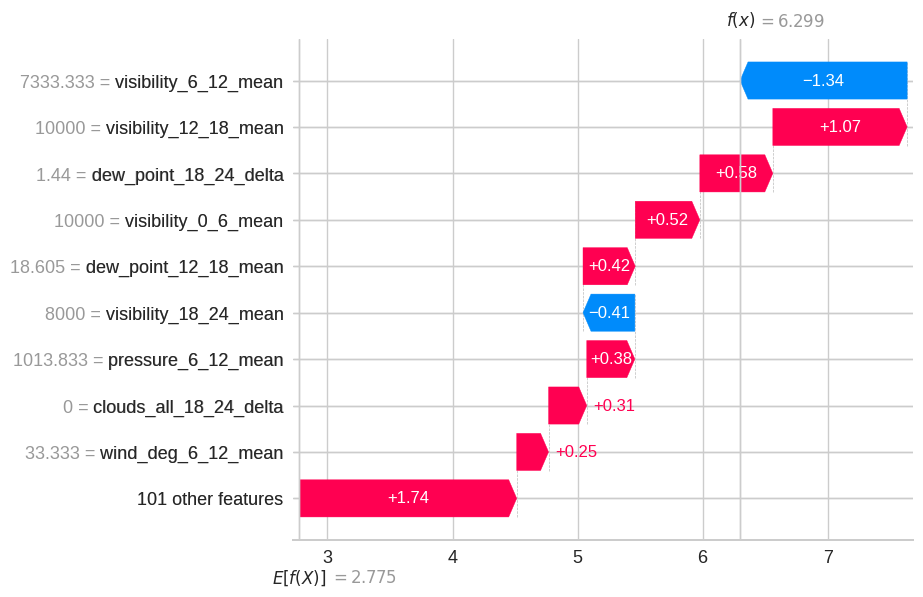

In [ ]:
import numpy as np
import shap

X = df_merged16_cut2.drop(columns=['chamado', 'counts'])

row = df_merged16_cut2[df_merged16_cut2['chamado'] == True].sample(n=1)
X = df_merged16_cut2.drop(row.index)

explainer = shap.TreeExplainer(historic_models[0], X)

# Calculate SHAP values for the random row
shap_values = explainer(row)

shap.plots.waterfall(shap_values[0])


**Forecast**

In [ ]:
df_openwf16_filled = fill_missing(df_openwf, df_openwf.columns)

In [ ]:
df_openwf16_filled.columns

Index(['dt', 'predict_dt', 'temperature_fore', 'dew_point_fore',
       'pressure_fore', 'ground_pressure_fore', 'humidity_fore', 'clouds_fore',
       'wind_speed_fore', 'wind_deg_fore', 'rain_fore', 'convective_fore',
       'probability_fore'],
      dtype='object')

In [ ]:
agg_config = {
 'temperature_fore': (6, ("mean", "delta")),
 'dew_point_fore': (6, ("mean", "delta")),
 'pressure_fore': (6, ("mean", "delta")),
 'ground_pressure_fore': (6, ("mean", "delta")),
 'humidity_fore': (6, ("mean", "delta")),
 'clouds_fore': (6, ("mean", "delta")),
 'wind_speed_fore': (6, ("mean", "delta")),
 'wind_deg_fore': (6, ("mean", "delta")),
 'rain_fore': (6, ("sum", "mean", "delta")),
 'convective_fore': (6, ("sum", "mean", "delta")),
 'probability_fore': (6, ("mean", "delta"))
}

In [ ]:
df_openwf16_agg = df_openwf16_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()


In [ ]:
# Assuming df_chamados_pp_unique is defined somewhere in your previous code
# and contains a 'dt' column representing dates and the number of occurrences per day.

df_chamados_count = df_chamados.groupby('dt').size().reset_index(name='counts')

In [ ]:
# Merge the aggregated weather forecast data with the 'chamados' data
df_merged16 = df_openwf16_agg.copy()
df_merged16['chamado'] = df_merged16['dt'].isin(df_chamados_count['dt']).astype(int)

# Merge the counts into the main DataFrame
df_merged16 = pd.merge(df_merged16, df_chamados_count, on='dt', how='left')

# Fill NaN values in 'chamado_counts' with 0 (days with no chamados)
df_merged16['counts'].fillna(0, inplace=True)

In [ ]:
df_merged16_seasonal = df_merged16[~df_merged16['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])

In [ ]:
df_merged16_cut1 = iterative_lower_fence_cuts(df_merged16_seasonal, true_cut_max=0)

Applying cut on feature 'dew_point_fore_0_6_mean' with threshold 11.491041666666668, removing 38 false cases and 0 true cases
Applying cut on feature 'dew_point_fore_6_12_mean' with threshold 11.599166666666665, removing 14 false cases and 0 true cases
Applying cut on feature 'humidity_fore_0_6_mean' with threshold 54.14333333333335, removing 12 false cases and 0 true cases
Applying cut on feature 'humidity_fore_6_12_mean' with threshold 58.1747916666667, removing 6 false cases and 0 true cases
Applying cut on feature 'temperature_fore_12_18_mean' with threshold 16.366458333333327, removing 5 false cases and 0 true cases
Applying cut on feature 'pressure_fore_18_24_mean' with threshold 1004.3733333333333, removing 5 false cases and 0 true cases
Applying cut on feature 'humidity_fore_18_24_mean' with threshold 29.47833333333335, removing 3 false cases and 0 true cases
Applying cut on feature 'temperature_fore_6_12_mean' with threshold 13.980833333333337, removing 2 false cases and 0 tru

In [ ]:
df_merged16_cut2 = iterative_lower_fence_cuts(df_merged16_cut1, min=True)

Applying cut on feature 'wind_speed_fore_12_18_delta' with threshold 0.04999999999999982, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_18_24_delta' with threshold 2.180000000000007, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_18_24_delta' with threshold 2.289999999999992, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_18_24_mean' with threshold 14.14, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_18_24_mean' with threshold 25.883333333333336, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_deg_fore_18_24_mean' with threshold 29.705, removing 1 false cases and 0 true cases
Applying cut on feature 'wind_speed_fore_0_6_delta' with threshold 0.029999999999999805, removing 1 false cases and 0 true cases
Applying cut on feature 'temperature_fore_0_6_delta' with threshold 0.05999999999999872, removing 1 false cases and 0 true cases
Applyin

In [ ]:
forecast_models, train_data, test_data = train_and_evaluate_model(df_merged16_cut2,
                         ["chamado", "counts"],
                         test_size=0.3,
                         sampling_strategy=1)

Não tem a coluna counts
Não tem a coluna chamado


,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(312, 97)"
4,Transformed data shape,"(312, 97)"
5,Transformed train set shape,"(218, 97)"
6,Transformed test set shape,"(94, 97)"
7,Numeric features,96
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.7519,0.7902,0.7882,0.7340,0.7534,0.5043,0.5168,0.2560
lightgbm,Light Gradient Boosting Machine,0.7279,0.7963,0.7055,0.7513,0.7165,0.4583,0.4680,0.3850
rf,Random Forest Classifier,0.7240,0.8004,0.7345,0.7160,0.7211,0.4496,0.4532,0.2910
xgboost,Extreme Gradient Boosting,0.7190,0.7817,0.7227,0.7192,0.7168,0.4380,0.4433,0.2990
et,Extra Trees Classifier,0.7186,0.7884,0.6773,0.7406,0.6981,0.4375,0.4473,0.3060
gbc,Gradient Boosting Classifier,0.6781,0.7788,0.6691,0.6787,0.6679,0.3577,0.3636,0.5730
nb,Naive Bayes,0.6504,0.6989,0.5118,0.7111,0.5904,0.3006,0.3152,0.0520
lr,Logistic Regression,0.6141,0.6717,0.5864,0.6412,0.5995,0.2302,0.2403,1.3840
dt,Decision Tree Classifier,0.6002,0.6014,0.5964,0.6088,0.5937,0.2026,0.2077,0.0620
ridge,Ridge Classifier,0.5861,0.6430,0.5118,0.6072,0.5492,0.1732,0.1786,0.0530


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.4934,0.5917,0.7313,0.2663,0.3904,0.0966,0.1336


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.4934,0.6215,0.7313,0.2663,0.3904,0.0966,0.1336


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.4735,0.6240,0.7015,0.2527,0.3715,0.0673,0.0940


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4934,0.6165,0.7313,0.2663,0.3904,0.0966,0.1336


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.5364,0.6293,0.7313,0.2865,0.4118,0.1365,0.1779


In [ ]:
# prompt: show me the names of the 5 most important features of best_models15[0]

import pandas as pd
import numpy as np

# Assuming best_models15[0] is a trained model with a feature_importances_ attribute
# and df_merged15_cut2 is the DataFrame used for training.

# Get feature importances

for model in forecast_models:
  feature_importances = model.feature_importances_
# Create a DataFrame to store feature names and their importances
  feature_importance_df = pd.DataFrame({'Feature': df_merged16_cut2.drop(columns=['chamado', 'counts']).columns,
                                        'Importance': feature_importances})

  # Sort by importance in descending order and get the top 5
  top_5_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

  # Print the names of the top 5 features
  print(top_5_features['Feature'].values)


['humidity_fore_0_6_delta' 'wind_deg_fore_0_6_delta'
 'humidity_fore_6_12_mean' 'probability_fore_0_6_mean'
 'convective_fore_18_24_delta']
['humidity_fore_0_6_delta' 'wind_deg_fore_0_6_delta'
 'wind_speed_fore_18_24_delta' 'wind_speed_fore_0_6_delta'
 'humidity_fore_0_6_mean']
['humidity_fore_0_6_delta' 'wind_speed_fore_18_24_delta'
 'clouds_fore_12_18_delta' 'ground_pressure_fore_12_18_mean'
 'humidity_fore_6_12_mean']
['ground_pressure_fore_12_18_mean' 'pressure_fore_0_6_delta'
 'dew_point_fore_12_18_delta' 'humidity_fore_0_6_delta'
 'humidity_fore_12_18_mean']
['wind_speed_fore_18_24_delta' 'clouds_fore_0_6_delta'
 'humidity_fore_0_6_delta' 'humidity_fore_0_6_mean'
 'ground_pressure_fore_6_12_mean']


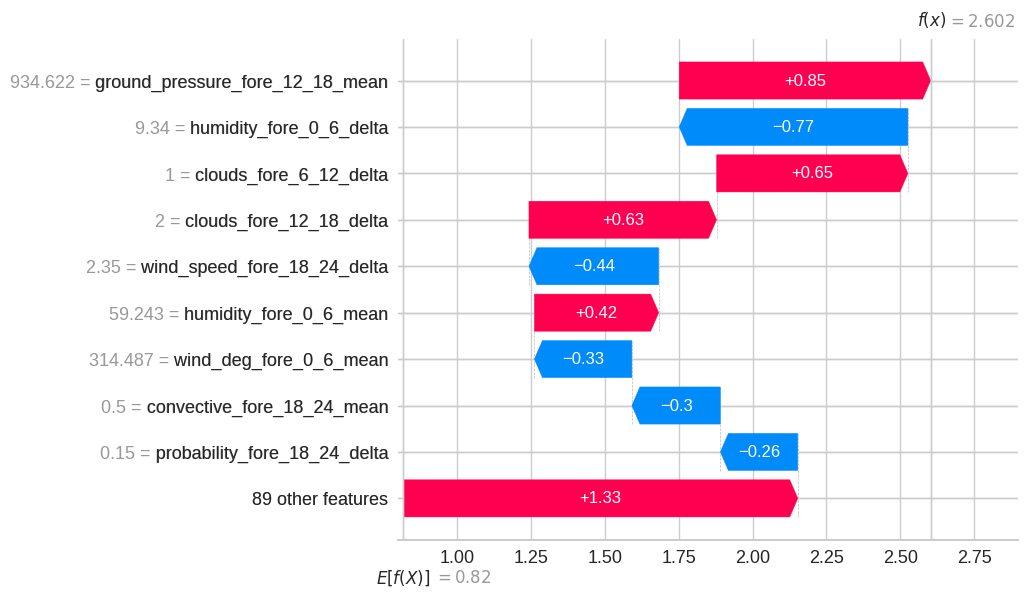

In [ ]:
import numpy as np
import shap

X = df_merged16_cut2.drop(columns=['chamado', 'counts'])

row = df_merged16_cut2[df_merged16_cut2['chamado'] == True].sample(n=1)
X = df_merged16_cut2.drop(row.index)

explainer = shap.TreeExplainer(forecast_models[1], X)

# Calculate SHAP values for the random row
shap_values = explainer(row)

shap.plots.waterfall(shap_values[0])


<a name="sec19"></a>
# 19. Validando o modelo histórico com forecast

Tivemos que abandonar:

visibility
feels_like
temp_min
temp_max
wind_gust


Nada disso impactou resultados de treino -> na verdade ficou até melhor...

Mesma coisa com 95o percentil...

Recall aumentou ainda mais com dados de forecast, precisão ficou mais ou menos igual...

In [ ]:
df_openw16_filled = fill_missing(df_openw, df_openw.columns)

In [ ]:
df_openwf16_filled = fill_missing(df_openwf, df_openwf.columns)

In [ ]:
min_date_chamados = df_chamados['dt'].min()

In [ ]:
df_openw16_filled = df_openw16_filled[df_openw16_filled['dt'] >= min_date_chamados]

Verificando quais colunas são similares entre os datasets e ajustando os nomes de forecast

In [ ]:
df_openw16_filled.columns

Index(['dt', 'temp', 'visibility', 'dew_point', 'feels_like', 'temp_min',
       'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg',
       'wind_gust', 'rain_1h', 'clouds_all', 'weather_id', 'weather_main',
       'weather_description', 'weather_icon'],
      dtype='object')

In [ ]:
df_openwf16_filled.columns

Index(['dt', 'predict_dt', 'temperature_fore', 'dew_point_fore',
       'pressure_fore', 'ground_pressure_fore', 'humidity_fore', 'clouds_fore',
       'wind_speed_fore', 'wind_deg_fore', 'rain_fore', 'convective_fore',
       'probability_fore'],
      dtype='object')

In [ ]:
column_mapping = {
    'temperature_fore': 'temp',
    'dew_point_fore': 'dew_point',
    'pressure_fore': 'pressure',
    'humidity_fore': 'humidity',
    'clouds_fore': 'clouds_all',
    'wind_speed_fore': 'wind_speed',
    'wind_deg_fore': 'wind_deg',
    'rain_fore': 'rain_1h',
}

df_openwf16_filled.rename(columns=column_mapping, inplace=True)

In [ ]:
agg_config = {
 'temp': (6, ("mean", "delta")), # secundario -> delta
 'dew_point': (6, ("mean", "delta")), # 24h > min e delta
 'pressure': (6, ("mean", "delta")), # min
 'humidity': (6, ("mean", "delta")),
 'wind_speed': (6, ("mean", "delta")),
 'wind_deg': (6, ("mean", "delta")), # secundario
 'rain_1h': (6, ("sum", "mean", "delta")), # 24h -> sum
 'clouds_all': (6, ("mean", "delta")),
}

In [ ]:
df_openw16_agg = df_openw16_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()


In [ ]:
df_openwf16_agg = df_openwf16_filled.groupby(pd.Grouper(key='dt', freq='D')). \
    agg(**create_agg_dict(agg_config)).reset_index()

In [ ]:
# Merge the aggregated weather forecast data with the 'chamados' data
df_merged16 = df_openw16_agg.copy()
df_merged16['chamado'] = df_merged16['dt'].isin(df_chamados_count['dt']).astype(int)

# Merge the counts into the main DataFrame
df_merged16 = pd.merge(df_merged16, df_chamados_count, on='dt', how='left')

# Fill NaN values in 'chamado_counts' with 0 (days with no chamados)
df_merged16['counts'].fillna(0, inplace=True)

In [ ]:
df_merged16_seasonal = df_merged16[~df_merged16['dt'].dt.month.between(5, 10)].copy().drop(columns=["dt"])

In [ ]:
df_merged16_cut1 = iterative_lower_fence_cuts(df_merged16_seasonal, true_cut_max=0)

Applying cut on feature 'dew_point_6_12_mean' with threshold 11.72833333333333, removing 93 false cases and 0 true cases
Applying cut on feature 'dew_point_6_12_mean' with threshold 11.917499999999999, removing 15 false cases and 0 true cases
Applying cut on feature 'temp_0_6_mean' with threshold 14.434999999999999, removing 13 false cases and 0 true cases
Applying cut on feature 'dew_point_6_12_mean' with threshold 12.004374999999998, removing 7 false cases and 0 true cases
Applying cut on feature 'temp_12_18_mean' with threshold 15.601666666666652, removing 6 false cases and 0 true cases
Applying cut on feature 'humidity_12_18_mean' with threshold 28.58333333333334, removing 6 false cases and 0 true cases
Applying cut on feature 'temp_0_6_mean' with threshold 14.516666666666675, removing 3 false cases and 0 true cases
Applying cut on feature 'temp_18_24_mean' with threshold 15.125000000000004, removing 2 false cases and 0 true cases
Applying cut on feature 'temp_0_6_mean' with thresh

In [ ]:
df_merged16_cut2 = iterative_lower_fence_cuts(df_merged16_cut1, min=True)

Applying cut on feature 'temp_0_6_delta' with threshold 0.0, removing 8 false cases and 0 true cases
Applying cut on feature 'temp_6_12_delta' with threshold 0.0, removing 3 false cases and 0 true cases
Applying cut on feature 'pressure_18_24_mean' with threshold 1002.8333333333334, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_18_24_delta' with threshold 0.0, removing 2 false cases and 0 true cases
Applying cut on feature 'wind_speed_18_24_delta' with threshold 0.49999999999999956, removing 2 false cases and 0 true cases
Applying cut on feature 'dew_point_0_6_delta' with threshold 0.029999999999997584, removing 1 false cases and 0 true cases
Applying cut on feature 'dew_point_0_6_delta' with threshold 0.03999999999999915, removing 2 false cases and 0 true cases
Applying cut on feature 'dew_point_12_18_mean' with threshold 8.303333333333333, removing 1 false cases and 0 true cases
Applying cut on feature 'dew_point_12_18_mean' with threshold 8.61, removing

In [ ]:
historic_models, train_data, test_data = train_and_evaluate_model(df_merged16_cut2,
                         ["chamado", "counts"],
                         test_size=0.3,
                         sampling_strategy=1)

Não tem a coluna counts
Não tem a coluna chamado


,Description,Value
0,Session id,123
1,Target,chamado
2,Target type,Binary
3,Original data shape,"(732, 69)"
4,Transformed data shape,"(732, 69)"
5,Transformed train set shape,"(512, 69)"
6,Transformed test set shape,"(220, 69)"
7,Numeric features,68
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8612,0.9330,0.8597,0.8672,0.8609,0.7224,0.7265,0.2160
gbc,Gradient Boosting Classifier,0.8592,0.9361,0.8558,0.8673,0.8579,0.7185,0.7245,0.9660
lightgbm,Light Gradient Boosting Machine,0.8592,0.9276,0.8712,0.8552,0.8597,0.7186,0.7247,1.0940
rf,Random Forest Classifier,0.8513,0.9306,0.8868,0.8312,0.8554,0.7029,0.7096,0.4530
xgboost,Extreme Gradient Boosting,0.8493,0.9249,0.8668,0.8428,0.8521,0.6988,0.7035,0.3330
qda,Quadratic Discriminant Analysis,0.8319,0.8886,0.9411,0.7746,0.8490,0.6642,0.6815,0.0530
ada,Ada Boost Classifier,0.8123,0.8966,0.7785,0.8397,0.8037,0.6253,0.6323,0.2780
nb,Naive Bayes,0.7462,0.8563,0.6174,0.8361,0.7057,0.4923,0.5133,0.0530
dt,Decision Tree Classifier,0.7364,0.7364,0.7269,0.7422,0.7330,0.4727,0.4747,0.0710
lr,Logistic Regression,0.6933,0.7286,0.6645,0.7130,0.6843,0.3859,0.3906,0.2280


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.2795,0.5618,0.8599,0.1467,0.2507,0.0147,0.0405


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.2732,0.5080,0.8535,0.1449,0.2477,0.0105,0.0294


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.2446,0.5147,0.8790,0.1430,0.2460,0.0064,0.0203


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.2330,0.5163,0.8981,0.1433,0.2472,0.0071,0.0241


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.2554,0.5270,0.8726,0.1441,0.2473,0.0088,0.0265


In [ ]:
evaluate_by_counts(historic_models, test_data, percentile=0.95)

Shape resultante: (56, 70)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.2679,0.4633,0.8462,0.2200,0.3492,-0.0305,-0.0830


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.3393,0.4275,0.8462,0.2391,0.3729,0.0171,0.0355


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.3214,0.4633,0.8462,0.2340,0.3667,0.0047,0.0103


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.3571,0.5841,1.0000,0.2653,0.4194,0.0828,0.2078


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.3929,0.5814,0.9231,0.2667,0.4138,0.0837,0.1654


In [ ]:
openwf_test_data = df_openwf16_agg.copy()
openwf_test_data["chamado"] = openwf_test_data['dt'].isin(df_chamados_count['dt']).astype(int)

openwf_test_data = pd.merge(openwf_test_data, df_chamados_count, on='dt', how='left')
openwf_test_data['counts'].fillna(0, inplace=True)
openwf_test_data.drop(columns=["dt"], inplace=True)

In [ ]:
evaluate_by_counts(historic_models, openwf_test_data, percentile=0.95)

Shape resultante: (118, 70)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.3136,0.6134,1.0000,0.2895,0.4490,0.0269,0.1167


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.2797,0.6720,0.9697,0.2759,0.4295,-0.0105,-0.0645


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.2881,0.6310,0.9697,0.2783,0.4324,-0.0038,-0.0193


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.2797,0.6269,1.0000,0.2797,0.4371,0.0000,0.0000


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.3220,0.5405,0.9394,0.2844,0.4366,0.0128,0.0368


dew point
rain_1h

3 features

dps wind

<a name="sec20"></a>
# 20. Modelo simplificado

agg_config = {
 'temp': (6, ("mean", "delta")), # secundario -> delta
 'dew_point': (6, ("mean", "delta")), # 24h > min e delta
 'pressure': (6, ("mean", "delta")), # min
 'humidity': (6, ("mean", "delta")),
 'wind_speed': (6, ("mean", "delta")),
 'wind_deg': (6, ("mean", "delta")), # secundario
 'rain_1h': (6, ("sum", "mean", "delta")), # 24h -> sum
 'clouds_all': (6, ("mean", "delta")),
}